<a href="https://colab.research.google.com/github/Rocdpi/UNAJ-/blob/main/Copia_de_UNAJ_Trabajo_integrador_grupo_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Trabajo Integrador - Proyecto final
## Materia: Programación
### Integrantes del grupo:
- Alejandro
- Rocío Napán
- Jorge
- Rubén

Dataset: [base_datos_alumnos.csv]

---

## 🔍 Descripción del proyecto
Desarrollar un sistema de gestión académica que permita analizar las notas de los estudiantes en seis cursos diferentes. Dicho sistema debería poder calcular el promedio de notas (con aplazos y sin aplazos), determinar la situación académica de cada estudiante (aprobado o reprobado) y mostrar la información general de las
notas.

---
#### **📁 1. Lectura y procesamiento de datos**
##### Implementar la obtención de información académica desde un archivo CSV que contendrá:

- Información personal de cada estudiante (nombre y apellido)
- Calificaciones en seis asignaturas clave: programación, bases de datos,  análisis  estadístico, arquitecturas en la nube, aprendizaje automático y captura de información.
- Cualquier información adicional relevante   para   el   análisis   académico (opcional).


# Título principal (tamaño más grande)
## Encabezado de sección (tamaño mediano)
### Subsección (tamaño un poco más pequeño)
#### Otro nivel de encabezado

**Texto en negrita**
*Texto en cursiva*
***Texto en negrita y cursiva***

Un párrafo de texto normal. El tamaño de fuente para el texto normal es estándar y no se puede cambiar directamente con Markdown, pero los encabezados sí ofrecen diferentes tamaños.

- Lista de elementos
- Otra lista

In [ ]:
# Código para cargar el dataset y mostrar estructura
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import sys # Importar sys para sys.exit()
from sklearn.preprocessing import LabelEncoder # Importa LabelEncoder
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Importaciones de Scikit-learn para modelos de regresión lineal
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Importaciones de Scikit-learn para Regresión Logística y métricas de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
# Se corrigió la ruta del archivo asumiendo que se encuentra en '/content/drive/MyDrive/DS/'
df = pd.read_csv('/content/sample_data/base_datos_alumnos.csv', sep=';')

Mounted at /content/drive


\* Se muestra la información de la base de datos

Genera csv

In [ ]:
# ============================================================
# 2. Generar CSV nuevo con datos aleatorios
# ============================================================

cantidad_estudiantes = 10  # Puedes cambiarlo

columnas = df.columns.tolist()
columnas_notas = columnas[2:]  # Todas las materias

# Listas base para nombres y apellidos
nombres_base = ["Ana", "Luis", "Carlos", "Elena", "Pablo", "María", "Sofía", "Jorge", "Lucía", "Miguel"]
apellidos_base = ["García", "Martínez", "Ochoa", "Rodríguez", "López", "Torres", "Sánchez", "Paredes", "Castro", "Ramos"]

# Crear nuevo dataset aleatorio
data_nueva = {
    "NOMBRE": np.random.choice(nombres_base, cantidad_estudiantes),
    "APELLIDO": np.random.choice(apellidos_base, cantidad_estudiantes)
}

for col in columnas_notas:
    data_nueva[col] = np.random.randint(0, 11, cantidad_estudiantes)

df_nuevo = pd.DataFrame(data_nueva)

# Guardar CSV generado
df_nuevo.to_csv("estudiantes_aleatorio.csv", sep=";", index=False)

print("\nNuevo CSV generado con datos aleatorios:")
display(df_nuevo)


Nuevo CSV generado con datos aleatorios:


,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
0,María,Paredes,7,6,7,2,8,8
1,Miguel,Rodríguez,3,5,6,10,10,3
2,Luis,Paredes,3,9,6,10,7,8
3,Carlos,Torres,4,6,9,9,6,4
4,Miguel,Rodríguez,1,1,7,6,5,9
5,Lucía,Rodríguez,9,4,7,4,6,1
6,Ana,Ochoa,2,0,0,3,4,8
7,Sofía,García,5,10,6,0,8,0
8,Jorge,Martínez,2,2,2,7,6,6
9,Luis,Martínez,3,9,6,9,0,3


In [ ]:
df.head()

,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
0,Ana,Garcia,8,7,9,6,10,4
1,Carlos,Roriguez,5,6,7,2,2,9
2,Elena,Martinez,9,9,8,2,6,7
3,Pablo,Ochoa,9,9,8,2,6,7


In [ ]:
display(df.head())

,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
0,Ana,Garcia,8,7,9,6,10,4
1,Carlos,Roriguez,5,6,7,2,2,9
2,Elena,Martinez,9,9,8,2,6,7
3,Pablo,Ochoa,9,9,8,2,6,7


In [ ]:
df.dtypes

,0
NOMBRE,object
APELLIDO,object
PROGRAMACION,int64
BASE DE DATOS,int64
ESTADISTICA,int64
ARQUITECTURA NUBE,int64
APRENDIZAJE AUTOMATICO,int64
CAPTURA DE LA INFORMACION,int64


In [ ]:
df.head(2)


,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
0,Ana,Garcia,8,7,9,6,10,4
1,Carlos,Roriguez,5,6,7,2,2,9


In [ ]:
df.tail()

,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
0,Ana,Garcia,8,7,9,6,10,4
1,Carlos,Roriguez,5,6,7,2,2,9
2,Elena,Martinez,9,9,8,2,6,7
3,Pablo,Ochoa,9,9,8,2,6,7


In [ ]:
df.describe()

,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
count,4.000000,4.00,4.000000,4.0,4.000000,4.000000
mean,7.750000,7.75,8.000000,3.0,6.000000,6.750000
std,1.892969,1.50,0.816497,2.0,3.265986,2.061553
min,5.000000,6.00,7.000000,2.0,2.000000,4.000000
25%,7.250000,6.75,7.750000,2.0,5.000000,6.250000
50%,8.500000,8.00,8.000000,2.0,6.000000,7.000000
75%,9.000000,9.00,8.250000,3.0,7.000000,7.500000
max,9.000000,9.00,9.000000,6.0,10.000000,9.000000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PROGRAMACION,4.0,7.75,1.892969,5.0,7.25,8.5,9.00,9.0
BASE DE DATOS,4.0,7.75,1.500000,6.0,6.75,8.0,9.00,9.0
ESTADISTICA,4.0,8.00,0.816497,7.0,7.75,8.0,8.25,9.0
ARQUITECTURA NUBE,4.0,3.00,2.000000,2.0,2.00,2.0,3.00,6.0
APRENDIZAJE AUTOMATICO,4.0,6.00,3.265986,2.0,5.00,6.0,7.00,10.0
CAPTURA DE LA INFORMACION,4.0,6.75,2.061553,4.0,6.25,7.0,7.50,9.0


In [ ]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NOMBRE,4,4,Ana,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APELLIDO,4,4,Garcia,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PROGRAMACION,4.0,NaN,NaN,NaN,7.75,1.892969,5.0,7.25,8.5,9.0,9.0
BASE DE DATOS,4.0,NaN,NaN,NaN,7.75,1.5,6.0,6.75,8.0,9.0,9.0
ESTADISTICA,4.0,NaN,NaN,NaN,8.0,0.816497,7.0,7.75,8.0,8.25,9.0
ARQUITECTURA NUBE,4.0,NaN,NaN,NaN,3.0,2.0,2.0,2.0,2.0,3.0,6.0
APRENDIZAJE AUTOMATICO,4.0,NaN,NaN,NaN,6.0,3.265986,2.0,5.0,6.0,7.0,10.0
CAPTURA DE LA INFORMACION,4.0,NaN,NaN,NaN,6.75,2.061553,4.0,6.25,7.0,7.5,9.0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PROGRAMACION,4.0,7.75,1.892969,5.0,7.25,8.5,9.00,9.0
BASE DE DATOS,4.0,7.75,1.500000,6.0,6.75,8.0,9.00,9.0
ESTADISTICA,4.0,8.00,0.816497,7.0,7.75,8.0,8.25,9.0
ARQUITECTURA NUBE,4.0,3.00,2.000000,2.0,2.00,2.0,3.00,6.0
APRENDIZAJE AUTOMATICO,4.0,6.00,3.265986,2.0,5.00,6.0,7.00,10.0
CAPTURA DE LA INFORMACION,4.0,6.75,2.061553,4.0,6.25,7.0,7.50,9.0


In [ ]:
df.isnull().sum()

,0
NOMBRE,0
APELLIDO,0
PROGRAMACION,0
BASE DE DATOS,0
ESTADISTICA,0
ARQUITECTURA NUBE,0
APRENDIZAJE AUTOMATICO,0
CAPTURA DE LA INFORMACION,0


In [ ]:
df.isnull()

,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False


### Acceder a valores específicos



In [ ]:
# El valor en la fila 0, columna 'PROGRAMACION'
primera_nota = df.loc[0, 'PROGRAMACION']
print(f"Primera nota de programación: {primera_nota}")

Primera nota de programación: 8


### Acceder a una fila completa

También puedes obtener toda la información de una fila específica utilizando `df.loc[]` o `df.iloc[]` (para acceso por índice numérico):


In [ ]:
# Obtener la primera fila completa por su índice
primera_fila = df.loc[0]
print("\nPrimera fila completa:")
display(primera_fila)

# Obtener la segunda fila por su índice numérico (iloc)
segunda_fila_iloc = df.iloc[1]
print("\nSegunda fila completa (usando .iloc[1]):")
display(segunda_fila_iloc)


Primera fila completa:


,0
NOMBRE,Ana
APELLIDO,Garcia
PROGRAMACION,8
BASE DE DATOS,7
ESTADISTICA,9
ARQUITECTURA NUBE,6
APRENDIZAJE AUTOMATICO,10
CAPTURA DE LA INFORMACION,4



Segunda fila completa (usando .iloc[1]):


,1
NOMBRE,Carlos
APELLIDO,Roriguez
PROGRAMACION,5
BASE DE DATOS,6
ESTADISTICA,7
ARQUITECTURA NUBE,2
APRENDIZAJE AUTOMATICO,2
CAPTURA DE LA INFORMACION,9


### Acceder a valores específicos

---


In [ ]:
# Acceder a la columna 'NOMBRE'
nombres_alumnos = df['NOMBRE']
print("\nNombre de los alumnos:")
display(nombres_alumnos)



Nombre de los alumnos:


,NOMBRE
0,Ana
1,Carlos
2,Elena
3,Pablo


### Acceder a múltiples columnas

Para seleccionar varias columnas, pasa una lista de nombres de columnas:


In [ ]:
# Seleccionar las columnas 'NOMBRE', 'APELLIDO' y 'PROGRAMACION'
info_personal_y_nota = df[['NOMBRE', 'APELLIDO', 'PROGRAMACION']]
print("\nInformación personal y nota de Programación:")
display(info_personal_y_nota)


Información personal y nota de Programación:


,NOMBRE,APELLIDO,PROGRAMACION
0,Ana,Garcia,8
1,Carlos,Roriguez,5
2,Elena,Martinez,9
3,Pablo,Ochoa,9


### Filtrar filas basado en una condición

Una de las cosas más útiles es filtrar tus datos para ver solo las filas que cumplen con ciertas condiciones. Por ejemplo, si quieres ver qué alumnos aprobaron Programación (asumiendo que una nota aprobatoria es >= 6):


In [ ]:
# Alumnos que aprobaron Programación (nota >= 6)
alumnos_aprobados_programacion = df[df['PROGRAMACION'] >= 6]
print("\nAlumnos con nota de Programación igual o mayor a 6:")
display(alumnos_aprobados_programacion)

# Alumnos con nota de 'BASES DE DATOS' mayor a 8
alumnos_excelentes_bd = df[df['BASE DE DATOS'] > 8]
print("\nAlumnos con nota de Bases de Datos mayor a 8:")
display(alumnos_excelentes_bd)


Alumnos con nota de Programación igual o mayor a 6:


,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
0,Ana,Garcia,8,7,9,6,10,4
2,Elena,Martinez,9,9,8,2,6,7
3,Pablo,Ochoa,9,9,8,2,6,7



Alumnos con nota de Bases de Datos mayor a 8:


,NOMBRE,APELLIDO,PROGRAMACION,BASE DE DATOS,ESTADISTICA,ARQUITECTURA NUBE,APRENDIZAJE AUTOMATICO,CAPTURA DE LA INFORMACION
2,Elena,Martinez,9,9,8,2,6,7
3,Pablo,Ochoa,9,9,8,2,6,7


---
#### **📁 2. Modelado Orientado a Objetos**
##### Diseñar e implementar una estructura de clases que permita representar adecuadamente:

-  La entidad Estudiante con sus atributos y comportamientos.
-  Las operaciones necesarias para analizar su rendimiento académico.
-  Las relaciones entre las distintas entidades del sistema (opcional).



In [ ]:
class Estudiante:
    def __init__(self, nombre, apellido, nota_prog, nota_est, nota_b_datos):
        self.nombre = nombre
        self.apellido = apellido
        self.nota_prog = nota_prog
        self.nota_est = nota_est
        self.nota_b_datos = nota_b_datos

    def calcular_prom(self):
        return (self.nota_prog + self.nota_est + self.nota_b_datos) / 3

    def obtener_sit(self):
        prom = self.calcular_prom()

        if prom >= 8 and min(self.nota_prog, self.nota_est, self.nota_b_datos) >= 7:
            return "Promocionado"
        elif prom >= 6:
            return "Aprobado"
        else:
            return "Desaprobado"


In [ ]:
# %% Bloque 1: Clase Materia
class Materia:
    def __init__(self, nombre, nota):
        self.nombre = nombre
        self.nota = nota

    def __repr__(self):
        return f"Materia(nombre='{self.nombre}', nota={self.nota})"


# %% Bloque 2: Clase Estudiante
class Estudiante:
    def __init__(self, nombre, apellido, materias):
        self.nombre = nombre
        self.apellido = apellido
        self.materias = materias  # lista de objetos Materia

    def calcular_prom(self):
        if not self.materias:
            return 0
        return sum(m.nota for m in self.materias) / len(self.materias)

    def obtener_sit(self):
        prom = self.calcular_prom()
        notas = [m.nota for m in self.materias]

        if prom >= 8 and min(notas) >= 7:
            return "Promocionado"
        elif prom >= 6:
            return "Aprobado"
        else:
            return "Desaprobado"

    def __repr__(self):
        return f"Estudiante(nombre='{self.nombre}', apellido='{self.apellido}')"


# %% Bloque 3: Clase Curso
class Curso:
    def __init__(self, nombre):
        self.nombre = nombre
        self.estudiantes = []  # relación 1 a muchos

    def agregar_estudiante(self, estudiante):
        self.estudiantes.append(estudiante)

    def promedio_general(self):
        if not self.estudiantes:
            return 0
        return sum(e.calcular_prom() for e in self.estudiantes) / len(self.estudiantes)

    def __repr__(self):
        return f"Curso(nombre='{self.nombre}', estudiantes={len(self.estudiantes)})"


# %% Bloque 4: Clase AnalizadorRendimiento
class AnalizadorRendimiento:
    def mejor_estudiante(self, estudiantes):
        if not estudiantes:
            return None
        return max(estudiantes, key=lambda e: e.calcular_prom())

    def peor_estudiante(self, estudiantes):
        if not estudiantes:
            return None
        return min(estudiantes, key=lambda e: e.calcular_prom())

    def promedio_por_materia(self, estudiantes, nombre_materia):
        notas = []
        for e in estudiantes:
            for m in e.materias:
                if m.nombre == nombre_materia:
                    notas.append(m.nota)
        return sum(notas) / len(notas) if notas else 0


# %% Bloque 5: Ejecución y comprobación
if __name__ == "__main__":
    # Crear materias para estudiante 1
    m1 = Materia("Programación", 9)
    m2 = Materia("Estadística", 8)
    m3 = Materia("Bases de Datos", 10)

    # Crear materias para estudiante 2
    m4 = Materia("Programación", 6)
    m5 = Materia("Estadística", 7)
    m6 = Materia("Bases de Datos", 5)

    # Crear estudiantes
    e1 = Estudiante("Ana", "Pérez", [m1, m2, m3])
    e2 = Estudiante("Luis", "Gómez", [m4, m5, m6])

    # Crear curso y agregar estudiantes
    curso = Curso("Data Science 1")
    curso.agregar_estudiante(e1)
    curso.agregar_estudiante(e2)

    # Crear analizador
    analizador = AnalizadorRendimiento()

    # Mostrar información
    print("=== Información de estudiantes ===")
    for e in curso.estudiantes:
        print(f"{e.nombre} {e.apellido} - Promedio: {e.calcular_prom():.2f} - Situación: {e.obtener_sit()}")

    print("\n=== Estadísticas del curso ===")
    print(f"Promedio general del curso: {curso.promedio_general():.2f}")

    mejor = analizador.mejor_estudiante(curso.estudiantes)
    peor = analizador.peor_estudiante(curso.estudiantes)

    print(f"Mejor estudiante: {mejor.nombre} {mejor.apellido} (Promedio: {mejor.calcular_prom():.2f})")
    print(f"Peor estudiante: {peor.nombre} {peor.apellido} (Promedio: {peor.calcular_prom():.2f})")

    print("\n=== Promedios por materia ===")
    for nombre_materia in ["Programación", "Estadística", "Bases de Datos"]:
        prom_mat = analizador.promedio_por_materia(curso.estudiantes, nombre_materia)
        print(f"{nombre_materia}: {prom_mat:.2f}")


=== Información de estudiantes ===
Ana Pérez - Promedio: 9.00 - Situación: Promocionado
Luis Gómez - Promedio: 6.00 - Situación: Aprobado

=== Estadísticas del curso ===
Promedio general del curso: 7.50
Mejor estudiante: Ana Pérez (Promedio: 9.00)
Peor estudiante: Luis Gómez (Promedio: 6.00)

=== Promedios por materia ===
Programación: 7.50
Estadística: 7.50
Bases de Datos: 7.50


---
#### **📁 3. Análisis Académico**
##### El sistema debe realizar los siguientes cálculos y análisis:

-  Promedio individual por estudiante en todas las asignaturas.
-  Determinación del estado académico (aprobado/reprobado) según criterios
establecidos (por ejemplo, nota >= 6).
-  Estadísticas generales del grupo:
    - promedio por asignatura
    - porcentaje de aprobación general
    - identificación de la asignatura con mayor y menor rendimiento.




In [ ]:
# ============================================
# BLOQUE: Cálculos y análisis del sistema
# ============================================

def promedio_individual(estudiante):
    """Promedio individual del estudiante en todas las asignaturas."""
    notas = [m.nota for m in estudiante.materias]
    return sum(notas) / len(notas)


def estado_academico(estudiante):
    """Determina si el estudiante aprueba o reprueba según nota >= 6."""
    prom = promedio_individual(estudiante)
    return "Aprobado" if prom >= 6 else "Reprobado"


def promedio_por_asignatura(estudiantes):
    """Devuelve un diccionario con el promedio de cada asignatura."""
    materias_dict = {}

    for e in estudiantes:
        for m in e.materias:
            materias_dict.setdefault(m.nombre, []).append(m.nota)

    return {mat: sum(notas)/len(notas) for mat, notas in materias_dict.items()}


def porcentaje_aprobacion(estudiantes):
    """Porcentaje de estudiantes aprobados."""
    aprobados = sum(1 for e in estudiantes if estado_academico(e) == "Aprobado")
    return (aprobados / len(estudiantes)) * 100 if estudiantes else 0


def mejor_y_peor_asignatura(estudiantes):
    """Identifica la asignatura con mayor y menor rendimiento."""
    promedios = promedio_por_asignatura(estudiantes)

    mejor = max(promedios, key=promedios.get)
    peor = min(promedios, key=promedios.get)

    return mejor, peor, promedios


# ============================================
# COMPROBACIÓN DEL BLOQUE (EJEMPLO)
# ============================================

# Crear materias para estudiante 1
m1 = Materia("Programación", 9)
m2 = Materia("Estadística", 8)
m3 = Materia("Bases de Datos", 10)

# Crear materias para estudiante 2
m4 = Materia("Programación", 6)
m5 = Materia("Estadística", 7)
m6 = Materia("Bases de Datos", 5)

# Crear estudiantes
e1 = Estudiante("Ana", "Pérez", [m1, m2, m3])
e2 = Estudiante("Luis", "Gómez", [m4, m5, m6])

grupo = [e1, e2]

# Mostrar resultados
print("=== Promedio individual ===")
for e in grupo:
    print(f"{e.nombre} {e.apellido}: {promedio_individual(e):.2f}")

print("\n=== Estado académico ===")
for e in grupo:
    print(f"{e.nombre} {e.apellido}: {estado_academico(e)}")

print("\n=== Promedio por asignatura ===")
prom_asig = promedio_por_asignatura(grupo)
for mat, prom in prom_asig.items():
    print(f"{mat}: {prom:.2f}")

print("\n=== Porcentaje de aprobación ===")
print(f"{porcentaje_aprobacion(grupo):.2f}%")

print("\n=== Mejor y peor asignatura ===")
mejor, peor, promedios = mejor_y_peor_asignatura(grupo)
print(f"Mejor asignatura: {mejor}")
print(f"Peor asignatura: {peor}")


=== Promedio individual ===
Ana Pérez: 9.00
Luis Gómez: 6.00

=== Estado académico ===
Ana Pérez: Aprobado
Luis Gómez: Aprobado

=== Promedio por asignatura ===
Programación: 7.50
Estadística: 7.50
Bases de Datos: 7.50

=== Porcentaje de aprobación ===
100.00%

=== Mejor y peor asignatura ===
Mejor asignatura: Programación
Peor asignatura: Programación


In [ ]:
# ============================================
# BLOQUE: Cálculos y análisis del sistema
# ============================================

def promedio_individual(estudiante):
    """Promedio individual del estudiante en todas las asignaturas."""
    notas = [m.nota for m in estudiante.materias]
    return sum(notas) / len(notas)


def estado_academico(estudiante):
    """Determina si el estudiante aprueba o reprueba según nota >= 6."""
    prom = promedio_individual(estudiante)
    return "Aprobado" if prom >= 6 else "Reprobado"


def promedio_por_asignatura(estudiantes):
    """Devuelve un diccionario con el promedio de cada asignatura."""
    materias_dict = {}

    for e in estudiantes:
        for m in e.materias:
            materias_dict.setdefault(m.nombre, []).append(m.nota)

    return {mat: sum(notas)/len(notas) for mat, notas in materias_dict.items()}


def porcentaje_aprobacion(estudiantes):
    """Porcentaje de estudiantes aprobados."""
    aprobados = sum(1 for e in estudiantes if estado_academico(e) == "Aprobado")
    return (aprobados / len(estudiantes)) * 100 if estudiantes else 0


def mejor_y_peor_asignatura(estudiantes):
    """Identifica la asignatura con mayor y menor rendimiento."""
    promedios = promedio_por_asignatura(estudiantes)

    mejor = max(promedios, key=promedios.get)
    peor = min(promedios, key=promedios.get)

    return mejor, peor, promedios


# ============================================
# COMPROBACIÓN DEL BLOQUE (EJEMPLO)
# ============================================

# Crear materias para estudiante 1
m1 = Materia("Programación", 9)
m2 = Materia("Estadística", 8)
m3 = Materia("Bases de Datos", 10)

# Crear materias para estudiante 2
m4 = Materia("Programación", 6)
m5 = Materia("Estadística", 7)
m6 = Materia("Bases de Datos", 5)

# Crear estudiantes
e1 = Estudiante("Ana", "Pérez", [m1, m2, m3])
e2 = Estudiante("Luis", "Gómez", [m4, m5, m6])

grupo = [e1, e2]

# Mostrar resultados
print("=== Promedio individual ===")
for e in grupo:
    print(f"{e.nombre} {e.apellido}: {promedio_individual(e):.2f}")

print("\n=== Estado académico ===")
for e in grupo:
    print(f"{e.nombre} {e.apellido}: {estado_academico(e)}")

print("\n=== Promedio por asignatura ===")
prom_asig = promedio_por_asignatura(grupo)
for mat, prom in prom_asig.items():
    print(f"{mat}: {prom:.2f}")

print("\n=== Porcentaje de aprobación ===")
print(f"{porcentaje_aprobacion(grupo):.2f}%")

print("\n=== Mejor y peor asignatura ===")
mejor, peor, promedios = mejor_y_peor_asignatura(grupo)
print(f"Mejor asignatura: {mejor}")
print(f"Peor asignatura: {peor}")


=== Promedio individual ===
Ana Pérez: 9.00
Luis Gómez: 6.00

=== Estado académico ===
Ana Pérez: Aprobado
Luis Gómez: Aprobado

=== Promedio por asignatura ===
Programación: 7.50
Estadística: 7.50
Bases de Datos: 7.50

=== Porcentaje de aprobación ===
100.00%

=== Mejor y peor asignatura ===
Mejor asignatura: Programación
Peor asignatura: Programación


In [ ]:
# ============================================
# BLOQUE: Cálculos y análisis del sistema
# ============================================

def promedio_individual(estudiante):
    """Promedio individual del estudiante en todas las asignaturas."""
    notas = [m.nota for m in estudiante.materias]
    return sum(notas) / len(notas)


def estado_academico(estudiante):
    """Determina si el estudiante aprueba o reprueba según nota >= 6."""
    prom = promedio_individual(estudiante)
    return "Aprobado" if prom >= 6 else "Reprobado"


def promedio_por_asignatura(estudiantes):
    """Devuelve un diccionario con el promedio de cada asignatura."""
    materias_dict = {}

    for e in estudiantes:
        for m in e.materias:
            materias_dict.setdefault(m.nombre, []).append(m.nota)

    return {mat: sum(notas)/len(notas) for mat, notas in materias_dict.items()}


def porcentaje_aprobacion(estudiantes):
    """Porcentaje de estudiantes aprobados."""
    aprobados = sum(1 for e in estudiantes if estado_academico(e) == "Aprobado")
    return (aprobados / len(estudiantes)) * 100 if estudiantes else 0


def mejor_y_peor_asignatura(estudiantes):
    """Identifica la asignatura con mayor y menor rendimiento."""
    promedios = promedio_por_asignatura(estudiantes)

    mejor = max(promedios, key=promedios.get)
    peor = min(promedios, key=promedios.get)

    return mejor, peor, promedios


# ============================================
# COMPROBACIÓN DEL BLOQUE (EJEMPLO)
# ============================================

# Usar el DataFrame df_nuevo generado aleatoriamente
grupo = []
columnas_notas = ['PROGRAMACION', 'BASE DE DATOS', 'ESTADISTICA', 'ARQUITECTURA NUBE ', 'APRENDIZAJE AUTOMATICO', 'CAPTURA DE LA INFORMACION']

for index, row in df_nuevo.iterrows():
    nombre_estudiante = row['NOMBRE']
    apellido_estudiante = row['APELLIDO']
    materias_estudiante = []

    for col_nota in columnas_notas:
        materia = Materia(col_nota.strip(), row[col_nota]) # .strip() para limpiar posibles espacios en nombres de columna
        materias_estudiante.append(materia)

    estudiante = Estudiante(nombre_estudiante, apellido_estudiante, materias_estudiante)
    grupo.append(estudiante)


# Mostrar resultados
print("=== Promedio individual ===")
for e in grupo:
    print(f"{e.nombre} {e.apellido}: {promedio_individual(e):.2f}")

print("\n=== Estado académico ===")
for e in grupo:
    print(f"{e.nombre} {e.apellido}: {estado_academico(e)}")

print("\n=== Promedio por asignatura ===")
prom_asig = promedio_por_asignatura(grupo)
for mat, prom in prom_asig.items():
    print(f"{mat}: {prom:.2f}")

print("\n=== Porcentaje de aprobación ===")
print(f"{porcentaje_aprobacion(grupo):.2f}%")

print("\n=== Mejor y peor asignatura ===")
mejor, peor, promedios = mejor_y_peor_asignatura(grupo)
print(f"Mejor asignatura: {mejor}")
print(f"Peor asignatura: {peor}")

=== Promedio individual ===
María Paredes: 6.33
Miguel Rodríguez: 6.17
Luis Paredes: 7.17
Carlos Torres: 6.33
Miguel Rodríguez: 4.83
Lucía Rodríguez: 5.17
Ana Ochoa: 2.83
Sofía García: 4.83
Jorge Martínez: 4.17
Luis Martínez: 5.00

=== Estado académico ===
María Paredes: Aprobado
Miguel Rodríguez: Aprobado
Luis Paredes: Aprobado
Carlos Torres: Aprobado
Miguel Rodríguez: Reprobado
Lucía Rodríguez: Reprobado
Ana Ochoa: Reprobado
Sofía García: Reprobado
Jorge Martínez: Reprobado
Luis Martínez: Reprobado

=== Promedio por asignatura ===
PROGRAMACION: 3.90
BASE DE DATOS: 5.20
ESTADISTICA: 5.60
ARQUITECTURA NUBE: 6.00
APRENDIZAJE AUTOMATICO: 6.00
CAPTURA DE LA INFORMACION: 5.00

=== Porcentaje de aprobación ===
40.00%

=== Mejor y peor asignatura ===
Mejor asignatura: ARQUITECTURA NUBE
Peor asignatura: PROGRAMACION


### 4. Presentación de Resultados del Análisis Académico

#### Información detallada de cada estudiante y su situación académica

In [ ]:
print("=== Reporte Individual de Estudiantes ===")
for e in grupo:
    print(f"- {e.nombre} {e.apellido}: Promedio = {e.calcular_prom():.2f}, Situación = {e.obtener_sit()}")

=== Reporte Individual de Estudiantes ===
- María Paredes: Promedio = 6.33, Situación = Aprobado
- Miguel Rodríguez: Promedio = 6.17, Situación = Aprobado
- Luis Paredes: Promedio = 7.17, Situación = Aprobado
- Carlos Torres: Promedio = 6.33, Situación = Aprobado
- Miguel Rodríguez: Promedio = 4.83, Situación = Desaprobado
- Lucía Rodríguez: Promedio = 5.17, Situación = Desaprobado
- Ana Ochoa: Promedio = 2.83, Situación = Desaprobado
- Sofía García: Promedio = 4.83, Situación = Desaprobado
- Jorge Martínez: Promedio = 4.17, Situación = Desaprobado
- Luis Martínez: Promedio = 5.00, Situación = Desaprobado


#### Estadísticas comparativas entre asignaturas

In [ ]:
print("\n=== Promedio por Asignatura ===")
prom_asig = promedio_por_asignatura(grupo)
for mat, prom in prom_asig.items():
    print(f"- {mat}: {prom:.2f}")

print(f"\n=== Porcentaje de Aprobación General ===\n{porcentaje_aprobacion(grupo):.2f}%")

mejor, peor, _ = mejor_y_peor_asignatura(grupo)
print(f"\n=== Mejor y Peor Asignatura ===")
print(f"- Mejor asignatura: {mejor}")
print(f"- Peor asignatura: {peor}")


=== Promedio por Asignatura ===
- PROGRAMACION: 3.90
- BASE DE DATOS: 5.20
- ESTADISTICA: 5.60
- ARQUITECTURA NUBE: 6.00
- APRENDIZAJE AUTOMATICO: 6.00
- CAPTURA DE LA INFORMACION: 5.00

=== Porcentaje de Aprobación General ===
40.00%

=== Mejor y Peor Asignatura ===
- Mejor asignatura: ARQUITECTURA NUBE
- Peor asignatura: PROGRAMACION


#### Resumen general del rendimiento del grupo (gráfico de barras)

/tmp/ipykernel_30214/3001867851.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Asignatura', y='Promedio', data=prom_asig_df, palette='viridis')


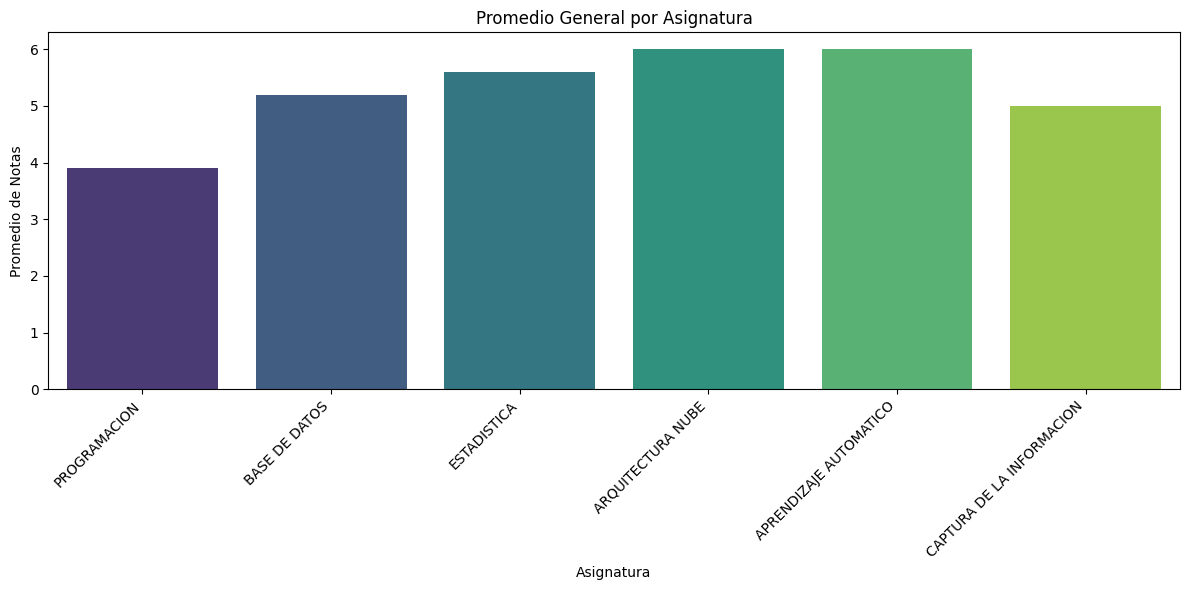

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos para el gráfico de barras de promedio por asignatura
prom_asig_df = pd.DataFrame(prom_asig.items(), columns=['Asignatura', 'Promedio'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Asignatura', y='Promedio', data=prom_asig_df, palette='viridis')
plt.title('Promedio General por Asignatura')
plt.xlabel('Asignatura')
plt.ylabel('Promedio de Notas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Análisis de Distribución de Notas por Asignatura (Histogramas)

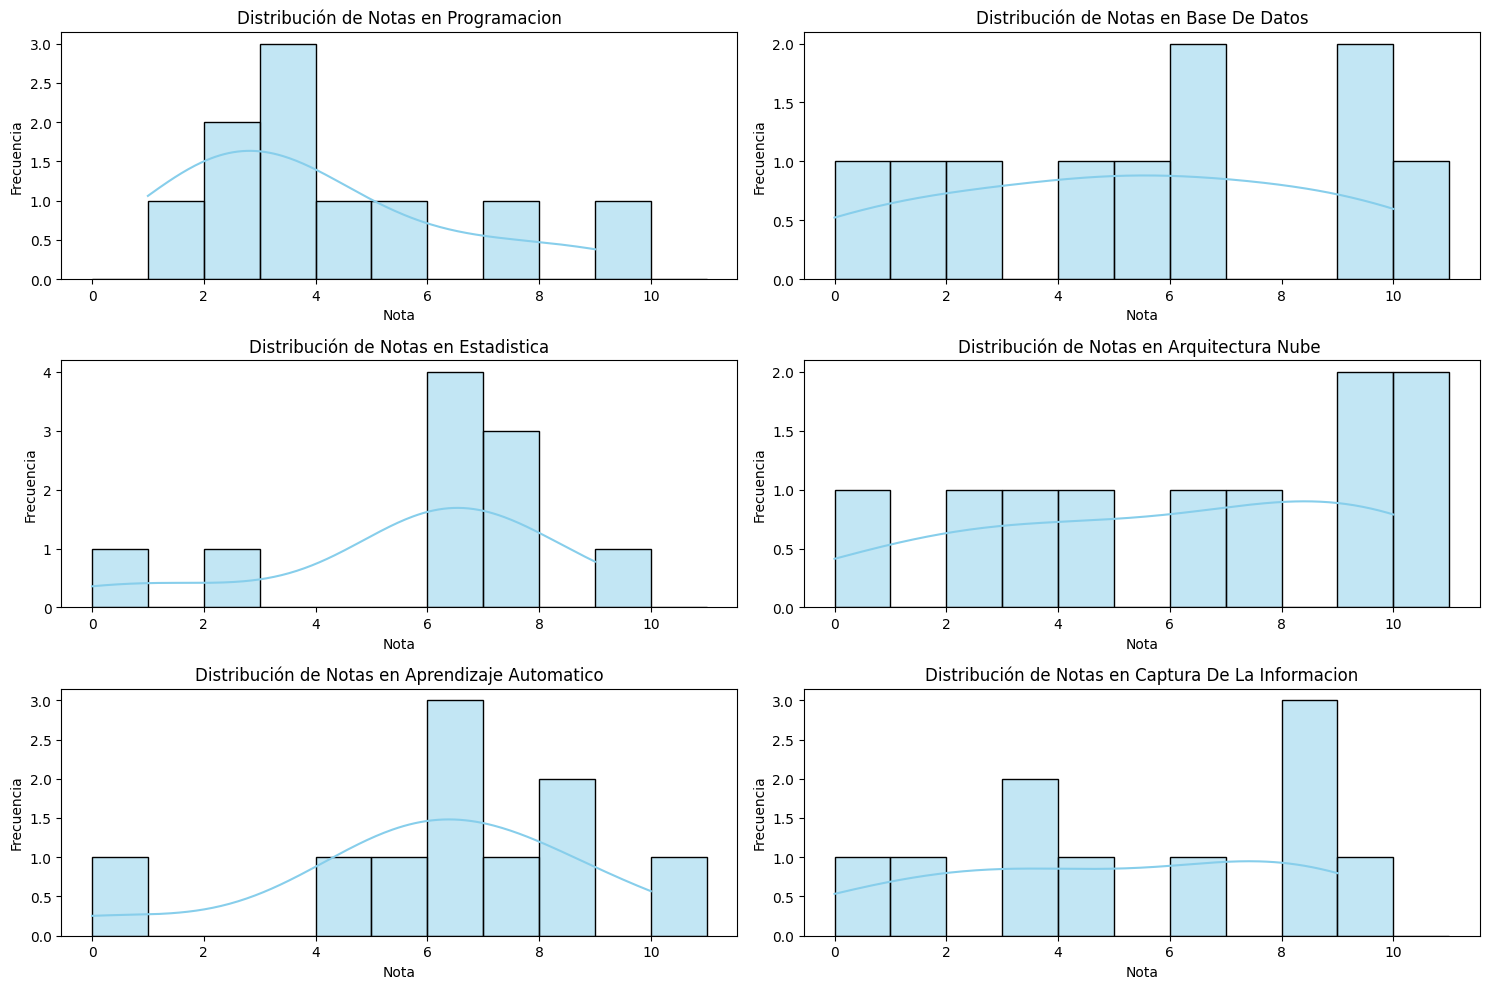

In [ ]:
columnas_notas = ['PROGRAMACION', 'BASE DE DATOS', 'ESTADISTICA', 'ARQUITECTURA NUBE ', 'APRENDIZAJE AUTOMATICO', 'CAPTURA DE LA INFORMACION']

plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_notas):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df_nuevo[col], bins=range(0, 12), kde=True, color='skyblue') # Se cambió 'coolwarm' por 'skyblue'
    plt.title(f'Distribución de Notas en {col.replace('_', ' ').title()}')
    plt.xlabel('Nota')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

#### Análisis de Dispersión y Correlación entre Asignaturas (Pairplot y Mapa de Calor)

<Figure size 1000x1000 with 0 Axes>

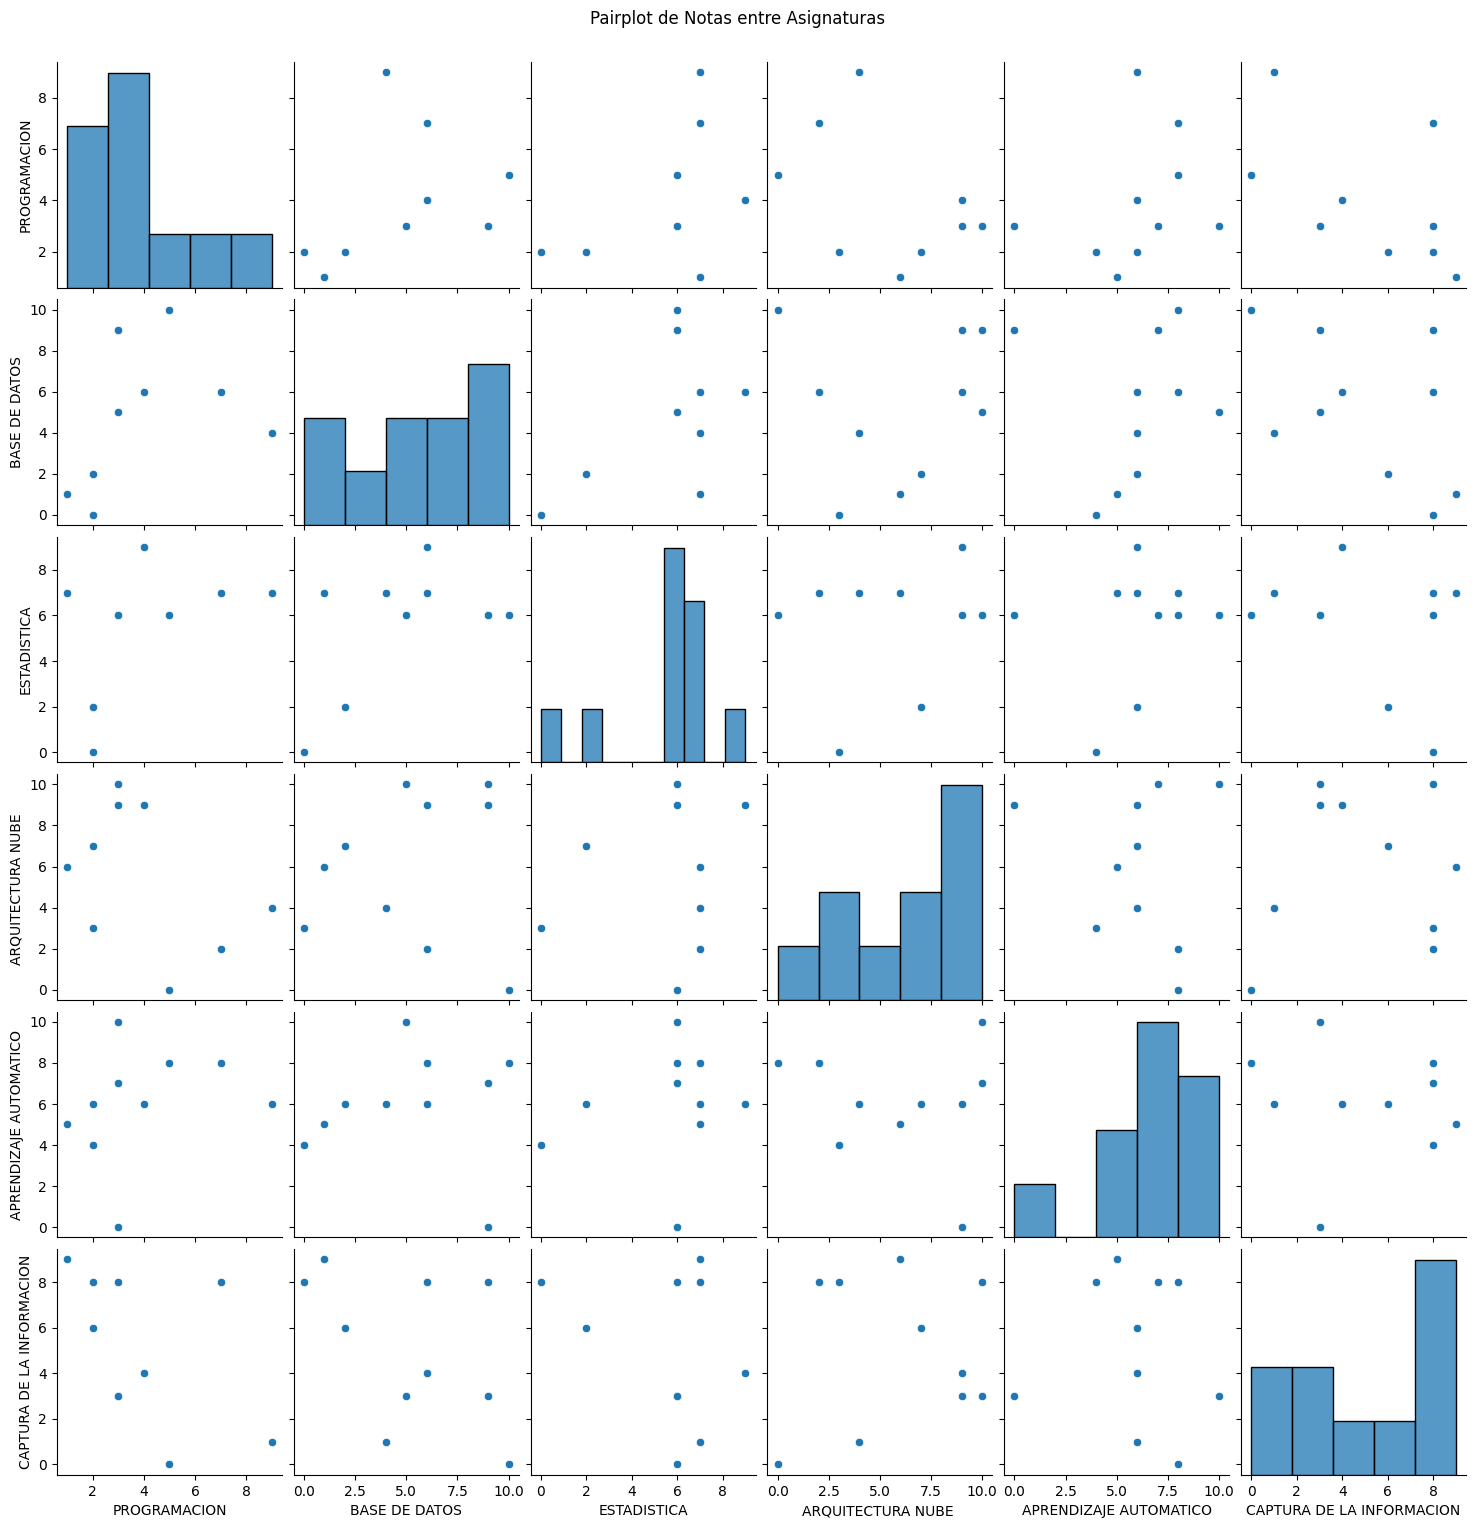

In [ ]:
# Pairplot para visualizar la dispersión entre todas las asignaturas
plt.figure(figsize=(10, 10))
sns.pairplot(df_nuevo[columnas_notas])
plt.suptitle('Pairplot de Notas entre Asignaturas', y=1.02)
plt.show()

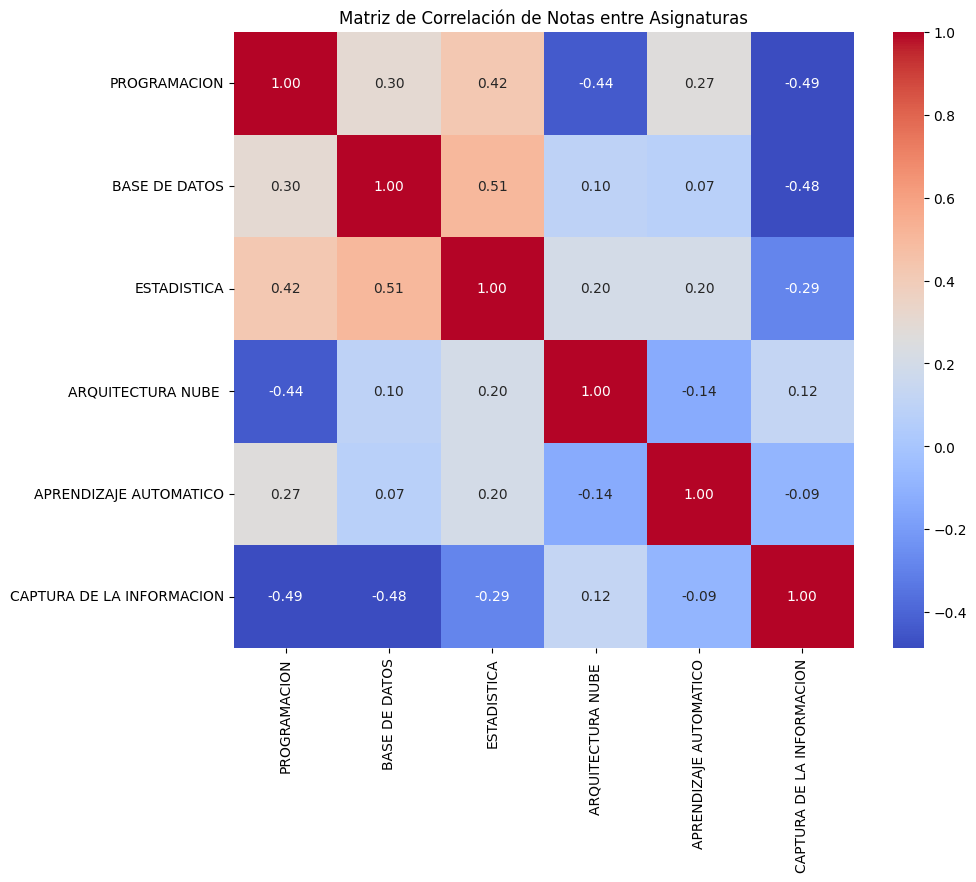

In [ ]:
# Mapa de calor para la matriz de correlación de las notas
plt.figure(figsize=(10, 8))
sns.heatmap(df_nuevo[columnas_notas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Notas entre Asignaturas')
plt.show()

**Gráfico** 2: [Relación entre edades y muerte natural como causa]
📌 Interpretación: El diagrama de dispersión de la relación entre edad y decesos por muerte natural, es una herramienta valiosa para visualizar y comprender cómo la probabilidad de muerte natural aumenta con la edad, tambien nos muestra la tendencia de dicha relación y su variabilidad dentro de los diferentes grupos de edad.

4. Presentación de resultados



*   Generar reportes claros y bien estructurados que incluyan el análisis del inciso 3. Por
ejemplo, mostrar por pantalla:
● Información detallada de cada estudiante y su situación académica.
● Estadísticas comparativas entre asignaturas.
● Resumen general del rendimiento del grupo (grafico de barras).



FFFFFFFFFFFFFFFFFFFFIIIIIIIIIIIIIIIIIIIIIIINNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN

---



**Gráfico PAIRPLOT** se utiliza para visualizar la relación entre múltiples variables. En este sentido, seleccionamos algunas columnas de las bases de datos que se consideren de mayor interés.

<Figure size 1800x700 with 0 Axes>

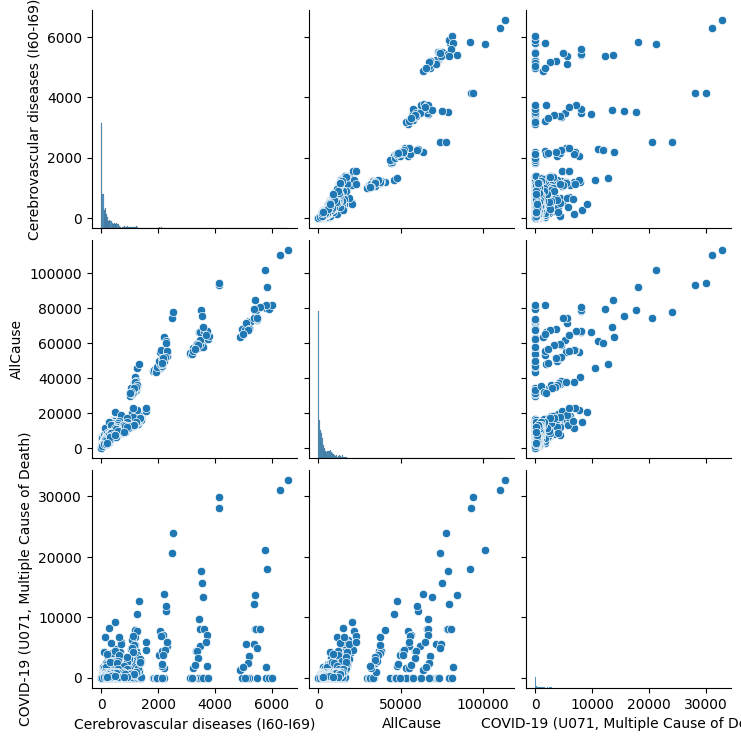

In [ ]:
# Seleccionar las columnas que te interesan
columnas_interes = ['Cerebrovascular diseases (I60-I69)' ,'AllCause','COVID-19 (U071, Multiple Cause of Death)' ]


# Generar el pairplot solo para las columnas seleccionadas
sns.pairplot(df[columnas_interes])
plt.show()


**Gráfico** 3: [Relación entre edades y muerte natural como causa]
📌 Interpretación: El grafico pairplot de diferentes causas de muerte y muertes totales explora visualmente las distribuciones individuales de cada causa, así como las relaciones bivariadas entre ellas. Puede ayudar a identificar posibles correlaciones, causas de muerte dominantes y generar hipótesis para un análisis más profundo de los patrones de mortalidad.

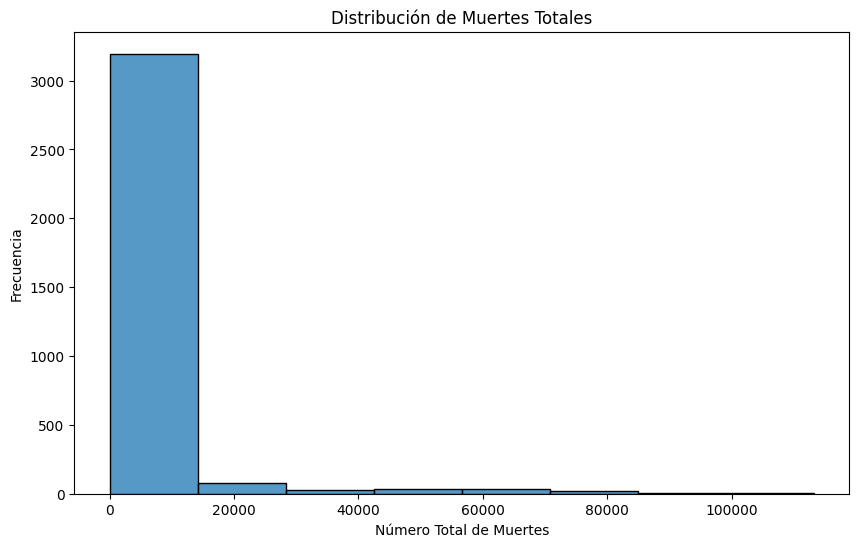

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(x="AllCause", bins=8, data=df)
plt.title("Distribución de Muertes Totales")
plt.xlabel("Número Total de Muertes")
plt.ylabel("Frecuencia")
plt.show()

**Gráfico** 4: [Distribución de muertes totales]
📌 Interpretación: Este histograma sugiere que en la mayoría de los casos observados, el número total de muertes se mantuvo relativamente bajo (entre 0 y 10000).

ANALISIS DE CORRELACION


*   MATRIZ DE CORRELACION



In [ ]:
df_numeric = df.select_dtypes(include=['float', 'int64'])

In [ ]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 17 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   Date Of Death Year                                                                                 3410 non-null   int64  
 1   Date Of Death Month                                                                                3410 non-null   int64  
 2   AllCause                                                                                           3400 non-null   float64
 3   NaturalCause                                                                                       3342 non-null   float64
 4   Septicemia (A40-A41)                                                                               2340 non-null   float

In [ ]:
df_numeric.corr()

,Date Of Death Year,Date Of Death Month,AllCause,NaturalCause,Septicemia (A40-A41),Malignant neoplasms (C00-C97),Diabetes mellitus (E10-E14),Alzheimer disease (G30),Influenza and pneumonia (J09-J18),Chronic lower respiratory diseases (J40-J47),"Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)","Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)","Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)","Diseases of heart (I00-I09,I11,I13,I20-I51)",Cerebrovascular diseases (I60-I69),"COVID-19 (U071, Multiple Cause of Death)","COVID-19 (U071, Underlying Cause of Death)"
Date Of Death Year,1.000000,-0.255453,0.022873,0.023918,-0.006233,-0.007404,0.021120,-0.004034,-0.050809,-0.022512,-0.006392,-0.002366,0.168071,0.001912,0.006359,0.178859,0.174720
Date Of Death Month,-0.255453,1.000000,-0.000463,-0.002597,-0.010273,0.003297,-0.002126,0.002568,-0.070395,-0.018909,-0.015956,-0.011420,0.001384,-0.006674,-0.003386,0.011050,0.011141
AllCause,0.022873,-0.000463,1.000000,0.998619,0.968978,0.910059,0.943293,0.841448,0.935021,0.953835,0.970368,0.984761,0.669092,0.983707,0.959419,0.663117,0.654079
NaturalCause,0.023918,-0.002597,0.998619,1.000000,0.966829,0.906863,0.938590,0.848967,0.937240,0.957236,0.973020,0.986793,0.658640,0.985760,0.964271,0.666474,0.657451
Septicemia (A40-A41),-0.006233,-0.010273,0.968978,0.966829,1.000000,0.964122,0.973867,0.722447,0.910257,0.976048,0.979642,0.977287,0.629554,0.943401,0.899060,0.548161,0.539430
Malignant neoplasms (C00-C97),-0.007404,0.003297,0.910059,0.906863,0.964122,1.000000,0.987699,0.572041,0.811373,0.943715,0.927597,0.912737,0.552499,0.862552,0.791783,0.506924,0.498901
Diabetes mellitus (E10-E14),0.021120,-0.002126,0.943293,0.938590,0.973867,0.987699,1.000000,0.624355,0.846715,0.945671,0.937439,0.932111,0.589699,0.890663,0.829035,0.599201,0.591963
Alzheimer disease (G30),-0.004034,0.002568,0.841448,0.848967,0.722447,0.572041,0.624355,1.000000,0.857914,0.754242,0.790963,0.836430,0.632506,0.898247,0.945828,0.493527,0.482112
Influenza and pneumonia (J09-J18),-0.050809,-0.070395,0.935021,0.937240,0.910257,0.811373,0.846715,0.857914,1.000000,0.927773,0.938798,0.945969,0.613840,0.955888,0.938564,0.495238,0.487483
Chronic lower respiratory diseases (J40-J47),-0.022512,-0.018909,0.953835,0.957236,0.976048,0.943715,0.945671,0.754242,0.927773,1.000000,0.990838,0.979359,0.592383,0.939648,0.912484,0.509611,0.501512


***MAPA DE CALOR***

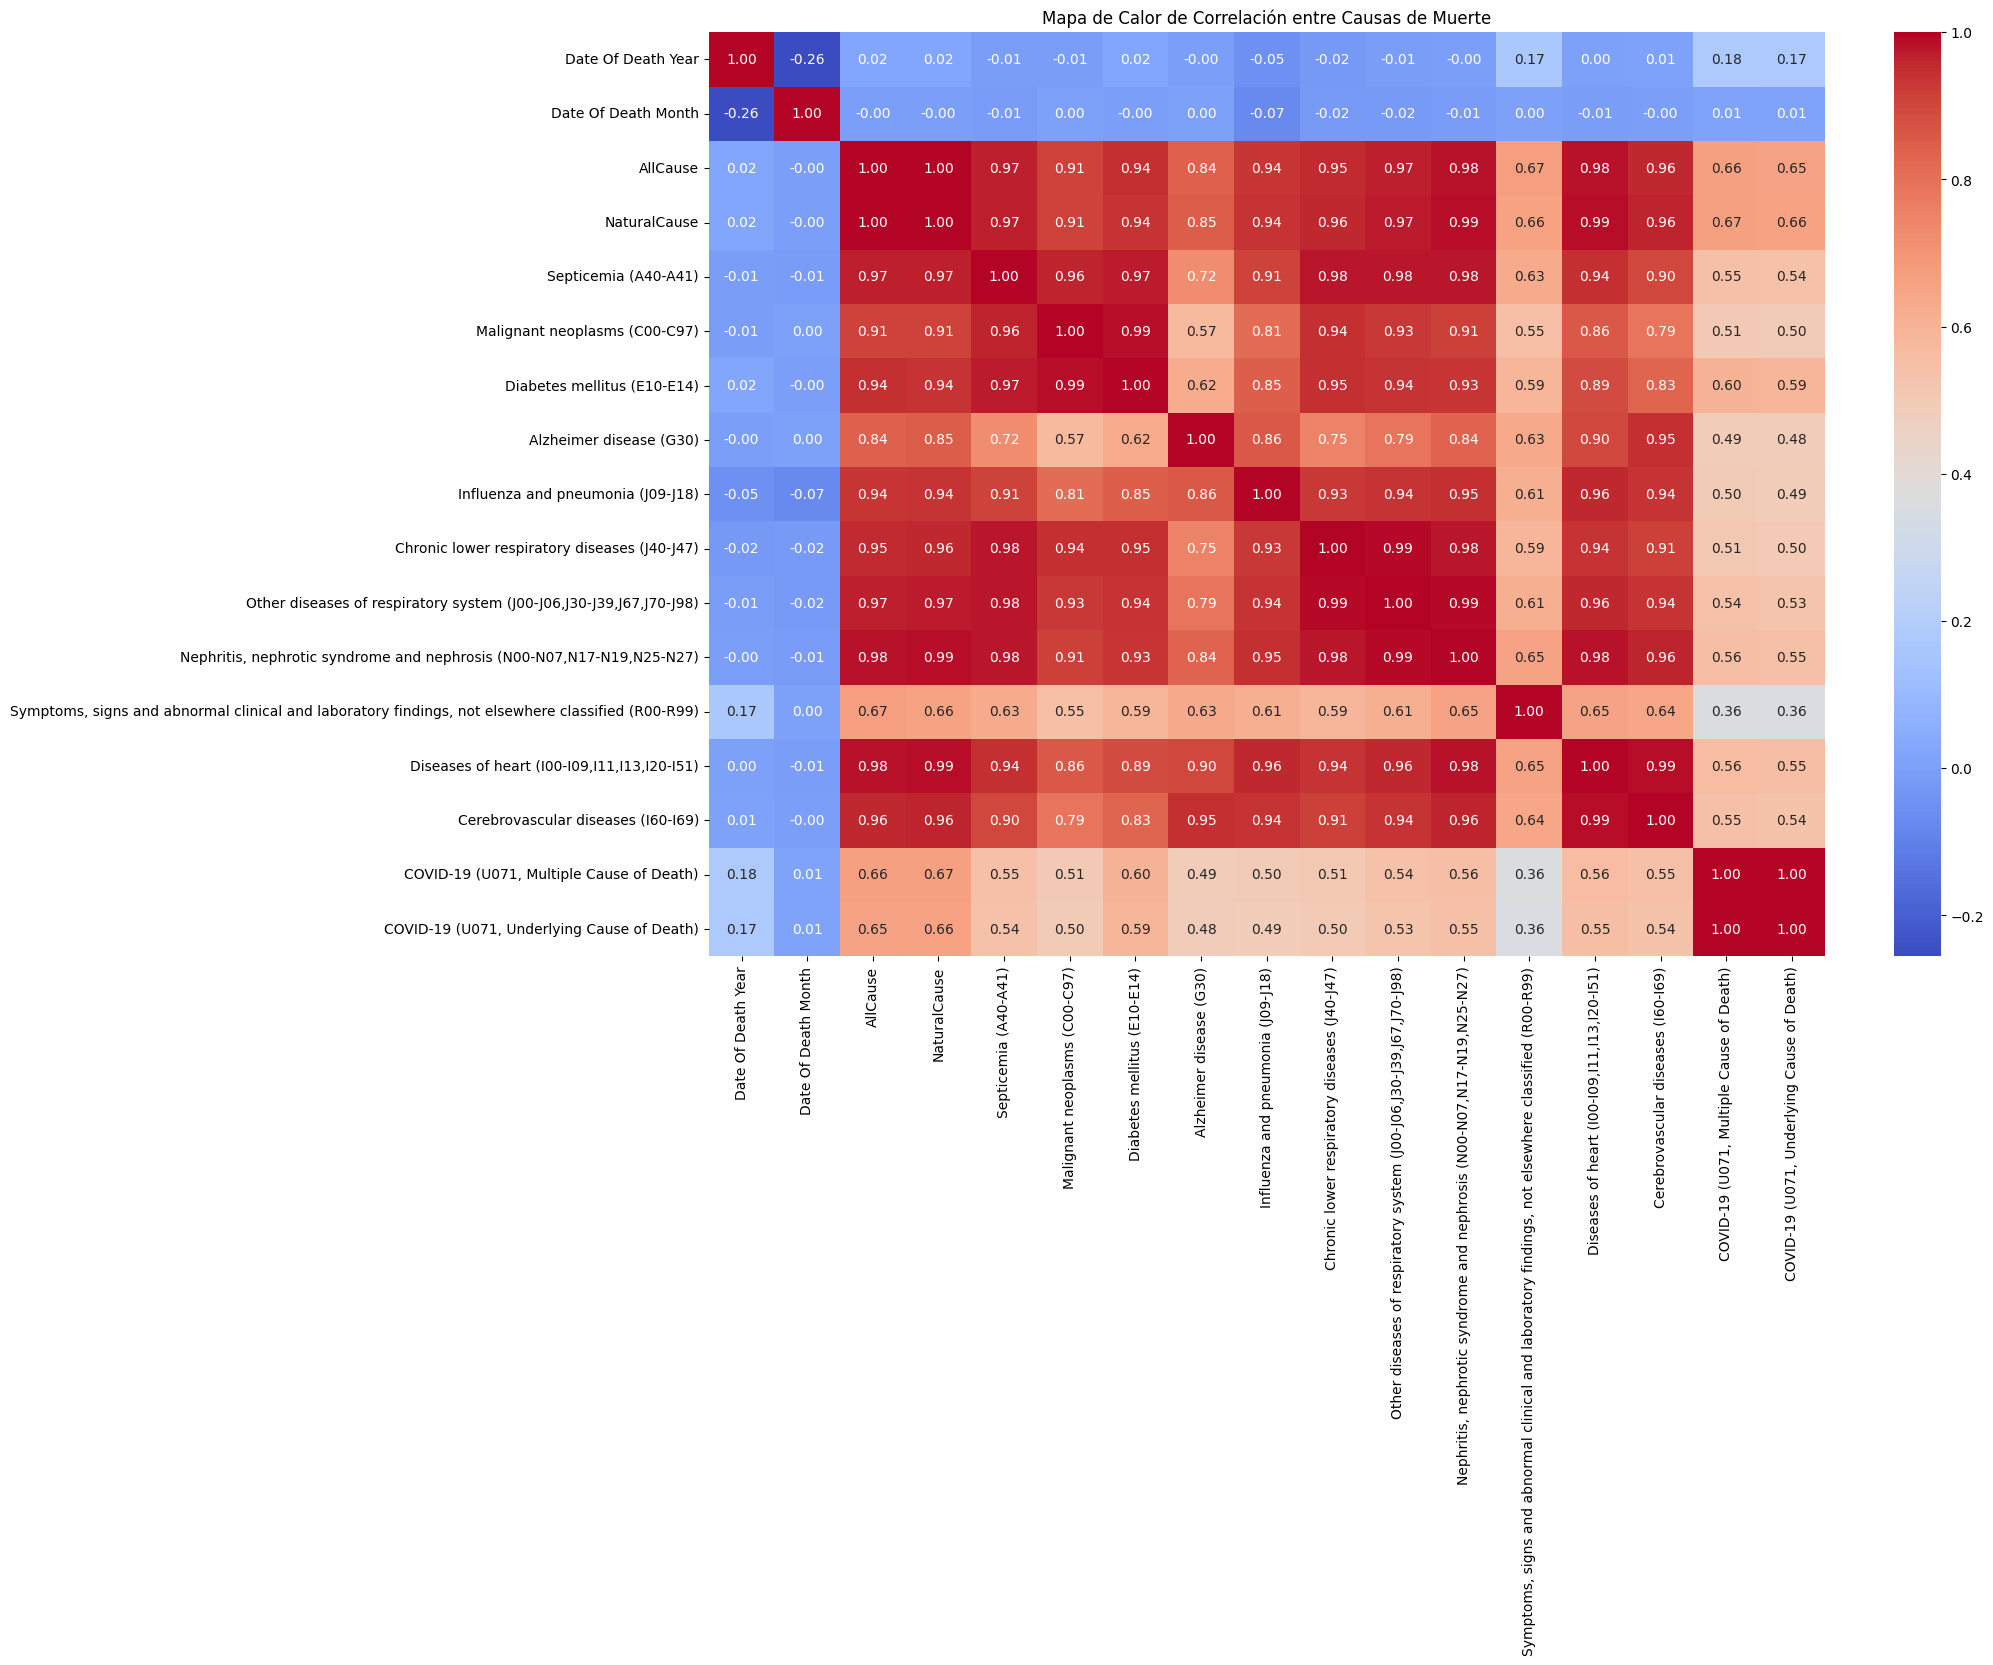

In [ ]:
# Seleccionar solo las columnas numéricas
df_numeric = df.select_dtypes(include='number')

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Generar el mapa de calor
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Mapa de Calor de Correlación entre Causas de Muerte")
plt.show()

**Gráfico** 5: [DistribuciónMapa de calor de correlación entre causas de muertes]
📌 Interpretación: La barra de color a la derecha indica la intensidad y dirección de la correlación: Rojo intenso: Correlación positiva (valores cercanos a +1). Indica que cuando una causa de muerte aumenta, la otra también tiende a aumentar. Azul intenso: Correlación negativa (valores cercanos a -1). Indica que cuando una causa de muerte aumenta, la otra tiende a disminuir. Blanco: Correlación cercana a cero (valores alrededor de 0). Indica una relación lineal débil o nula entre las dos causas de muerte.

La diagonal principal del mapa de calor siempre será de color rojo intenso (correlación de 1.00) porque una variable siempre está perfectamente correlacionada consigo misma.

### 3. Observaciones generales
Breve resumen del análisis: ¿Qué patrones se observan? ¿Hay calidad en los datos? ¿Qué variables resultan más interesantes?




Los patrones observados de la base de datos analizada, presenta las pricipales características:


1.   Se pueden observar diferencias en el número de muertes por
diversas causas entre los años 2019, 2020 y 2021. Por ejemplo, es probable que se vea un aumento significativo en las muertes relacionadas con COVID-19 en 2020 y 2021 en comparación con 2019.

2. Las cifras de muertes varían considerablemente entre los diferentes grupos de edad para cada causa. Generalmente, se esperaría un mayor número de muertes en los grupos de que se encuentran en el rango etario de ("75 a mayores de 85 años") para muchas causas crónicas como enfermedades cardíacas, cáncer y Alzheimer.

3. El impacto del COVID-19, muestran un aumento notable en los años 2020 y 2021, lo que refleja el impacto de la pandemia.

Acerca de la calidad de datos,la base de datos cuenta con una estructura consistente con encabezados de columna definidos y datos que corresponden a esas categorías.Incluye datos que nos propociona un contexto pre y post-inicio de la pandemia.Ademas, nos detalla la causas de las muertes y su impacto a traves del tiempo.

Finalmente, entre las variables que resultan de mayor interés se destacan las siguientes:

***AllCause:*** Nos brinda la visión general de la mortalidad.


***COVID-19 (U071 y U072):*** Permite comprender la evolución temporal  del virus y por grupo demográfico.

***AgeGroup:*** Analiza la vulnerabilidad de diferentes grupos de edad a diversas causas de muerte, en particular, en el contexto de la pandemia.





---
## 📁 EDA Dataset 3 – [DDD_dataset_reducido.xlsx] (Integrante: Gabriel Marquez)

### 1. Carga y exploración de datos


In [ ]:
# Código para cargar el dataset y mostrar estructura


Primero importamos las librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Montamos el drive para ingresar el dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
data_path = '/content/drive/MyDrive/Desarrollo de Sistemas con IA - EDA - Gabriel Marquez/DDD_dataset_reducido.xlsx'
ev_data = pd.read_excel(data_path)

Muestro el tipo de dataset

In [ ]:
print("Estructura")
print(ev_data.info())

Estructura
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851 entries, 0 to 850
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mercado             851 non-null    object 
 1   Distrito            851 non-null    object 
 2   Territorio FDV      851 non-null    object 
 3   CP                  851 non-null    object 
 4   Código de CP        851 non-null    int64  
 5   Producto            851 non-null    object 
 6   Feb 2023
App Units  622 non-null    float64
 7   Mar 2023
App Units  628 non-null    float64
 8   Apr 2023
App Units  601 non-null    float64
dtypes: float64(3), int64(1), object(5)
memory usage: 60.0+ KB
None


Mostrar los primeros 5 registros

In [ ]:
print("\Primeros5")
print(ev_data.head(5))

\Primeros5
             Mercado      Distrito Territorio FDV                         CP  \
0  Mercado Triplixam  BUENOS AIRES     AR_ALMAGRO  1030 - LARREA 1/ 800 (C )   
1  Mercado Triplixam  BUENOS AIRES     AR_ALMAGRO  1030 - LARREA 1/ 800 (C )   
2  Mercado Triplixam  BUENOS AIRES     AR_ALMAGRO  1030 - LARREA 1/ 800 (C )   
3  Mercado Triplixam  BUENOS AIRES     AR_ALMAGRO  1030 - LARREA 1/ 800 (C )   
4  Mercado Triplixam  BUENOS AIRES     AR_ALMAGRO  1030 - LARREA 1/ 800 (C )   

   Código de CP               Producto  Feb 2023\nApp Units  \
0          1030       DISARVAL D (B+L)                  NaN   
1          1030        EXFORGE D (SIE)                  NaN   
2          1030         NOSTER D (RF2)                  NaN   
3          1030  SIMULTAN TRIPLE (LZA)                  NaN   
4          1030        TRIPLIXAM (SVR)                  NaN   

   Mar 2023\nApp Units  Apr 2023\nApp Units  
0                 11.0                  NaN  
1                  NaN               

Resumen de las variables

In [ ]:
print("\Rvariable")
print(ev_data.describe(include='all'))

\Rvariable
                  Mercado      Distrito Territorio FDV  \
count                 851           851            851   
unique                  1             3             16   
top     Mercado Triplixam  BUENOS AIRES     AR_SURESTE   
freq                  851           541            246   
mean                  NaN           NaN            NaN   
std                   NaN           NaN            NaN   
min                   NaN           NaN            NaN   
25%                   NaN           NaN            NaN   
50%                   NaN           NaN            NaN   
75%                   NaN           NaN            NaN   
max                   NaN           NaN            NaN   

                                        CP  Código de CP        Producto  \
count                                  851    851.000000             851   
unique                                 141           NaN               7   
top     5000 - CORDOBA(& BRICKS VS)   (X )           NaN  NOSTER

### 2. Visualizaciones y análisis




#**Diagrama de dispersión**


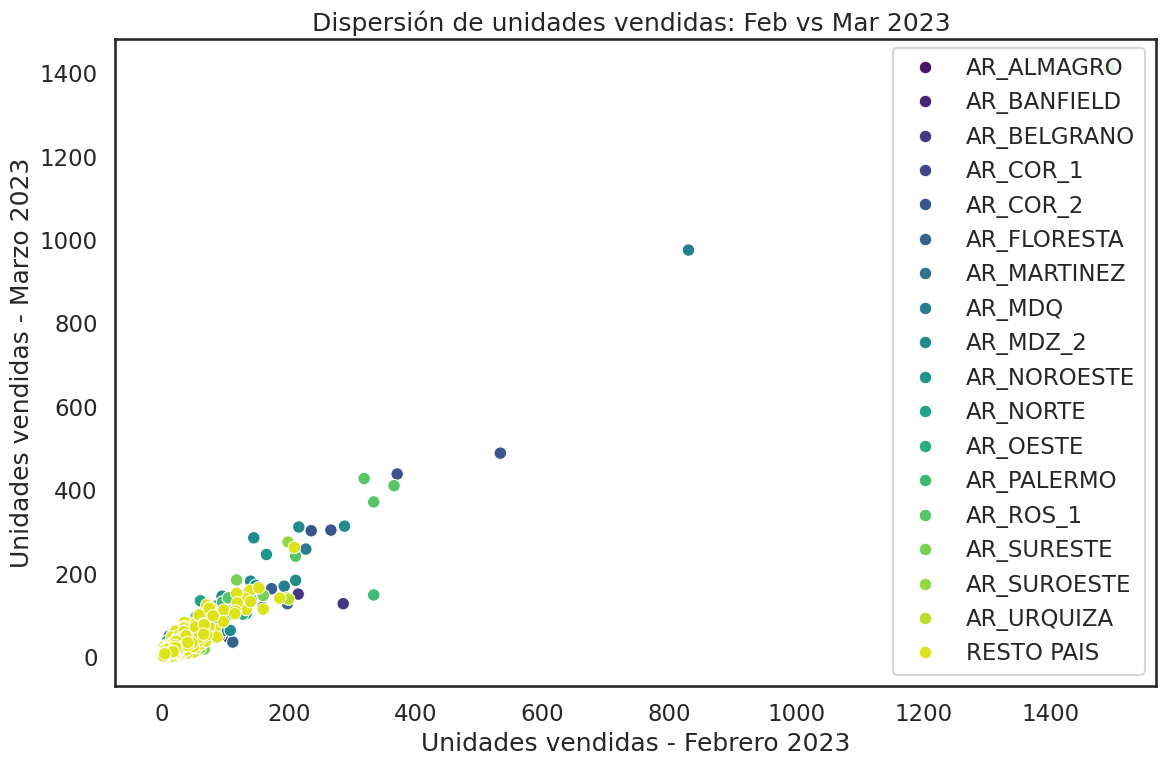

In [ ]:
#los nombres de columnas no tengan espacios raros
df.columns = df.columns.str.strip()

#grafico con color por Territorio
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="Feb 2023\nApp Units",
    y="Mar 2023\nApp Units",
    hue="Territorio FDV",
    data=df,
    palette='viridis'
)

plt.xlabel("Unidades vendidas - Febrero 2023")
plt.ylabel("Unidades vendidas - Marzo 2023")
plt.title("Dispersión de unidades vendidas: Feb vs Mar 2023 ")
plt.legend(loc='lower right', bbox_to_anchor=(1, 0))  #leyenda fuera del gráfico
plt.tight_layout()
plt.show()


- Gráfico 1: [Dispersión de unidades vendidas febrero vs marzo]  
📌 *Si la mayoría de los puntos están en una línea diagonal ascendente, es que los territorios con mayores ventas en febrero también han tenido buenas ventas en marzo.*

#**Gráfico de barras venta por territorio**

<ipython-input-54-11cd0184cfed>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Territorio FDV', y='Mar 2023\nApp Units', data=df, palette='viridis')


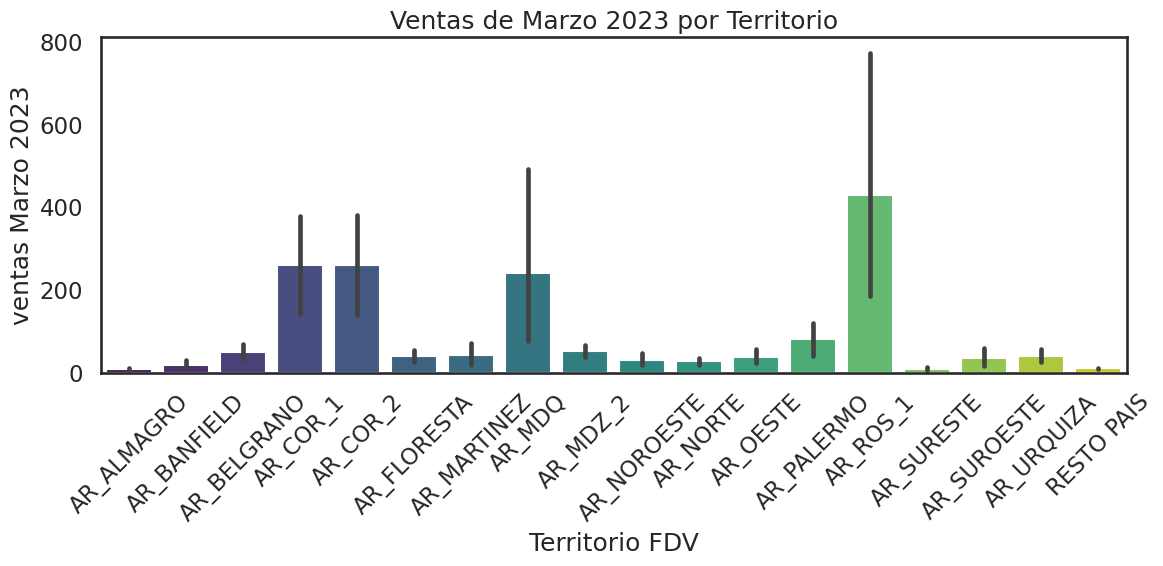

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(x='Territorio FDV', y='Mar 2023\nApp Units', data=df, palette='viridis')

plt.title("Ventas de Marzo 2023 por Territorio")
plt.xlabel("Territorio FDV")
plt.ylabel("ventas Marzo 2023")
plt.xticks(rotation=45)  #rotar las etiquetas de los territorios
plt.tight_layout()

plt.show()

- Gráfico 2: [Ventas por territorio]  
📌 *Interpretación: Este gráfico facilita la comparación directa entre territorios, centrandose en ver cuál se destaca por sus ventas en marzo de 2023 y cuáles tienen un desempeño más bajo.*

#**Gráfico de barras venta por producto**

<ipython-input-56-ce61f4c85455>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Producto', y='Mar 2023\nApp Units', data=df, palette='viridis')


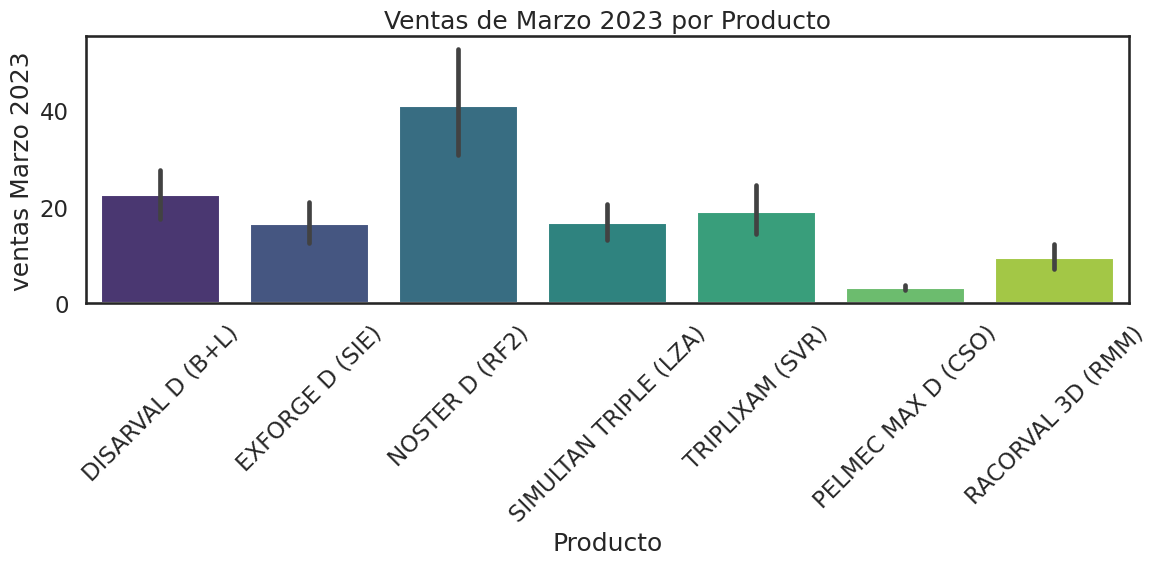

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(x='Producto', y='Mar 2023\nApp Units', data=df, palette='viridis')

plt.title("Ventas de Marzo 2023 por Producto")
plt.xlabel("Producto")
plt.ylabel("ventas Marzo 2023")
plt.xticks(rotation=45)  #rotar las etiquetas de los territorios
plt.tight_layout()

plt.show()

- Gráfico 3: [Venta por producto]  
📌 *Interpretación: Este gráfico muestra, en el periodo de marzo 2023 la cantidad de venta dividida por producto, parecido al anterior, pero con otra comparativa.*

#**Mapa de calor venta por territorio**

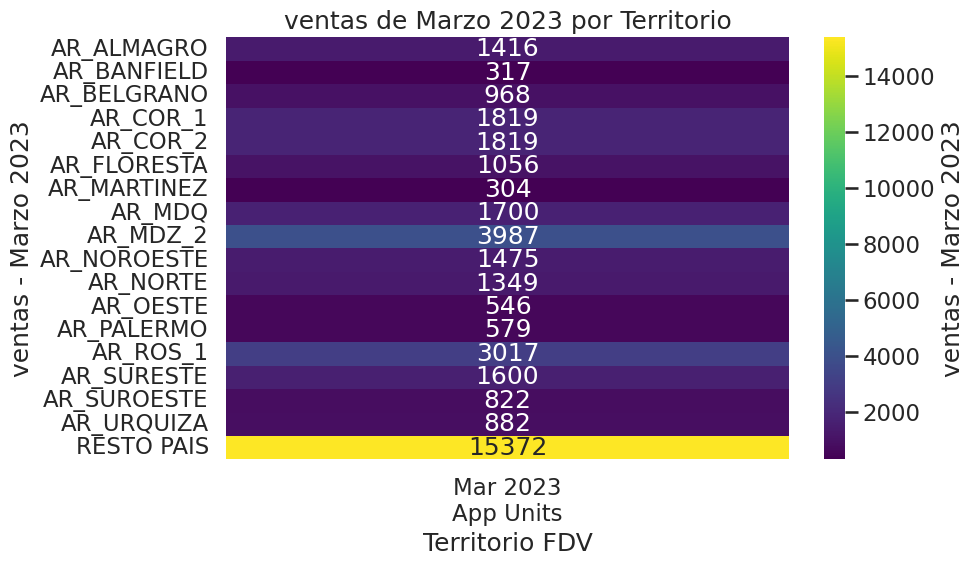

In [ ]:
#agrupar por territorio y calcular la suma de unidades para marzo 2023
heatmap_data = df.groupby('Territorio FDV')['Mar 2023\nApp Units'].sum().reset_index()

#convertir a formato (matriz)
heatmap_matrix = heatmap_data.pivot_table(index='Territorio FDV', values='Mar 2023\nApp Units')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_matrix, annot=True, cmap='viridis', fmt='g', cbar_kws={'label': 'ventas - Marzo 2023'})

plt.title("ventas de Marzo 2023 por Territorio")
plt.xlabel("Territorio FDV")
plt.ylabel("ventas - Marzo 2023")
plt.tight_layout()

plt.show()

- Gráfico 4: [Mapa de calor, venta por territorio]  
📌 *Interpretación: Se observa qué territorios tienen las ventas más altas y cuáles tienen las ventas más bajas. Los territorios con un color más claro tendrán más ventas, mientras que los más oscuros (o más fríos) indicarán ventas más bajas. Si el gráfico muestra que algunos territorios están consistentemente más iluminados (más ventas) que otros, indican que estos territorios tienen una demanda más alta o mejores condiciones de ventas en marzo.*

### 3. Observaciones generales

**Variables mas importantes**
- **Territorio FDV**: Esta variable es clave porque permite segmentar las ventas por ubicación geográfica o sector. Los diferentes territorios pueden tener comportamientos de ventas muy distintos, lo que es relevante para ajustar estrategias de marketing o distribución.
- **Ventas de marzo 2023** (Mar 2023\nApp Units): Es una de las variables más importantes para evaluar el rendimiento reciente. En particular, la comparación con las ventas de febrero ayuda a entender si hay crecimiento, estancamiento o declive en las ventas.
- **Ventas de febrero 2023** (Feb 2023\nApp Units): Aunque no se analiza tanto en los últimos gráficos, la relación con las ventas de marzo podría dar más contexto sobre tendencias a corto plazo.

**Calidad de los datos**
- **Profundizar en territorios con ventas atípicas:** Centrarse en que algunos territorios tienen ventas excepcionalmente altas o bajas, es interesante investigar las causas de esos patrones, ya sea por condiciones del mercado local, promociones, o factores externos.

- **Tomar en cuenta posibles correlaciones:** Obtener mas datos que incluyan más variables (como características demográficas, marketing o productos vendidos), se podría explorar si hay factores adicionales que estén influyendo en las ventas por territorio.

- **Control de calidad:** Tratar de que los datos estén completos y que no falten valores importantes (por ejemplo, territorios sin ventas reportadas o valores nulos en las columnas clave). También hacer un análisis de valores atípicos o errores de digitación.


---
## 📁 EDA Dataset 4 – [MOCK_DATA_1.csv] (Integrante: Monica Casco)

### 1. Carga y exploración de datos


In [ ]:
# Código para cargar el dataset y mostrar estructura


In [ ]:
import seaborn as sns
import pandas as pd

tips = sns.load_dataset("tips")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dt = pd.read_csv('/content/drive/MyDrive/MOCK_DATA_1.csv')

In [ ]:
tips.shape

(244, 7)

In [ ]:
dt.dtypes

,0
id,int64
first_name,object
last_name,object
email,object
gender,object
ip_address,object
ip_address1,object
ip_address2,object
ip_address3,object


In [ ]:
dt.shape

(2500, 9)

In [ ]:
dt.dtypes

,0
id,int64
first_name,object
last_name,object
email,object
gender,object
ip_address,object
ip_address1,object
ip_address2,object
ip_address3,object


# Head y Tail
Podemos utilizar las funciones `head` y `tail` de pandas para ver las primeras y últimas filas del conjunto de datos, respectivamente:

In [ ]:
dt.head(3)

,id,first_name,last_name,email,gender,ip_address,ip_address1,ip_address2,ip_address3
0,1,Benny,Cagan,bcagan0@irs.gov,Male,214.40.197.74,11.137.212.248,97.108.190.134,9.179.57.225
1,2,Gwynne,Wilder,gwilder1@baidu.com,Female,154.118.247.225,123.90.32.233,187.191.0.160,71.119.81.87
2,3,Lockwood,Dinjes,ldinjes2@google.pl,Male,47.238.50.40,64.159.255.61,47.232.139.142,102.13.179.144


In [ ]:
dt.tail()

,id,first_name,last_name,email,gender,ip_address,ip_address1,ip_address2,ip_address3
2495,2000496,Basilius,Sowerbutts,bsowerbuttsdr@canalblog.com,Male,203.147.43.160,143.74.83.196,215.190.162.83,215.13.55.133
2496,2000497,Jase,Torres,jtorresds@miibeian.gov.cn,Polygender,123.192.129.50,185.103.2.231,89.141.79.87,141.109.137.168
2497,2000498,Davidson,Kolin,dkolindt@scientificamerican.com,Polygender,57.240.112.89,9.33.90.185,179.146.147.118,4.39.140.164
2498,2000499,Constance,Wildgoose,cwildgoosedu@friendfeed.com,Female,189.187.114.137,129.150.13.79,111.190.98.93,154.225.61.181
2499,2000500,Constance,Wildgoose,cwildgoosedu@friendfeed.com,Female,189.187.114.137,129.150.13.79,111.190.98.93,154.225.61.182


Esto nos dará una idea de cómo se ven los datos y qué tipo de información contienen.


## Descripción general del conjunto de datos
Podemos obtener una descripción general del conjunto de datos utilizando la función `describe` de pandas:

In [ ]:
dt.describe()

,id
count,2.500000e+03
mean,6.961585e+05
std,7.480552e+05
min,1.000000e+00
25%,6.257500e+02
50%,1.000152e+06
75%,1.000776e+06
max,1.000100e+07


In [ ]:
dt.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2500.0,696158.5,748055.184839,1.0,625.75,1000151.5,1000776.25,10001000.0


In [ ]:
dt.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2500.0,NaN,NaN,NaN,696158.5,748055.184839,1.0,625.75,1000151.5,1000776.25,10001000.0
first_name,2500,935,Bennie,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,2500,987,Le Gallo,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email,2500,1000,cwildgoosedu@friendfeed.com,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,2500,8,Female,1148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_address,2500,1000,189.187.114.137,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_address1,2500,1000,129.150.13.79,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_address2,2500,1000,111.190.98.93,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_address3,2500,1001,154.225.61.181,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dt.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2500.0,696158.5,748055.184839,1.0,625.75,1000151.5,1000776.25,10001000.0


Esto nos dará algunas estadísticas básicas sobre las variables numéricas en el conjunto de datos, como el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los percentiles.


## Información de las columnas
Podemos obtener información sobre las columnas en el conjunto de datos utilizando la función `info` de pandas:

In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           2500 non-null   int64 
 1   first_name   2500 non-null   object
 2   last_name    2500 non-null   object
 3   email        2500 non-null   object
 4   gender       2500 non-null   object
 5   ip_address   2500 non-null   object
 6   ip_address1  2500 non-null   object
 7   ip_address2  2500 non-null   object
 8   ip_address3  2500 non-null   object
dtypes: int64(1), object(8)
memory usage: 175.9+ KB


In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

Esto nos dará información sobre el número de valores no nulos en cada columna y el tipo de datos de cada columna.

In [ ]:
dt.isnull().sum()

,0
id,0
first_name,0
last_name,0
email,0
gender,0
ip_address,0
ip_address1,0
ip_address2,0
ip_address3,0


In [ ]:
dt.isnull()

,id,first_name,last_name,email,gender,ip_address,ip_address1,ip_address2,ip_address3
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
2495,False,False,False,False,False,False,False,False,False
2496,False,False,False,False,False,False,False,False,False
2497,False,False,False,False,False,False,False,False,False
2498,False,False,False,False,False,False,False,False,False


# Ejemplo de Análisis Exploratorio de Datos
A continuación, utilizaremos el conjunto de datos iris incluido en scikit-learn para realizar un ejemplo de Análisis Exploratorio de Datos.

## Importando librerías y cargando el conjunto de datos
Comenzamos importando las librerías necesarias y cargando el conjunto de datos:

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [ ]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

En este ejemplo, utilizamos `load_iris` de scikit-learn para cargar el conjunto de datos `iris`. Luego, creamos un objeto `DataFrame` de pandas con los datos y agregamos una columna para el objetivo (target) del conjunto de datos.

## Explorando el conjunto de datos
Ahora, podemos comenzar a explorar el conjunto de datos utilizando las funciones que hemos discutido anteriormente:

In [ ]:
# Explorando el conjunto de datos
print("Filas y columnas\n")
print(df.shape)
print("\nTipos de Dato\n")
print(df.dtypes)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

Filas y columnas

(150, 5)

Tipos de Dato

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1 

Esto nos dará una idea general del conjunto de datos. Podemos ver que el conjunto de datos tiene 150 observaciones y 5 variables. No hay valores nulos en el conjunto de datos.

In [ ]:
df.shape

(150, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


# Visualización de datos
La visualización de datos es una parte importante del EDA, ya que nos permite ver patrones y relaciones que podrían no ser evidentes en una tabla de datos. seaborn ofrece una amplia gama de herramientas para la visualización de datos.

## Diagrama de dispersión (scatter plot)
Una forma común de visualizar la relación entre dos variables numéricas es mediante un diagrama de dispersión. seaborn hace que sea fácil crear un diagrama de dispersión utilizando la función scatterplot:

<ipython-input-17-0f08f98c7274>:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


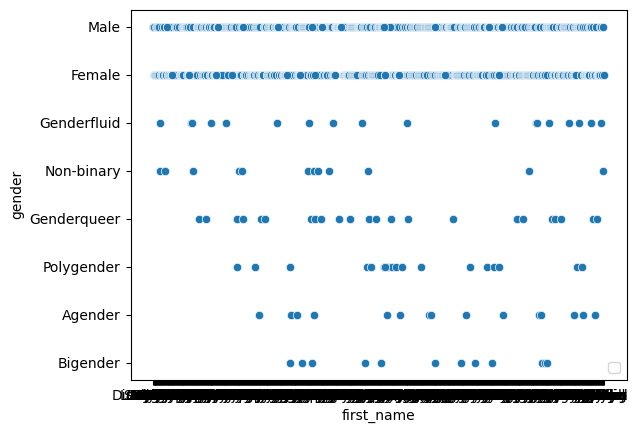

In [ ]:
import matplotlib.pyplot as plt
sns.scatterplot(x="first_name", y="gender", data=dt) #, hue='day', palette='viridis')
plt.legend(loc='lower right')

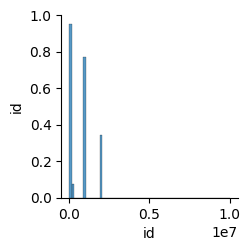

In [ ]:
sns.pairplot(dt) #, hue='day')

Las paletas de colores más populares pueden variar según la comunidad y las tendencias actuales en visualización de datos. Se utiliza una variable incremental donde no existe repeticion o moda.




## Diagrama de barras (bar plot)
Otra forma común de visualizar los datos es mediante un diagrama de barras, que se utiliza para mostrar la distribución de una variable categórica. seaborn hace que sea fácil crear un diagrama de barras utilizando la función `countplot`:

<Axes: xlabel='gender', ylabel='count'>

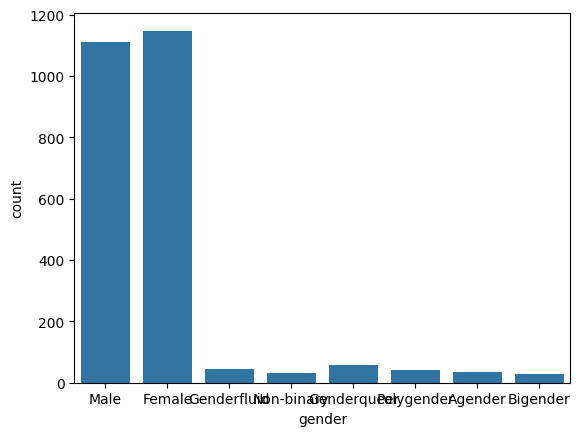

In [ ]:
sns.countplot(x="gender", data=dt)

Esto nos dará un diagrama de barras de la distribución de la variable gender en el conjunto de datos. Podemos ver que el número de hombres o mujeres

## Histograma (histogram)
Un histograma es una forma común de visualizar la distribución de una variable numérica. seaborn hace que sea fácil crear un histograma utilizando la función `histplot`:

<Axes: xlabel='gender', ylabel='Count'>

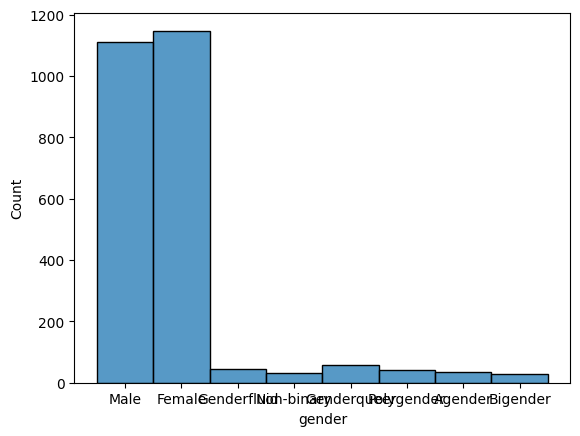

In [ ]:
sns.histplot(x="gender", bins = 8, data=dt)

Esto nos dará un histograma de la distribución hombres y mujeres por genero

# Análisis de correlación
El análisis de correlación es una parte importante del EDA, ya que nos permite ver la relación entre las variables numéricas en el conjunto de datos. Una forma común de analizar la correlación es mediante el cálculo de la matriz de correlación y la visualización de la misma mediante un mapa de calor.

## Matriz de correlación (correlation matrix)
Podemos calcular la matriz de correlación utilizando la función `corr` de pandas:

In [ ]:
dtNumerico = dt.select_dtypes(include=['float', 'int64'])

In [ ]:
dtNumerico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2500 non-null   int64
dtypes: int64(1)
memory usage: 19.7 KB


In [ ]:
dtNumerico.corr()

,id
id,1.0


Esto nos dará una matriz de correlación que muestra la correlación entre todas las variables numéricas en el conjunto de datos.

## Mapa de calor (heatmap)
Podemos visualizar la matriz de correlación utilizando un mapa de calor. seaborn hace que sea fácil crear un mapa de calor utilizando la función `heatmap`:

<Axes: >

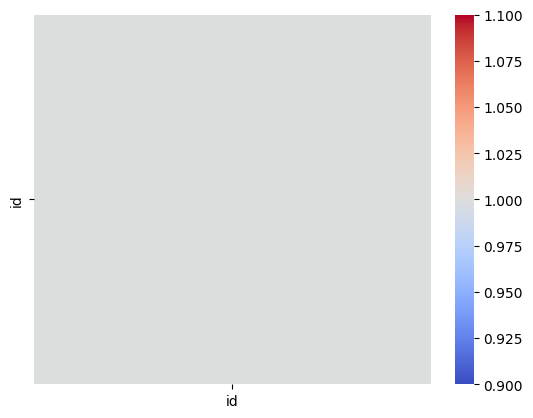

In [ ]:
sns.heatmap(dtNumerico.corr(), cmap='coolwarm')

Esto nos dará un mapa de calor que muestra la correlación entre todas las variables numéricas en el conjunto de datos. La unica variable para poder utilizar es el id por esta razon este dataset no tiene utilidad para un analisis integral.

### 3. Observaciones generales
El análisis del dataset nos permite interpretar una distribución y tendencias para conclusiones posteriores. En este caso sólo nominalmente nombres y direcciones las cuales no aportan información relevante para un análisis.

---
## 📁 EDA Dataset 5 – imdb_top_5000_tv_shows.csv (Juan Carabetta)

### 1. Carga y exploración de datos


In [ ]:
# Código para cargar el dataset y mostrar estructura

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Classroom/2025C - DESARROLLO DE SISTEMAS DE IA 1° Año - 2° Cuat - Ciencia de Datos e IA/imdb_top_5000_tv_shows.csv')

In [ ]:
df.shape # tiene 5mil filas y 12 columnas

(5000, 12)

In [ ]:
df.dtypes # vemos los tipos de datos que contiente el df

,0
tconst,object
primaryTitle,object
startYear,int64
endYear,float64
rank,int64
averageRating,float64
numVotes,int64
directors,object
writers,object
genres,object


In [ ]:
df.head() #los primeros 5 registros

,tconst,primaryTitle,startYear,endYear,rank,averageRating,numVotes,directors,writers,genres,IMDbLink,Title_IMDb_Link
0,tt0903747,Breaking Bad,2008,2013.0,1,9.5,2313754,"Michelle MacLaren, Adam Bernstein, Vince Gilli...","Vince Gilligan, Peter Gould, George Mastras, S...","Crime, Drama, Thriller","<a href=""https://www.imdb.com/title/tt0903747""...","<a href=""https://www.imdb.com/title/tt0903747""..."
1,tt0185906,Band of Brothers,2001,2001.0,2,9.4,559333,"David Frankel, Mikael Salomon, Tom Hanks, Davi...","Stephen Ambrose, Erik Bork, E. Max Frye, Tom H...","Action, Drama, History","<a href=""https://www.imdb.com/title/tt0185906""...","<a href=""https://www.imdb.com/title/tt0185906""..."
2,tt7366338,Chernobyl,2019,2019.0,3,9.3,942685,Johan Renck,Craig Mazin,"Drama, History, Thriller","<a href=""https://www.imdb.com/title/tt7366338""...","<a href=""https://www.imdb.com/title/tt7366338""..."
3,tt0795176,Planet Earth,2006,2006.0,4,9.4,226942,"Alastair Fothergill, Mark Linfield","David Attenborough, Vanessa Berlowitz, Alastai...","Documentary, Family","<a href=""https://www.imdb.com/title/tt0795176""...","<a href=""https://www.imdb.com/title/tt0795176""..."
4,tt5491994,Planet Earth II,2016,2016.0,5,9.4,166009,"Justin Anderson, Ed Charles, Fredi Devas, Chad...",Elizabeth White,Documentary,"<a href=""https://www.imdb.com/title/tt5491994""...","<a href=""https://www.imdb.com/title/tt5491994""..."


In [ ]:
df.tail() # los ultimos registros

,tconst,primaryTitle,startYear,endYear,rank,averageRating,numVotes,directors,writers,genres,IMDbLink,Title_IMDb_Link
4995,tt1372211,Victorian Farm,2009,2009.0,4996,8.8,780,Stuart Elliott,Stuart Elliott,"Documentary, History","<a href=""https://www.imdb.com/title/tt1372211""...","<a href=""https://www.imdb.com/title/tt1372211""..."
4996,tt3139942,Bridal Mask,2012,2012.0,4997,8.1,780,Yoon Sung-shik,Yu Hyeon-mi,"Action, Drama, History","<a href=""https://www.imdb.com/title/tt3139942""...","<a href=""https://www.imdb.com/title/tt3139942""..."
4997,tt2882382,Gerçek Kesit,1993,2006.0,4998,7.9,780,-,-,"Action, Crime, Fantasy","<a href=""https://www.imdb.com/title/tt2882382""...","<a href=""https://www.imdb.com/title/tt2882382""..."
4998,tt14048662,When NEET Aspirant Met an IIT Aspirant,2021,2021.0,4999,8.1,779,Aarjun Verma,Aarjun Verma,"Comedy, Romance","<a href=""https://www.imdb.com/title/tt14048662...","<a href=""https://www.imdb.com/title/tt14048662..."
4999,tt2057193,Simon's Cat,2008,NaN,5000,8.0,779,Simon Tofield,Simon Tofield,"Animation, Comedy","<a href=""https://www.imdb.com/title/tt2057193""...","<a href=""https://www.imdb.com/title/tt2057193""..."


In [ ]:
df.describe() # descripcion de las numericas

,startYear,endYear,rank,averageRating,numVotes
count,5000.00000,4119.000000,5000.000000,5000.000000,5.000000e+03
mean,2008.91560,2010.477543,2500.500000,8.003840,2.716465e+04
std,14.37003,13.916804,1443.520003,0.438356,9.029556e+04
min,1948.00000,1953.000000,1.000000,7.300000,7.120000e+02
25%,2003.00000,2005.000000,1250.750000,7.700000,2.101000e+03
50%,2014.00000,2016.000000,2500.500000,8.000000,5.201500e+03
75%,2019.00000,2020.000000,3750.250000,8.300000,1.703575e+04
max,2025.00000,2026.000000,5000.000000,9.600000,2.421554e+06


In [ ]:
df.describe().T # la descripcion traspuesta

,count,mean,std,min,25%,50%,75%,max
startYear,5000.0,2008.915600,14.370030,1948.0,2003.00,2014.0,2019.00,2025.0
endYear,4119.0,2010.477543,13.916804,1953.0,2005.00,2016.0,2020.00,2026.0
rank,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
averageRating,5000.0,8.003840,0.438356,7.3,7.70,8.0,8.30,9.6
numVotes,5000.0,27164.648600,90295.557881,712.0,2101.00,5201.5,17035.75,2421554.0


In [ ]:
df.describe(include=['object']) # la descripcion incluyendo las columnas con string

,tconst,primaryTitle,directors,writers,genres,IMDbLink,Title_IMDb_Link
count,5000,5000,5000,5000,5000,5000,5000
unique,5000,4883,4590,4505,453,5000,5000
top,tt2057193,Kingdom,-,-,Comedy,"<a href=""https://www.imdb.com/title/tt2057193""...","<a href=""https://www.imdb.com/title/tt2057193""..."
freq,1,4,115,299,443,1,1


In [ ]:
df.info() # info gral del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           5000 non-null   object 
 1   primaryTitle     5000 non-null   object 
 2   startYear        5000 non-null   int64  
 3   endYear          4119 non-null   float64
 4   rank             5000 non-null   int64  
 5   averageRating    5000 non-null   float64
 6   numVotes         5000 non-null   int64  
 7   directors        5000 non-null   object 
 8   writers          5000 non-null   object 
 9   genres           5000 non-null   object 
 10  IMDbLink         5000 non-null   object 
 11  Title_IMDb_Link  5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


### 2. Visualizaciones y análisis


- Gráfico 1: Ranking por año de publicacion  
📌 *Vemos que la mayoria de los registros de programas son del 2010 en adelante, y no hay una relacion entre el año de publicacion y el ranking*


<ipython-input-19-ee722f881676>:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


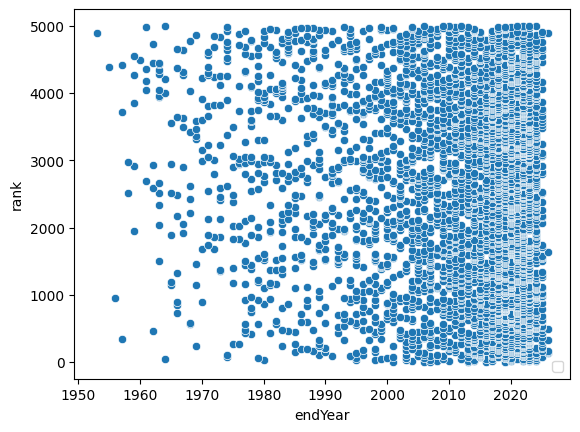

In [ ]:
sns.scatterplot(x="endYear", y="rank", data=df)
plt.legend(loc='lower right')

- Gráfico 2: Relacón de todas las variables numéricas

📌 *Interesante ver como algunos programas de tv fueron muchísimo mas votadas que el resto. También la representación gráfica de la relacion entre startYear y endYear, siendo la representacion de una matriz tirangular positiva (startYear en eje X) o triangular negativa (endYear en eje X)*


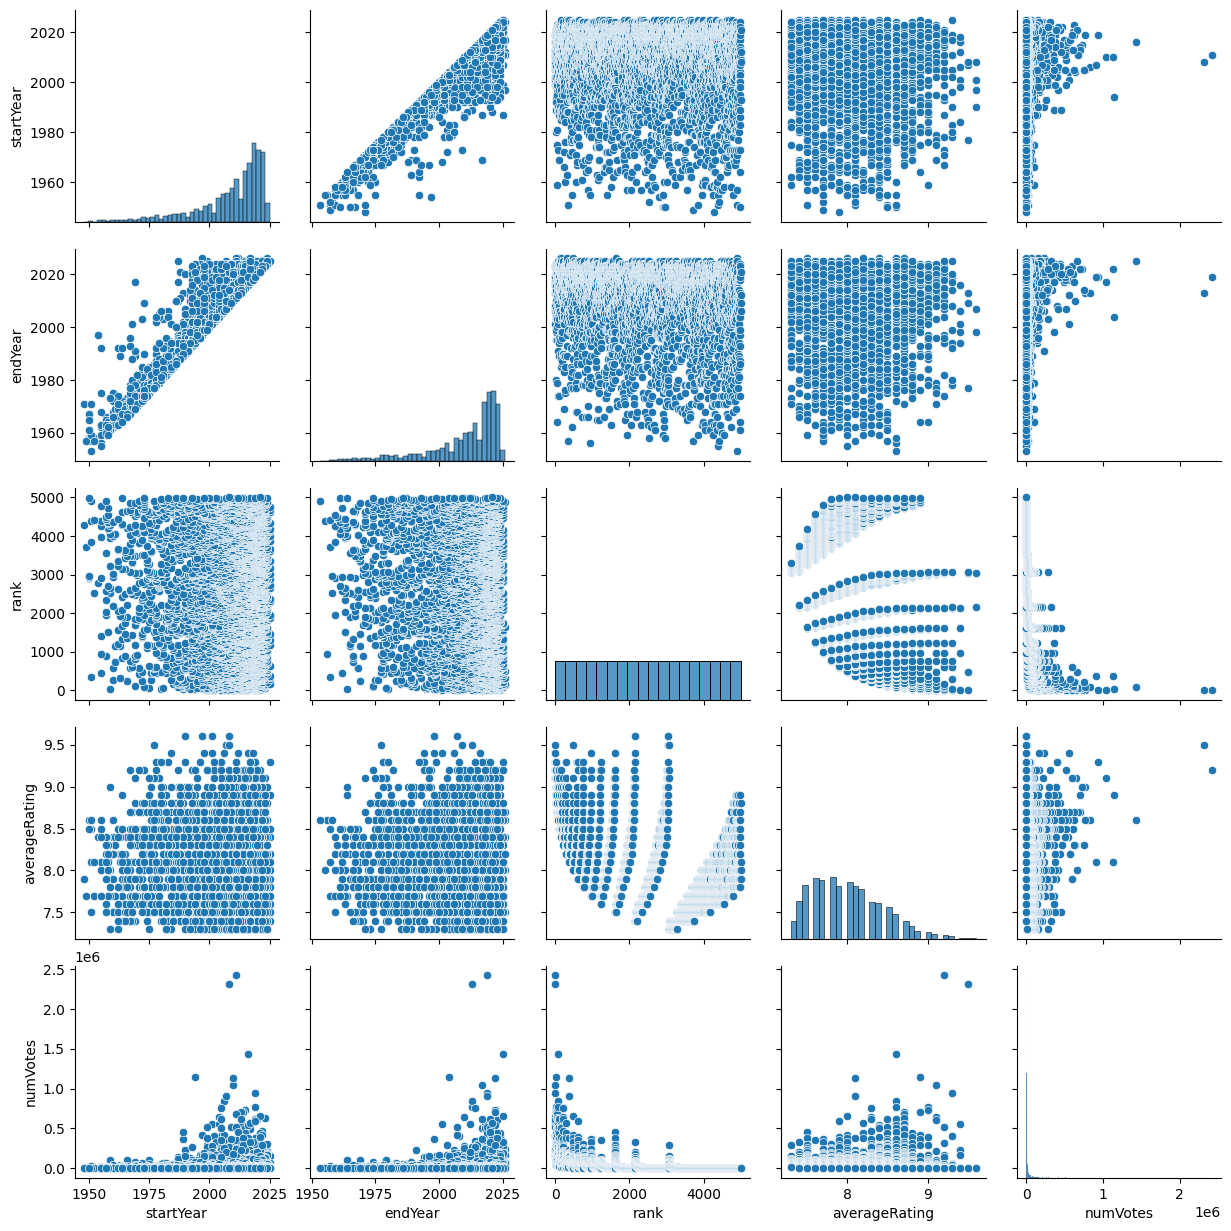

In [ ]:
sns.pairplot(df) #distribucion del cruce de todas las variables

- Gráfico 2: Distribución de programas por año.

📌 *El registro de producciones cinamatográficas tiene un incremento denota una tendencia creciente, con una leve caída en 2021, presumiblemente por el parate en la industria cinematográfica por la pandemia. Además, se observa que aun hay un subregistro de programas de 2024*


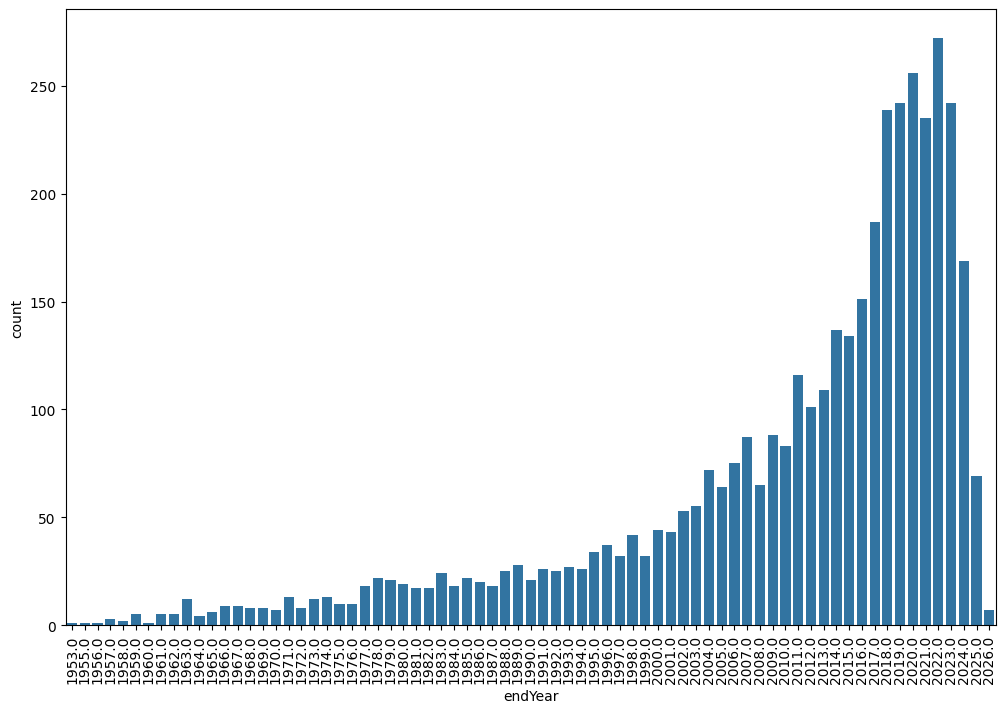

In [ ]:
# conteo de programas por años
plt.figure(figsize=(12, 8))
sns.countplot(x="endYear", data=df)
plt.xticks(rotation=90)
plt.show()

- Gráfico 2: Frecuencia de ratings.

📌 *La moda de rating en programas de tv se encuentra entre 7.5 y 8*

<Axes: xlabel='averageRating', ylabel='Count'>

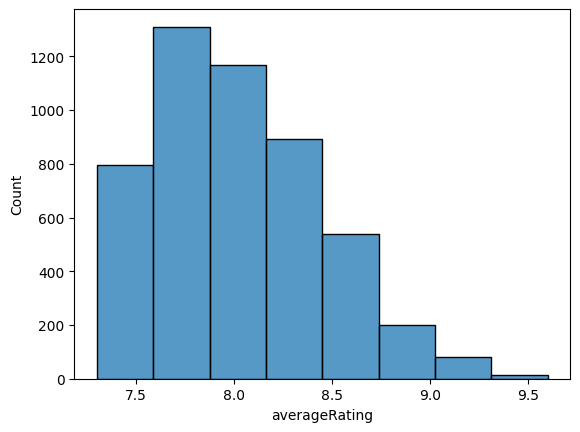

In [ ]:
# distribucion de rating
sns.histplot(x="averageRating", bins = 8, data=df)

In [ ]:
df_num = df.select_dtypes(include=['float', 'int64']) # seleccion solo de datos de tipo numerico para hacer la matriz de correlacion

In [ ]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   startYear      5000 non-null   int64  
 1   endYear        4119 non-null   float64
 2   rank           5000 non-null   int64  
 3   averageRating  5000 non-null   float64
 4   numVotes       5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


- Gráfico 2: Correlacion entre varariables.

📌 *Lógicamente la correlacion entre el año de incio de filmacion y el de finalizacion de la filmación del programa. Tambien hay una correlacion inversa entre la cantidad de votos que recibe un programa y el ranking, suponiendo que la agente acude mucho mas a votar cuando no le gusto el programa.*

<Axes: >

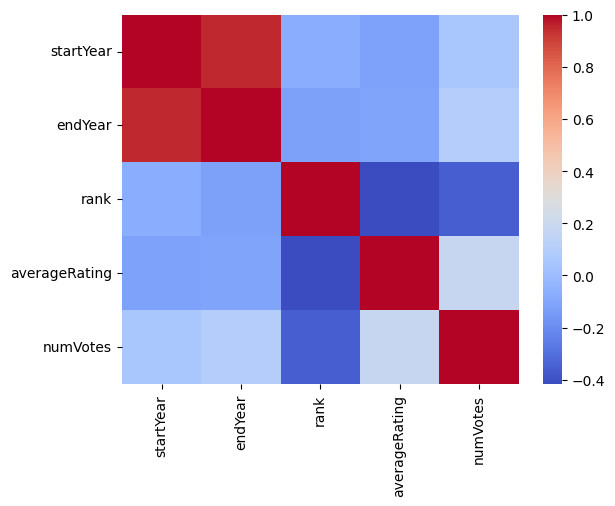

In [ ]:
sns.heatmap(df_num.corr(), cmap='coolwarm') # matriz de relacion entre variables

### 3. Observaciones generales
Luego del la exploración de las variables, se puede afirmar que el dataset esta ordenado y limpio, no fue necesario ningun tipo de data wrangling. Además, no se identifican outliers que presuman mala errores en data entry.
Queda pendiente una exploración por género, que en el dataset está registrado a modo de listado separado por "," y no permite apreciar la distribución de filmografía por género.


---
## ✅ Conclusión del equipo

Después de analizar todos los datasets, el equipo ha decidido continuar el trabajo con el dataset:

### 🏆 Dataset elegido: [muerte causas_2019-2021.csv]

### 📌 Motivos de la elección:
- Es el más completo en cuanto a variables y registros.
- Contiene datos relevantes para analizar patrones de mortalidad por diversas causas a lo largo del tiempo y entre diferentes grupos demográficos y regiones. Las variables relacionadas con la mortalidad total, el COVID-19, la edad y el tiempo (mes y año) son particularmente interesantes para investigar los patrones de mortalidad.
- Se visualiza potencial para aplicar técnicas de IA en próximas etapas (clasificación, predicción, clustering, etc.).
- Ciertos parámetros como en el caso particular de "Date Of Death Month" permite investigar la posible estacionalidad de enfermedades infecciosas (como influenza y COVID-19) y otras causas.

### 📌 Propuestas para las próximas entregas:
- Revisión de los datos, detección de registros duplicados y tratamiento de  casos.
- Realizar con mayor profundidad la visualización de los datos, para cada uno de los parametros que contiene la base de datos.
- Realizar análisis estadísticos, con la finalidad de buscar correlaciones, tendencias y la significancia estadística de las diferencias observadas.

---
## 💡 Tercera Entrega
## 🔍 Introducción
Deben entregar por grupo un solo notebook trabajando sobre el dataset elegido por el equipo "muerte causas_2019-2021.csv". El notebook debe incluir lo siguiente:

1.   Análisis EDA (según lo trabajaron en la entrega 1)
2.   Análisis univariado, bivariado y/o multivariado
3.   Formular 4 hipótesis sobre el dataset
4.   Gráficas orientadas a la respuesta de estas 4 hipótesis
5.   Limpieza del dataset en caso de ser necesaria.

Seguidos por una **conclusión grupal** que justifique la elección de las hipotesis formuladas y con el que se continuará el desarrollo del proyecto.




# Análisis univariado
Empecemos analizando una sola variable a la vez. Para ello, podemos utilizar histogramas o gráficos de cajas y bigotes.

## Histogramas
Los histogramas son una forma de representar la distribución de una variable. Nos permiten ver cómo se distribuyen los datos y si tienen alguna tendencia.

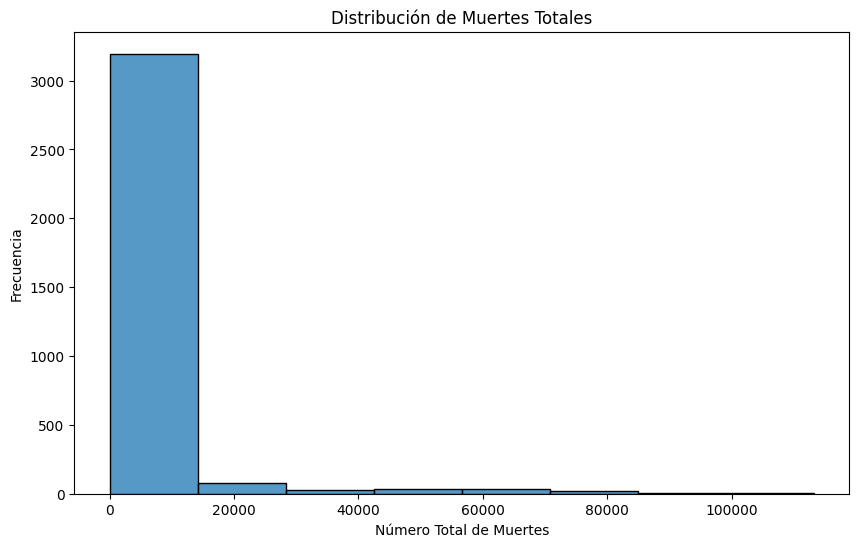

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(x="AllCause", bins=8, data=df)
plt.title("Distribución de Muertes Totales")
plt.xlabel("Número Total de Muertes")
plt.ylabel("Frecuencia")
plt.show()

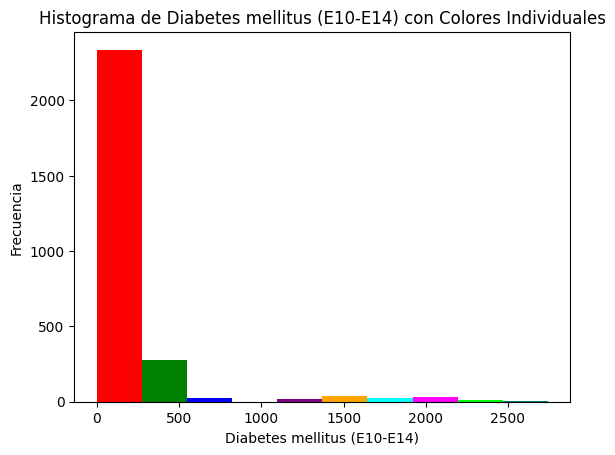

In [ ]:
# Obtener la información del histograma
n, bins, patches = plt.hist(df['Diabetes mellitus (E10-E14)'])
plt.xlabel('Diabetes mellitus (E10-E14)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Diabetes mellitus (E10-E14)')

# Definir una lista de colores para cada barra
colores = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'cyan', 'magenta', 'lime', 'teal']

# Asignar un color diferente a cada barra
for i, patch in enumerate(patches):
    color_index = i % len(colores)  # Ciclar a través de la lista de colores si hay más barras
    patch.set_facecolor(colores[color_index])

plt.show()

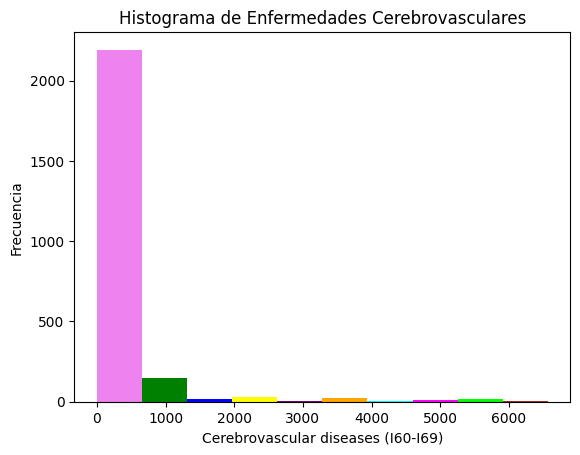

In [ ]:
# Obtener la información del histograma
n, bins, patches = plt.hist(df['Cerebrovascular diseases (I60-I69)'])
plt.xlabel('Cerebrovascular diseases (I60-I69)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Enfermedades Cerebrovasculares')

# Definir una lista de colores para cada barra
colores = ['violet', 'green', 'blue', 'yellow', 'purple', 'orange', 'cyan', 'magenta', 'lime', 'brown']

# Asignar un color diferente a cada barra
for i, patch in enumerate(patches):
    color_index = i % len(colores)  # Ciclar a través de la lista de colores si hay más barras
    patch.set_facecolor(colores[color_index])

plt.show()

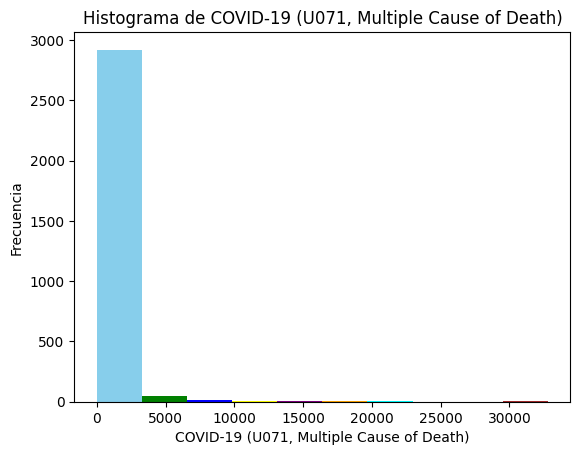

In [ ]:
# Obtener la información del histograma
n, bins, patches = plt.hist(df['COVID-19 (U071, Multiple Cause of Death)'])
plt.xlabel('COVID-19 (U071, Multiple Cause of Death)')
plt.ylabel('Frecuencia')
plt.title('Histograma de COVID-19 (U071, Multiple Cause of Death)')

# Definir una lista de colores para cada barra
colores = ['skyblue', 'green', 'blue', 'yellow', 'purple', 'orange', 'cyan', 'magenta', 'lime', 'brown']

# Asignar un color diferente a cada barra
for i, patch in enumerate(patches):
    color_index = i % len(colores)  # Ciclar a través de la lista de colores si hay más barras
    patch.set_facecolor(colores[color_index])

plt.show()

###3.Hipótesis formuladas


---



3.1   ***El número de muertes por todas las causas aumentó significativamente en 2020 y 2021 respecto a 2019 debido al impacto del COVID-19***

3.2   ***Existe una correlación positiva significativa entre la enfermedad de Alzheimer y otras causas de muerte crónicas***

3.3   ***Existe una correlación positiva significativa entre edad avanzada y Covid-19 Multiples Causas de Muerte***

3.4   ***Las muertes por influenza y neumonía muestran una tendencia similar a las muertes por COVID-19 durante los años de pandemia, lo que sugiere una posible correlación o coexistencia***

3.5   ***Las enfermedades respiratorias deberian ser causa de muerte en los meses de invierno del hemisferio norte***

3.6   ***La enfermedad de alzheimer deberia tener mas incidencia en los adultos mayores en edad jubilatoria***

3.7   ***Correlación entre las muertes por septicemia y enfermedades respiratorias (Aporte adicional para una mejor comprensión de los usuarios finales)***









In [ ]:
from google.colab import files
uploaded = files.upload()

Saving muerte causas_2019-2021.csv to muerte causas_2019-2021.csv


**HIPOTESIS 3.1 El número de muertes por todas las causas aumentó significativamente en 2020 y 2021 respecto a 2019 debido al impacto del COVID-19**

<ipython-input-9-51e6a15b8db9>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Date Of Death Year', y='AllCause', data=df_boxplot, palette="Set2")


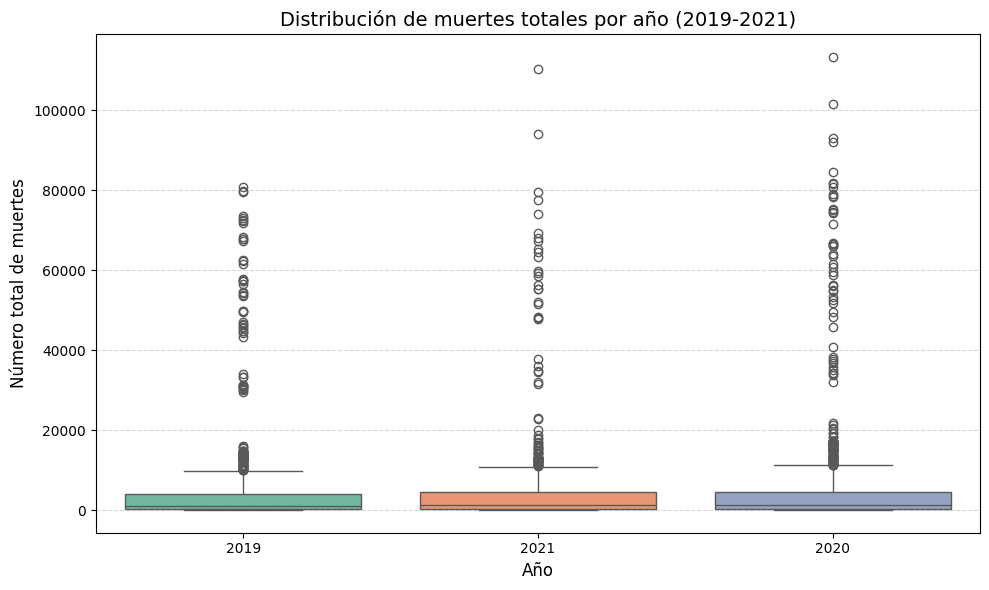

In [ ]:
# 3.1 HIPOTESIS "El número de muertes por todas las causas aumentó significativamente en 2020 y 2021 respecto a 2019 debido al impacto del COVID-19"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('muerte causas_2019-2021.csv')

# Asegurarse de que no haya valores NaN en las columnas necesarias
df_boxplot = df[['Date Of Death Year', 'AllCause']].dropna()

# Evitar problemas de tipo categórico
df_boxplot['Date Of Death Year'] = df_boxplot['Date Of Death Year'].astype(str)

# Gráfico boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Date Of Death Year', y='AllCause', data=df_boxplot, palette="Set2")
plt.title("Distribución de muertes totales por año (2019-2021)", fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Número total de muertes", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Gráfico** 1: [Hipótesis 3.1]
📌 Interpretación: Este gráfico muestra cómo se distribuyen los valores de muertes totales (AllCause) en cada año. Se espera observar un aumento en los valores centrales (mediana) y en la dispersión para los años 2020 y 2021 respecto a 2019, lo cual respaldaría la hipótesis del impacto del COVID-19.

**Conclusion**: [Hipótesis 3.1]
El análisis mediante el gráfico boxplot revela un aumento evidente en la mediana y en la dispersión del número total de muertes para los años 2020 y 2021 en comparación con 2019. Este incremento sugiere un impacto significativo del COVID-19 en la mortalidad general durante esos años, respaldando así la hipótesis planteada. La concentración más alta de valores y la ampliación del rango intercuartílico indican no solo un mayor número de muertes, sino también una mayor variabilidad, posiblemente asociada a los distintos momentos de la pandemia y sus efectos en la población. Por lo tanto, los datos visualizados refuerzan la idea de que la crisis sanitaria tuvo un efecto sustancial sobre la mortalidad total en el período analizado.

**HIPOTESIS 3.2 Existe una correlación positiva significativa entre la enfermedad de Alzheimer y otras causas de muerte crónicas**


Todas las columnas de interés para Alzheimer se encontraron en el DataFrame.
Convertir todas las columnas a numérico, manejando posibles errores con 'coerce
Se eliminaron 1778 filas debido a valores NaN.


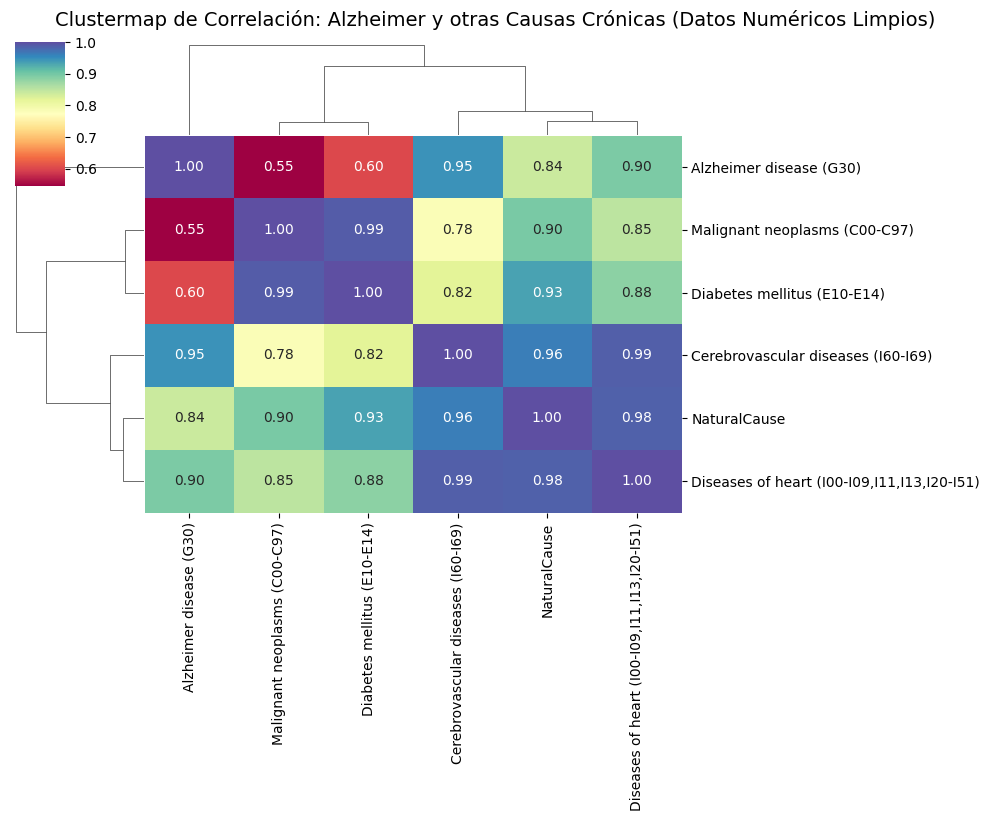

In [ ]:
# 3.2 HIPOTESIS "Existe una correlación positiva significativa entre la enfermedad de Alzheimer y otras causas de muerte crónicas"
columnas_interes_alzheimer = [
    'Alzheimer disease (G30)',
    'NaturalCause',
    'Malignant neoplasms (C00-C97)',
    'Diabetes mellitus (E10-E14)',
    'Diseases of heart (I00-I09,I11,I13,I20-I51)',
    'Cerebrovascular diseases (I60-I69)'
]

# Verifica si todas las columnas de interés existen en el DataFrame
missing_columns_alzheimer = [col for col in columnas_interes_alzheimer if col not in df.columns]
if missing_columns_alzheimer:
    print(f"\nERROR: Las siguientes columnas no se encontraron en el DataFrame: {missing_columns_alzheimer}")
    print("Verificá los nombres exactos de las columnas en el archivo CSV.")
    print("Columnas disponibles en el DataFrame:", df.columns.tolist())
    sys.exit("Terminando ejecución debido a columnas faltantes.")
else: # se ejecutará SOLO SI NO FALTAN COLUMNAS.
    print("\nTodas las columnas de interés para Alzheimer se encontraron en el DataFrame.")

    # 2. Seleccionar solo las columnas de interés del DataFrame

    # ¡OBSERVACION! Usamos .copy() para asegurar que estamos trabajando en una copia independiente
    # y evitar el "SettingWithCopyWarning". (usando una copia de la base de datos original )

    df_subset_alzheimer = df[columnas_interes_alzheimer].copy()

    # --- Convertir todas las columnas a numérico, manejando posibles errores con 'coerce' ---
    # Esto es el método principal de limpieza para datos , los cuales deben ser numéricos.
    print("Convertir todas las columnas a numérico, manejando posibles errores con 'coerce")
    for col in df_subset_alzheimer.columns:
        df_subset_alzheimer[col] = pd.to_numeric(df_subset_alzheimer[col], errors='coerce')


    # Eliminar filas con NaN que puedan haber surgido por la conversión y/o por datos faltantes originales.
    # NOTA: La correlación no puede calcularse con valores NaN.
    initial_rows = len(df_subset_alzheimer)
    df_subset_alzheimer = df_subset_alzheimer.dropna()
    rows_after_dropna = len(df_subset_alzheimer)
    if initial_rows > rows_after_dropna:
        print(f"Se eliminaron {initial_rows - rows_after_dropna} filas debido a valores NaN.")


    if df_subset_alzheimer.empty:
        print("\nADVERTENCIA: El subconjunto de datos  está vacío después de limpiar NaN. No se puede continuar.")
    else:
        # 3. Calcula la matriz de correlación

        correlation_matrix_alzheimer = df_subset_alzheimer.corr()

        # 4. Empleando el CLUSTERMAP puntualizando en la enfermedad de Alzheimer

        g = sns.clustermap(
            correlation_matrix_alzheimer,
            cmap='Spectral',
            annot=True,
            fmt=".2f",
            figsize=(10, 8)
        )
        g.fig.suptitle("Clustermap de Correlación: Alzheimer y otras Causas Crónicas (Datos Numéricos Limpios)", y=1.02, fontsize=14)
        plt.show()


**Gráfico** 2: [Interpretación]
📌 "Clustermap de Correlación: Comorbilidad entre Alzheimer y Principales Causas de Muerte Crónicas"  La correlación nos demuestra que, si bien el Alzheimer rara vez es la causa directa y única de la muerte, su progresión neurodegenerativa aumenta la vulnerabilidad de los pacientes a desarrollar complicaciones y agravar otras enfermedades crónicas preexistentes. Las cuales, en última instancia, son las verdaderas causales de la muerte.

##📌 Justificación de la hipótesis 3.2

"La hipotesís muestra consistentemente una correlación positiva significativa entre la enfermedad de Alzheimer y otras causas de muerte crónicas seleccionadas. Específicamente, se observa una correlación fuerte con las enfermedades cerebrovasculares (0.95), las enfermedades cardíacas (0.90), y las causas naturales (0.84). Además, existe una correlación positiva moderada con la diabetes mellitus (0.60) y las neoplasias malignas (0.55). El agrupamiento que se observa en el clustermap refuerza estas relaciones, mostrando que la enfermedad de Alzheimer tiende a agruparse con las condiciones crónicas. Podemos inferir que estas patologías pueden coexistir frecuentemente en los pacientes, contribuyendo a su deceso y destacando la complejidad de las comorbilidades en la mortalidad. Estos hallazgos apoyan la hipótesis de que el Alzheimer se relaciona significativamente con otras causas de muerte crónicas."


**HIPOTESIS 3.3 Existe una correlación positiva significativa entre edad avanzada y Covid-19 Multiples Causas de Muerte**

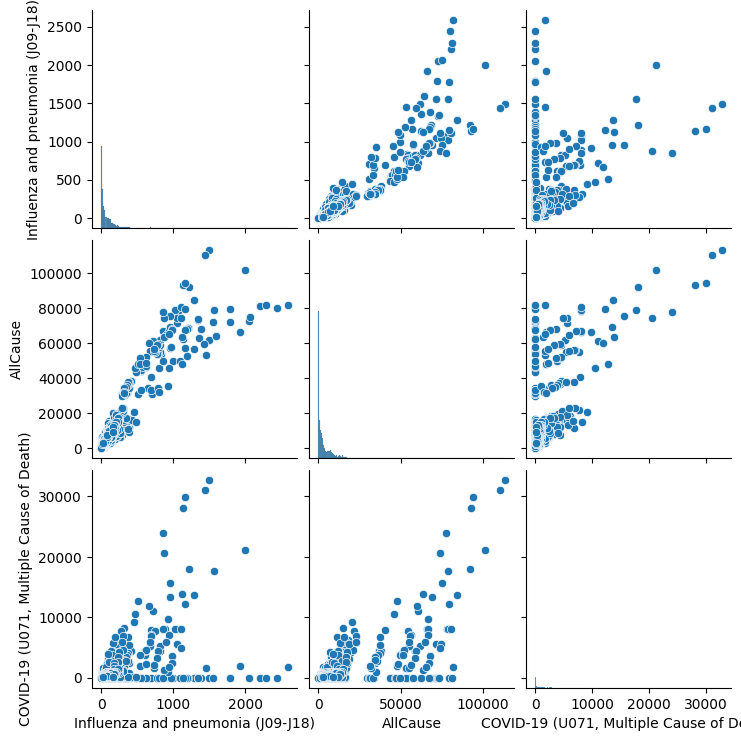

In [ ]:
# Seleccionar las columnas que te interesan
columnas_interes = ['Influenza and pneumonia (J09-J18)' ,'AllCause','COVID-19 (U071, Multiple Cause of Death)' ]


# Generar el pairplot solo para las columnas seleccionadas
sns.pairplot(df[columnas_interes])
plt.show()


**Gráfico** 3: [Relación entre Influenza and pneumonia (J09-J18)' ,'AllCause','COVID-19 (U071, Multiple Cause of Death) ]
📌 Interpretación: El grafico pairplot de diferentes causas de muerte y muertes totales explora visualmente las distribuciones individuales de cada causa, así como las relaciones bivariadas entre ellas. Puede ayudar a identificar posibles correlaciones, causas de muerte dominantes y generar hipótesis para un análisis más profundo de los patrones de mortalidad.

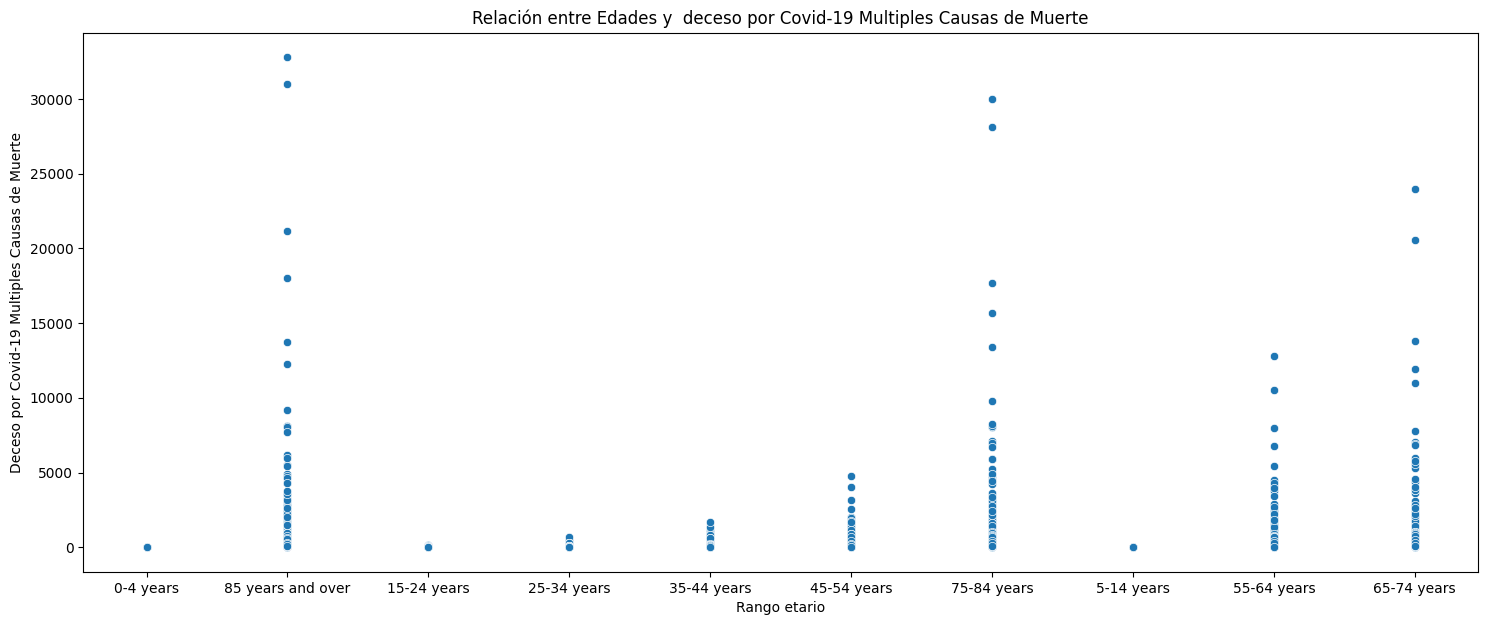

In [ ]:
# Diagrama de dispersión
# Gráfica la relación entre la edad y deceso por muerte Covid-19 Multiples Causas de Muerte
plt.figure(figsize=(18, 7))

sns.scatterplot(data=df, x="AgeGroup", y="COVID-19 (U071, Multiple Cause of Death)")
plt.title("Relación entre Edades y  deceso por Covid-19 Multiples Causas de Muerte")
plt.xlabel("Rango etario")
plt.ylabel("Deceso por Covid-19 Multiples Causas de Muerte")
plt.show()

**Gráfico** 4: [Relación entre edades y Covid-19 Multiples Causas de Muerte]
📌 Interpretación: El diagrama de dispersión de la relación entre edad y decesos por muerte natural, es una herramienta valiosa para visualizar y comprender cómo la probabilidad de muerte natural aumenta con la edad, tambien nos muestra la tendencia de dicha relación y su variabilidad dentro de los diferentes grupos de edad.

##📌 Análisis Hipótesis 3.3
Análisis Hipotesis 3.3 Existe una correlación positiva significativa entre edad avanzada y Covid-19 Multiples Causas de Muerte
Durante el año 2021, la pandemia de COVID-19 continuó teniendo un impacto significativo en la salud pública a nivel mundial. Este informe analiza los datos de mortalidad del año 2021, con especial énfasis en las muertes asociadas al COVID-19 y su correlación con la edad avanzada de los individuos fallecidos.
Luego del análisis del gráfico de dispersión por grupos etarios revela una clara tendencia ascendente en la mortalidad por COVID-19 conforme aumenta la edad
Muestran que la edad avanzada es un factor de riesgo determinante en la letalidad del COVID-19.
Considerando las multiples causas asociado a un sistema inmunológico debilitado con la edad y una mayor vulnerabilidad en residencias de larga estancia y menor capacidad de respuesta médica, consistente con la prevalencia de enfermedades como diabetes, hipertención, entre otras.
Conclusión: El covid afectó en forma desproporcionada a personas mayores. Razon por la cual se aplicaron diferentes acciones de cuidado a esta población.


**HIPOTESIS 3.4 Las muertes por influenza y neumonía muestran una tendencia similar a las muertes por COVID-19 durante los años de pandemia, lo que sugiere una posible correlación o coexistencia**

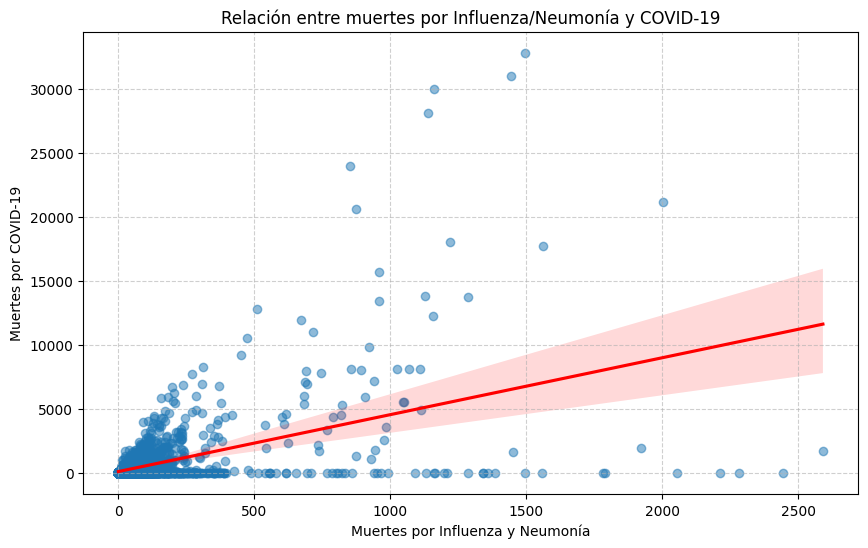

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Influenza and pneumonia (J09-J18)',
            y='COVID-19 (U071, Multiple Cause of Death)',
            data=df,
            scatter_kws={'alpha':0.5},
            line_kws={"color": "red"})
plt.title("Relación entre muertes por Influenza/Neumonía y COVID-19")
plt.xlabel("Muertes por Influenza y Neumonía")
plt.ylabel("Muertes por COVID-19")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Gráfico** 5: [Hipótesis 3.4]
📌 Interpretación: Una correlación positiva indicaría que en registros donde hubo muchas muertes por influenza y neumonía, también hubo muchas muertes por COVID-19, lo cual podría reflejar co-ocurrencia de enfermedades respiratorias, errores de clasificación o presión hospitalaria.

**Conclusión**: [Hipótesis 3.4]
El gráfico de dispersión con regresión lineal muestra una correlación positiva moderada entre las muertes por influenza y neumonía y las muertes por COVID-19. Esta relación sugiere que en los registros con mayor mortalidad por enfermedades respiratorias tradicionales también se registraron más muertes por COVID-19. Esto podría deberse a una coexistencia de patologías respiratorias, errores en la clasificación de causas de muerte, o bien a una sobrecarga del sistema de salud durante los picos de la pandemia. Si bien esta visualización no permite establecer causalidad, sí respalda parcialmente la hipótesis al evidenciar un patrón conjunto entre ambas variables durante el período pandémico.

**HISTOGRAMA**

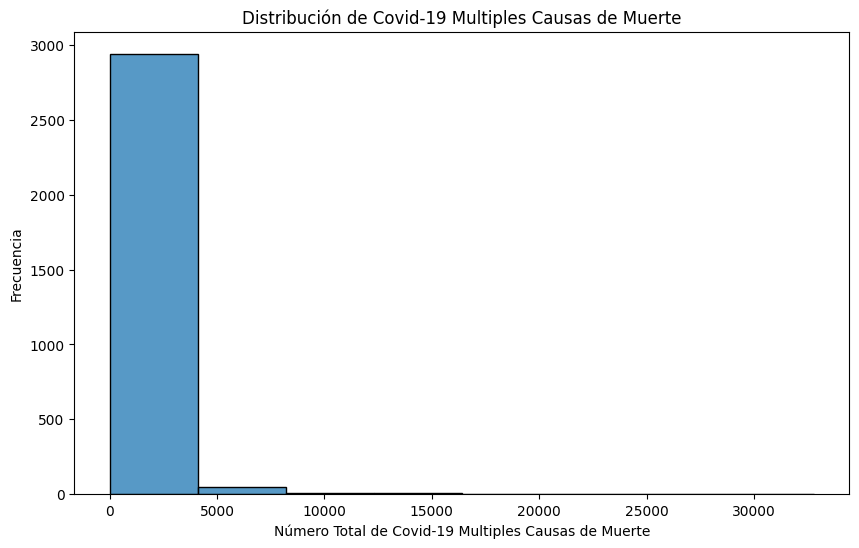

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(x="COVID-19 (U071, Multiple Cause of Death)", bins=8, data=df)
plt.title("Distribución de Covid-19 Multiples Causas de Muerte")
plt.xlabel("Número Total de Covid-19 Multiples Causas de Muerte")
plt.ylabel("Frecuencia")
plt.show()

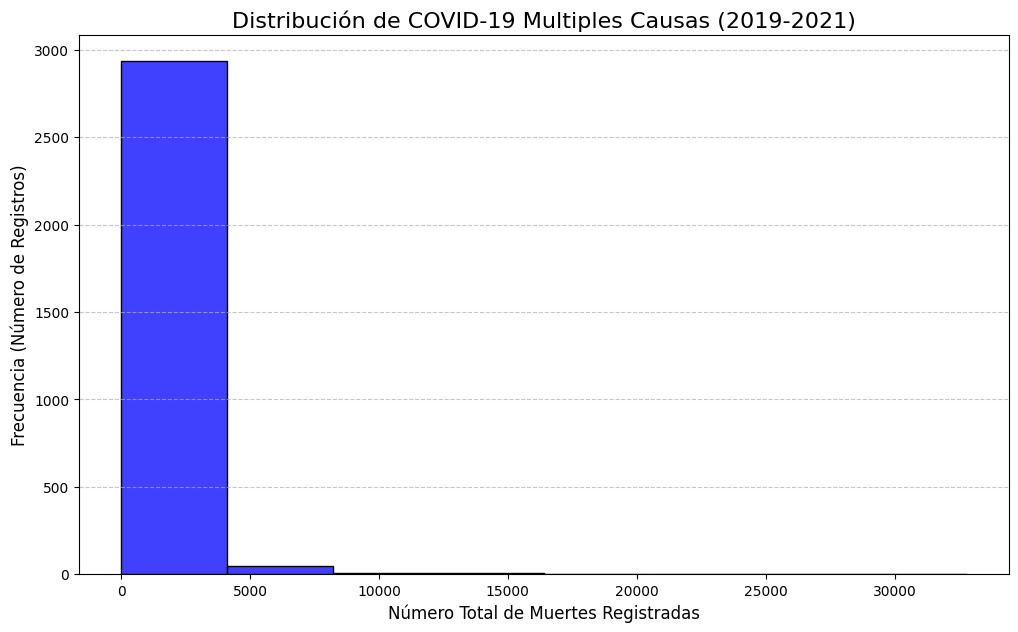

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(x="COVID-19 (U071, Multiple Cause of Death)", bins=8, data=df, color='blue', edgecolor='black')

# título y las etiquetas de los ejes
plt.title("Distribución de COVID-19 Multiples Causas (2019-2021)", fontsize=16)
plt.xlabel("Número Total de Muertes Registradas", fontsize=12)
plt.ylabel("Frecuencia (Número de Registros)", fontsize=12)


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

**Gráfico** 6: [Distribución de muertes totales]
📌 Interpretación: Este histograma sugiere que en la mayoría de los casos observados, el número total de muertes se mantuvo relativamente bajo (entre 0 y 10000).

**HIPOTESIS 3.5 Las enfermedades respiratorias deberian ser causa de muerte con mayor preponderancia en los meses de invierno del hemisferio norte**


In [ ]:
mapeo_edades = {
    '0–4 years': '0-4 años',
    '5-14 years': '5-14 años',
    '15-24 years': '15-24 años',
    '25-34 years': '25-34 años',
    '35-44 years': '35-44 años',
    '45-54 years': '45-54 años',
    '55-64 years': '55-64 años',
    '65-74 years': '65-74 años',
    '75-84 years': '75-84 años',
    '85 years and over': '85 años y más'
}


df = (
    df.assign(
    AnalysisDate=lambda df: pd.to_datetime(df["AnalysisDate"]),
        AgeGroup=lambda df: df['AgeGroup'].replace(mapeo_edades)
    )
)

Text(0.5, 0, 'Mes')

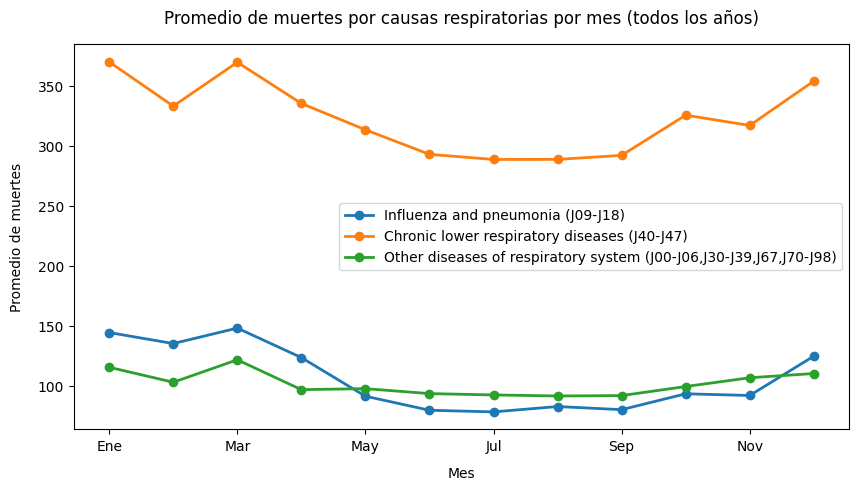

In [ ]:

# Combinacion de año y mes en un solo datetime
df['year_month'] = pd.to_datetime(df['Date Of Death Year'].astype(str)
                                  + '-'
                                  + df['Date Of Death Month'].astype(str).str.zfill(2))
df = df.set_index('year_month') # lo pongo como indice

# Columnas relacionadas a muertes respiratorias
col_respiratorias = [
    'Influenza and pneumonia (J09-J18)',
    'Chronic lower respiratory diseases (J40-J47)',
    'Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)'
]
resp = df[col_respiratorias]



# Agrupado por mes del calentario
monthly_avg = resp.groupby(resp.index.month).mean()
monthly_avg.index = [
    'Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'
]

# Promedio de muertes por mes
fig, ax = plt.subplots(figsize=(10, 5))

monthly_avg.plot(
    ax=ax,
    marker='o',
    linewidth=2
)

# 6. Tidy up axes
ax.set_title('Promedio de muertes por causas respiratorias por mes (todos los años)', pad=15)
ax.set_ylabel('Promedio de muertes', labelpad=10)
ax.set_xlabel('Mes', labelpad=10)


**HIPOTESIS 3.5**
Las enfermedades respiratorias inciden en la causa de muerte en los meses de invierno en mayor porcentaje

📌 Interpretación: Las enfermedades respiratorias tienen un pico en los meses de invierno debido a la facilidad conocida de los virus respiratorios de proliferar en dichas circunstancias. Si bien se puede identificar descenso llamativo en el mes de febrero, que pudo haberse probocado por un factor externo a la temática, la tendencia se identifica con claridad en ascenso en los meses de mayor frio del hemisferio norte.

**HIPOTESIS 3.6**
La enfermedad de alzheimer deberia tiene más incidencia en los adultos mayores en edad jubilatoria.

📌 Interpretación: Efectivamente la enferdad de alzheimer como causa de muerte tiene una marcada incidencia en las personas mayores de 65 años. Se identifica, gracias a los boxplot, como la cantidad de casos, la media y los altos nros de otuliers marcan una tendencia creciente a medida que la edad de los pacientes avanza, pegando un salto en el ultimo rango etáreo de

# Hipótesis 3.7 Correlación entre las muertes por septicemia y enfermedades respiratorias

correlación entre las muertes por septicemia y enfermedades respiratorias

La septicemia es una de las 10 principales causas de muertes por enfermedad en los Estados Unidos. La afección puede surgir de repente y progresar rápidamente, y con frecuencia es difícil de reconocer. Cualquier persona puede sufrir una septicemia, pero los adultos mayores son los más vulnerables. Diversos tipos de infecciones pueden provocar septicemia. "Sin embargo, la causa más común de la septicemia es la neumonía adquirida en la comunidad"

<Figure size 1200x600 with 0 Axes>

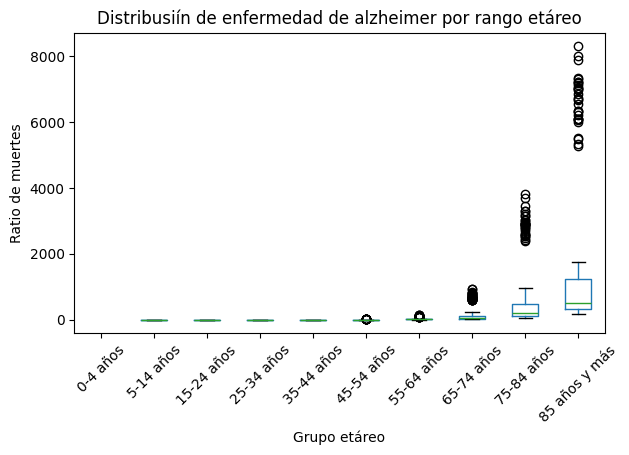

In [ ]:
# ordenado de grupos etareos
age_order = [
    '0-4 años',
    '5-14 años',
    '15-24 años',
    '25-34 años',
    '35-44 años',
    '45-54 años',
    '55-64 años',
    '65-74 años',
    '75-84 años',
    '85 años y más'
]

df['AgeGroup_cat'] = pd.Categorical(df['AgeGroup'], categories=age_order, ordered=True) # convierto la variable a categorica

# Boxplot
plt.figure(figsize=(12, 6))
df.boxplot(
    column='Alzheimer disease (G30)',
    by='AgeGroup_cat',
    grid=False
)
plt.title("Distribusiín de enfermedad de alzheimer por rango etáreo")
plt.suptitle("")            # saco el subtitulo titulo innecesario
plt.xlabel("Grupo etáreo")
plt.ylabel("Ratio de muertes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
data_path = '//content/drive/MyDrive/DS/muerte causas_2019-2021.csv'
df = pd.read_csv(data_path, sep=',')

In [ ]:
# columnas de interes = ['Influenza and pneumonia (J09-J18)' ,'Septicemia (A40-A41)' ]
import plotly.express as px
fig = px.scatter(df, x="Influenza and pneumonia (J09-J18)", y="Septicemia (A40-A41)", color="AgeGroup", title=f"Correlacion entre Septicemia y Enfermedades respiratorias")
fig.show()


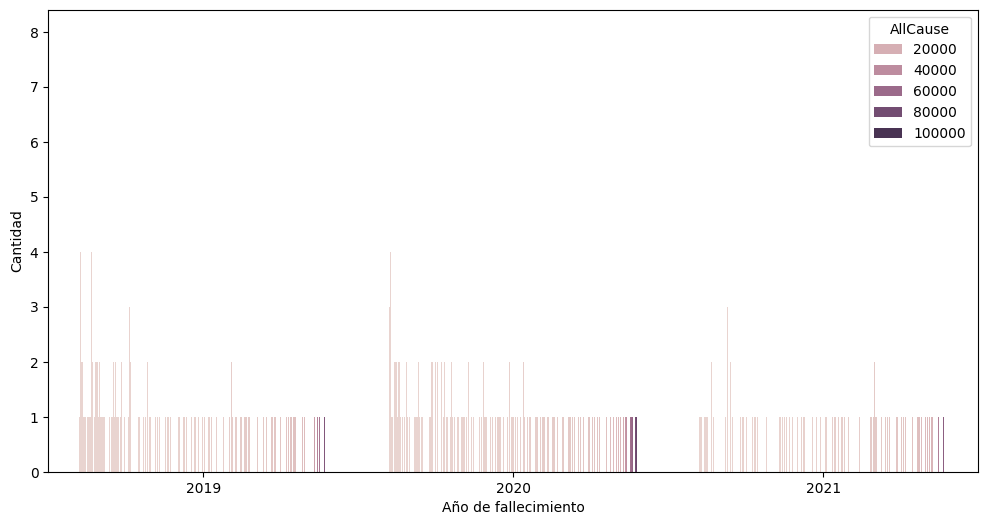

In [ ]:
# @title Gráfico de barras para visualizar la distribución de las causas de muerte por año
plt.figure(figsize=(12, 6))
sns.countplot(x='Date Of Death Year', hue='AllCause', data=df)
plt.xlabel('Año de fallecimiento')
plt.ylabel('Cantidad')
plt.show()

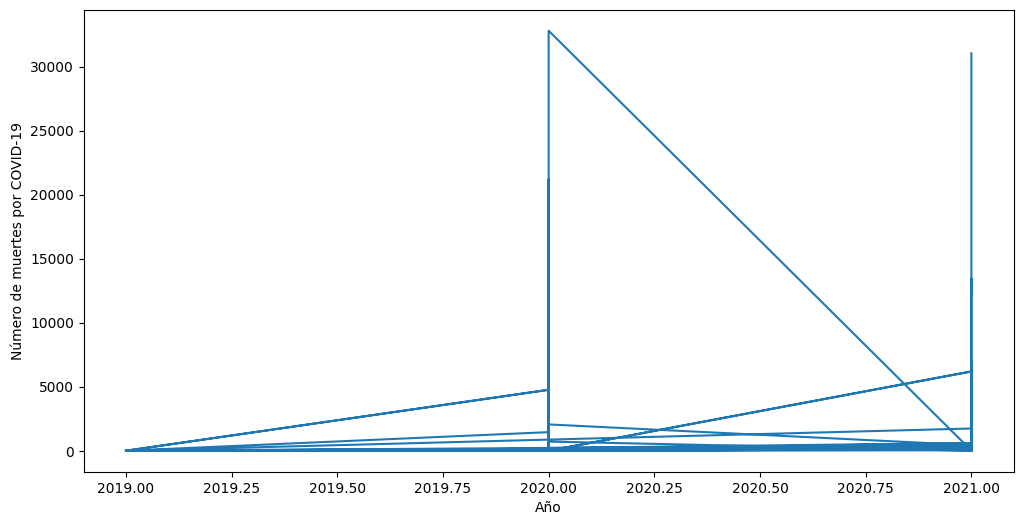

In [ ]:
# @title Gráfico de línea para visualizar la tendencia de las causas de muerte a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(df['Date Of Death Year'], df['COVID-19 (U071, Multiple Cause of Death)'])
plt.xlabel('Año')
plt.ylabel('Número de muertes por COVID-19')
plt.show()

In [ ]:
# @title Mapa de Calor
df_Num = df.select_dtypes(include=['float', 'int64'])

In [ ]:
df_Num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 17 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   Date Of Death Year                                                                                 3410 non-null   int64  
 1   Date Of Death Month                                                                                3410 non-null   int64  
 2   AllCause                                                                                           3400 non-null   float64
 3   NaturalCause                                                                                       3342 non-null   float64
 4   Septicemia (A40-A41)                                                                               2340 non-null   float

In [ ]:
# Matriz de correlación
corr_matriz = df_Num.corr()

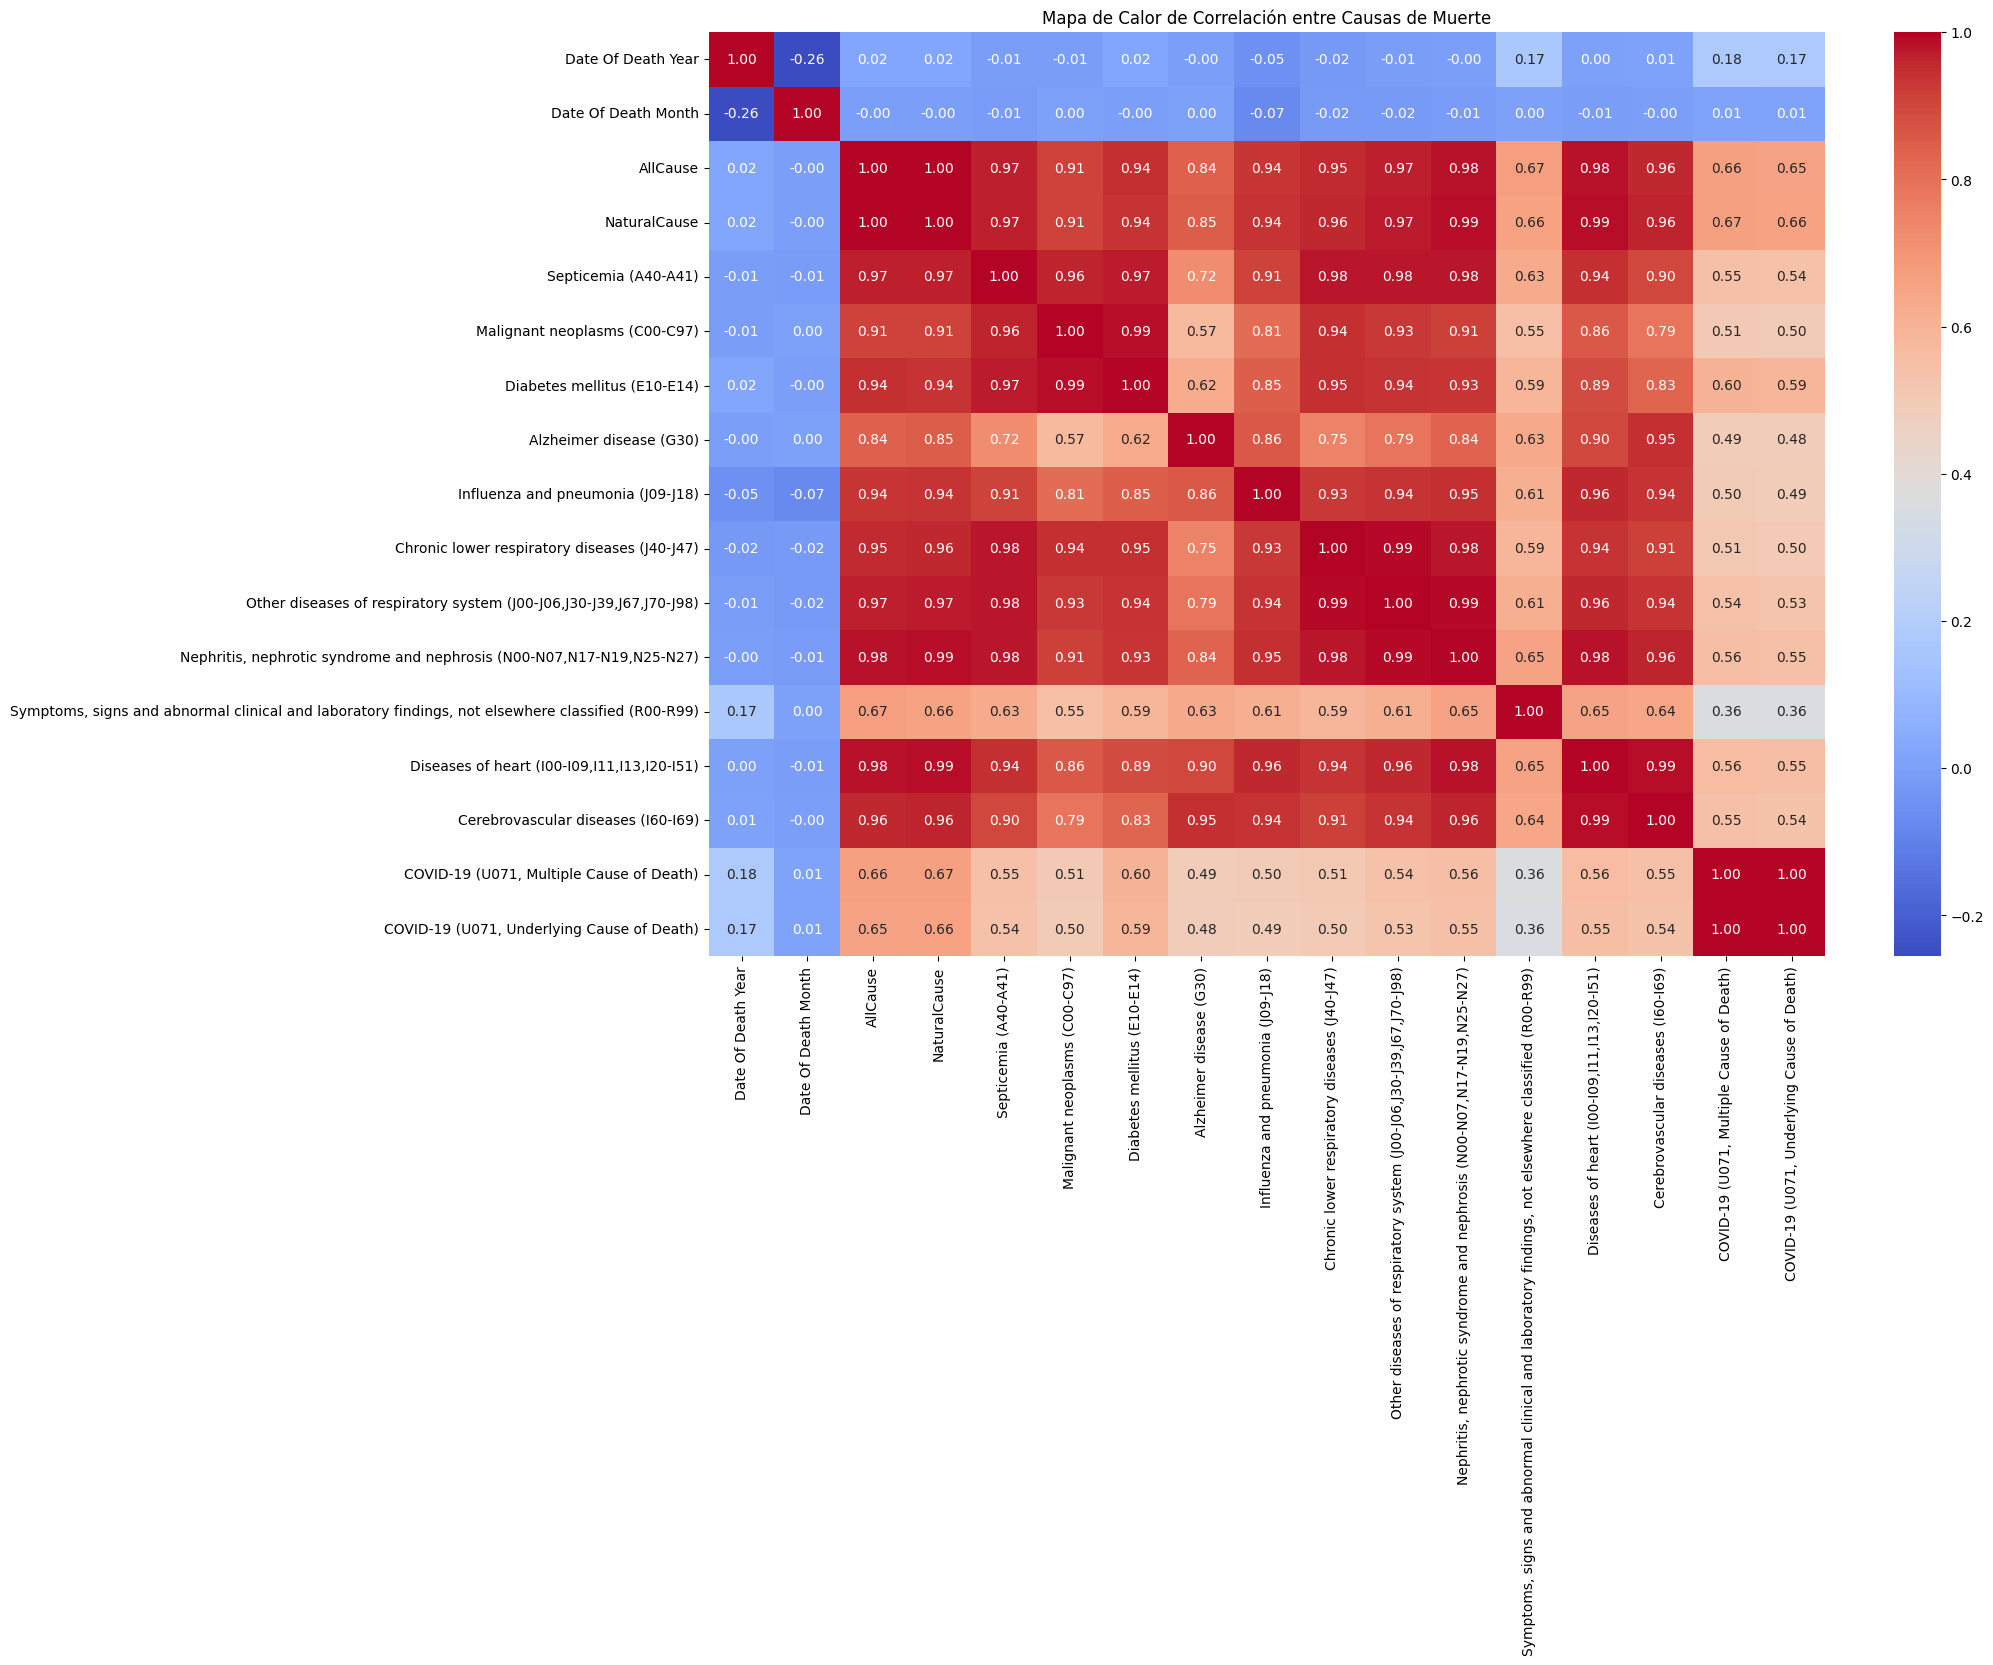

In [ ]:
# Generar el mapa de calor
plt.figure(figsize=(18, 12))
sns.heatmap(corr_matriz, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Mapa de Calor de Correlación entre Causas de Muerte")
plt.show()

# Aporte adicional para una mejor comprensión de los usuarios finales

# Grafico de Dispersión, Línea o Barras de acuerdo a la seleccion del usuario

In [ ]:
df_new = df.drop(['AnalysisDate','Note','flag_allcause','flag_natcause','flag_sept','flag_neopl','flag_diab','flag_alz','flag_inflpn','flag_clrd','flag_otherresp','flag_nephr','flag_otherunk','flag_hd','flag_stroke','flag_cov19mcod','flag_cov19ucod'], axis=1)

In [ ]:
# Identificar columnas numéricas y categóricas
col_num = df.select_dtypes(include='number').columns.tolist()
col_cat = df.select_dtypes(exclude='number').columns.tolist()

In [ ]:
# @title Seleccion de opciones para analizar
eje_x = "Influenza and pneumonia (J09-J18)" # @param ["Date Of Death Year","AgeGroup","AllCause","NaturalCause","Septicemia (A40-A41)","Malignant neoplasms (C00-C97)","Diabetes mellitus (E10-E14)","Alzheimer disease (G30)","Influenza and pneumonia (J09-J18)","Chronic lower respiratory diseases (J40-J47)","Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)","Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)","Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)","Diseases of heart (I00-I09,I11,I13,I20-I51)","Cerebrovascular diseases (I60-I69)","COVID-19 (U071, Multiple Cause of Death)","COVID-19 (U071, Underlying Cause of Death)"]
eje_y = "Septicemia (A40-A41)" # @param ["Date Of Death Year","AgeGroup","AllCause","NaturalCause","Septicemia (A40-A41)","Malignant neoplasms (C00-C97)","Diabetes mellitus (E10-E14)","Alzheimer disease (G30)","Influenza and pneumonia (J09-J18)","Chronic lower respiratory diseases (J40-J47)","Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)","Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)","Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)","Diseases of heart (I00-I09,I11,I13,I20-I51)","Cerebrovascular diseases (I60-I69)","COVID-19 (U071, Multiple Cause of Death)","COVID-19 (U071, Underlying Cause of Death)"]

In [ ]:
# @title Tipo de grafico y agrupacion
col_color = "AgeGroup" # @param ["Ninguna","HHSRegion","AgeGroup"]
tipo = "Línea" # @param ["Dispersión","Línea","Barras"]

In [ ]:
if not df_new.empty:
    color_arg = None if col_color == "Ninguna" else col_color

    if tipo == "Dispersión":
          fig = px.scatter(df_new, x=eje_x, y=eje_y, color=color_arg, title=f"{eje_y} vs {eje_x}")
    elif tipo == "Línea":
        fig = px.line(df_new, x=eje_x, y=eje_y, color=color_arg, title=f"{eje_y} vs {eje_x}")
    elif tipo == "Barras":
          fig = px.bar(df_new, x=eje_x, y=eje_y, color=color_arg, title=f"{eje_y} vs {eje_x}")

    fig.show()
else:
    print("⚠️ No hay datos que coincidan con los filtros seleccionados.")

---
## 💡 Entrega final
## 🔍 Introducción
Deben entregar por grupo un solo notebook trabajando sobre el dataset elegido por el equipo. El notebook debe incluir lo siguiente:



*   Aplicación de modelos de Regresión,
*   Clasificación o Agrupación según lo planteado en el objetivo. (mínimo 3 modelos)
*   Métricas de evaluación del modelo aplicado
*   Selección del modelo más indicado en base a las métricas.







# 1.Modelos de Regresión

## Regresión Lineal:
La regresión lineal es un algoritmo de aprendizaje supervisado que se utiliza para modelar la relación entre una variable dependiente (objetivo) y una o más variables independientes (características). El objetivo es encontrar una línea recta que mejor se ajuste a los datos para predecir los valores de la variable dependiente.

### Paso 1: Importar las bibliotecas necesarias y cargar el conjunto de datos

### Variables incluidas:

In [ ]:
df.head()

,Date Of Death Year,Date Of Death Month,HHSRegion,AgeGroup,AllCause,NaturalCause,Septicemia (A40-A41),Malignant neoplasms (C00-C97),Diabetes mellitus (E10-E14),Alzheimer disease (G30),...,flag_alz,flag_inflpn,flag_clrd,flag_otherresp,flag_nephr,flag_otherunk,flag_hd,flag_stroke,flag_cov19mcod,flag_cov19ucod
0,2019,1,United States,0-4 years,2022.0,1764.0,17.0,23.0,NaN,0.0,...,NaN,NaN,Suppressed (counts 1-9),NaN,Suppressed (counts 1-9),NaN,NaN,Suppressed (counts 1-9),NaN,NaN
1,2021,5,7,85 years and over,3373.0,3241.0,31.0,397.0,64.0,228.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,1,United States,15-24 years,2340.0,626.0,NaN,123.0,31.0,0.0,...,NaN,NaN,NaN,NaN,Suppressed (counts 1-9),NaN,NaN,NaN,NaN,NaN
3,2019,1,United States,25-34 years,4616.0,1623.0,31.0,268.0,82.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,1,United States,35-44 years,7023.0,4153.0,80.0,955.0,224.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Obtener los datos y las etiquetas
X = df.drop('AllCause', axis=1)  # Características
y = df['Septicemia (A40-A41)']  # Etiquetas

### Paso 2: Dividir el conjunto de datos en conjuntos de entrenamiento y prueba. (Split)

Donde las X: representan a las variables predictoras (features) y las y: representa a la variable objetivo (target)

Del total de los datos , el 80% se utiliza para el entrenamiento y el 20% de los datos se reservan para las pruebas o los test.

### Paso 3: Crear y ajustar el modelo de regresión lineal. (Train)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2319643e-25a8-4d42-a202-f6094690deca' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

**ANÁLISIS de REGRESIÓN LINEAL**
**Según hipótesis 3.1**






Saving muerte causas_2019-2021.csv to muerte causas_2019-2021 (5).csv
📄 Archivo subido: muerte causas_2019-2021 (5).csv
✅ DataFrame cargado correctamente:
   Date Of Death Year  Date Of Death Month      HHSRegion           AgeGroup  \
0                2019                    1  United States          0-4 years   
1                2021                    5              7  85 years and over   
2                2019                    1  United States        15-24 years   
3                2019                    1  United States        25-34 years   
4                2019                    1  United States        35-44 years   

   AllCause  NaturalCause  Septicemia (A40-A41)  \
0    2022.0        1764.0                  17.0   
1    3373.0        3241.0                  31.0   
2    2340.0         626.0                   NaN   
3    4616.0        1623.0                  31.0   
4    7023.0        4153.0                  80.0   

   Malignant neoplasms (C00-C97)  Diabetes mellitus (E10-

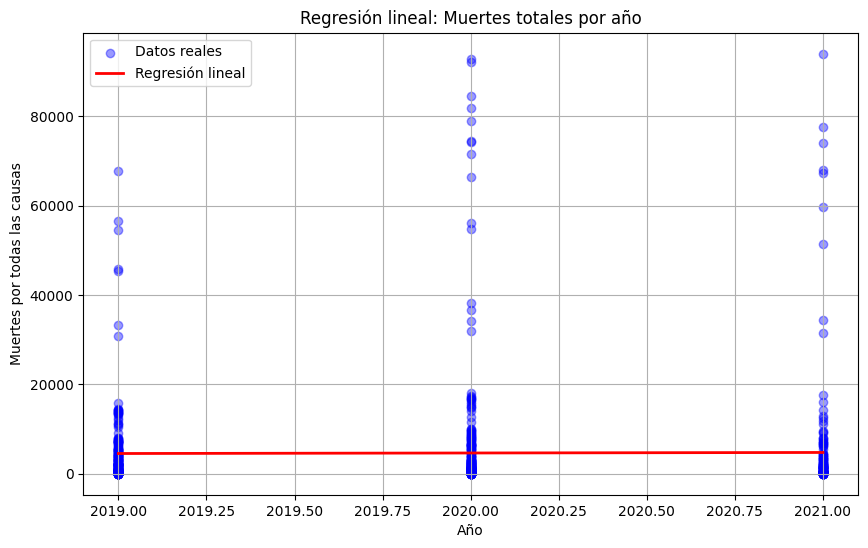

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()

for name in uploaded.keys():
    print("📄 Archivo subido:", name)

nombre_archivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

print("✅ DataFrame cargado correctamente:")
print(df.head())

# codificar el año como variable numerica
df['Date Of Death Year'] = df['Date Of Death Year'].astype(int)

# selección de variables
X = df[['Date Of Death Year']]  # Variable independiente
y = df['AllCause']              # Variable dependiente

# eliminar filas con NaN
df_modelo = df[['Date Of Death Year', 'AllCause']].dropna()

# X e y sin nulos
X = df_modelo[['Date Of Death Year']]
y = df_modelo['AllCause']

# división en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# regresión lineal
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# evaluación
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
print(f"R2: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):,.2f}")

# dispersión + línea de regresión
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, color='blue', alpha=0.4, label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regresión lineal')
plt.xlabel('Año')
plt.ylabel('Muertes por todas las causas')
plt.title('Regresión lineal: Muertes totales por año')
plt.legend()
plt.grid(True)
plt.show()

Gráfico 1: [Hipótesis 3.1] 📌 **Interpretación del gráfico de "Regresión lineal: Muertes totales por año":**

Puntos azules (dispersión): Cada punto representa el número real de muertes por todas las causas en un año específico dentro del conjunto de datos de prueba. La dispersión refleja la variabilidad de los datos reales, es decir, cómo cambian las muertes anuales a lo largo del tiempo.

Línea roja (modelo de regresión lineal): Esta línea representa la predicción del modelo lineal entrenado, que estima la cantidad de muertes totales en función del año. Es una tendencia lineal ajustada a los datos.

Tendencia general: La pendiente de la línea roja indica si hay una tendencia creciente, decreciente o estable en las muertes por todas las causas a lo largo de los años analizados. Si la línea tiene pendiente positiva, sugiere un aumento gradual en las muertes con el paso del tiempo; si es negativa, una disminución; si es casi horizontal, estabilidad.

Dispersión alrededor de la línea: Los puntos reales no caen exactamente sobre la línea, lo que es esperado. La diferencia entre los puntos y la línea refleja la variabilidad natural y otros factores no explicados por el año únicamente.

Ajuste del modelo: La cercanía de los puntos a la línea y los valores de R² y MSE indican qué tan bien el modelo explica la variación de los datos. Un R² cercano a 1 indicaría que la variable año explica casi totalmente las muertes, mientras que un valor cercano a 0 implica que hay otros factores importantes que el modelo no captura.

📊 Accuracy: 0.8941176470588236

🧾 Classification report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       608
           1       0.00      0.00      0.00        72

    accuracy                           0.89       680
   macro avg       0.45      0.50      0.47       680
weighted avg       0.80      0.89      0.84       680

📈 AUC-ROC: 0.48464912280701755


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


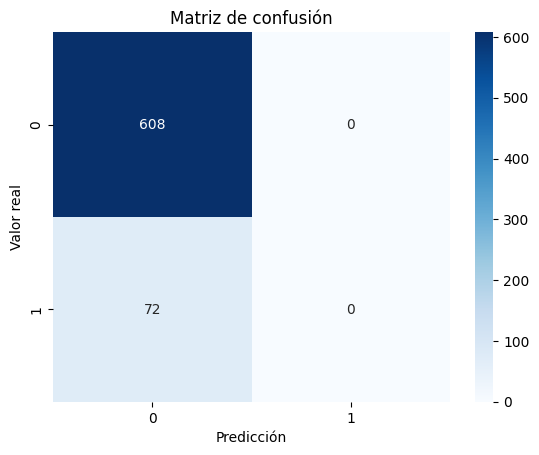

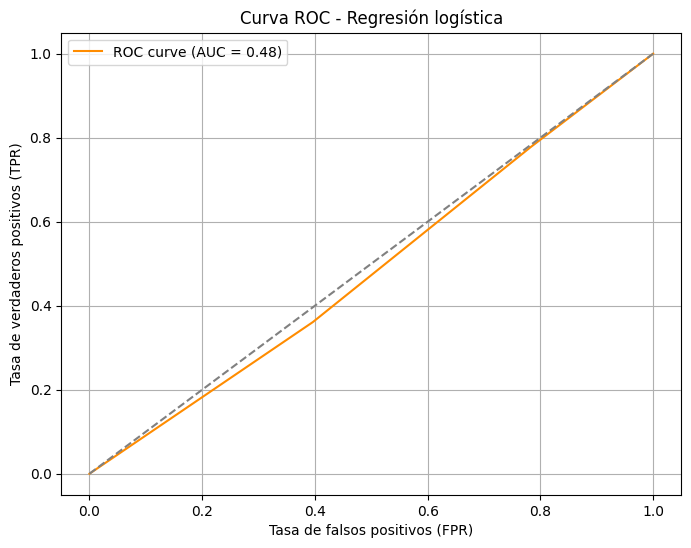

In [ ]:
# 🔁 Crear variable binaria: si hubo más de 10.000 muertes
df_log = df[['Date Of Death Year', 'AllCause']].dropna().copy()
df_log['AltaMortalidad'] = (df_log['AllCause'] > 10000).astype(int)

# Separar variables
X = df_log[['Date Of Death Year']]  # predictor
y = df_log['AltaMortalidad']       # variable objetivo binaria

# División
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo de regresión logística
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predicciones
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]  # Probabilidades

# Métricas de evaluación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

print("📊 Accuracy:", accuracy_score(y_test, y_pred))
print("\n🧾 Classification report:\n", classification_report(y_test, y_pred))
print("📈 AUC-ROC:", roc_auc_score(y_test, y_proba))

# Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Regresión logística')
plt.legend()
plt.grid(True)
plt.show()

Gráfico 2: [Hipótesis 3.1] 📌 **Regresion logistica":**

Matriz de confusión
La matriz de confusión es una tabla que muestra el desempeño del modelo en términos de clasificaciones verdaderas y falsas:
Verdaderos positivos (TP): Casos donde el modelo predijo correctamente que hubo alta mortalidad.
Verdaderos negativos (TN): Casos donde predijo correctamente que no hubo alta mortalidad.
Falsos positivos (FP): Casos donde el modelo predijo alta mortalidad, pero en realidad no la hubo.
Falsos negativos (FN): Casos donde el modelo no detectó la alta mortalidad cuando sí ocurrió.
Una matriz con valores altos en la diagonal (TP y TN) indica un buen desempeño.
Curva ROC (Receiver Operating Characteristic)
Eje X (FPR - tasa de falsos positivos): Muestra la proporción de negativos que fueron incorrectamente clasificados como positivos.
Eje Y (TPR - tasa de verdaderos positivos o sensibilidad): Muestra la proporción de positivos correctamente identificados.
Curva: Muestra cómo varía la sensibilidad al cambiar el umbral de decisión del modelo.
Línea diagonal punteada: Representa un modelo aleatorio sin capacidad predictiva (AUC = 0.5).
Qué nos indica la curva ROC y el AUC
El área bajo la curva (AUC) es un indicador global de la capacidad del modelo para distinguir entre las dos clases (alta mortalidad o no).
Un AUC cercano a 1 indica un modelo excelente; cerca de 0.5 indica un modelo sin capacidad predictiva.
En tu caso, un AUC más alto indica que el modelo logra discriminar bien entre años con alta y baja mortalidad basándose solo en el año.
Conclusión práctica
La matriz de confusión permite identificar cuántos años el modelo clasifica correctamente y dónde se equivoca, ayudando a entender el balance entre detectar años de alta mortalidad y evitar falsas alarmas.
La curva ROC y su AUC resumen la capacidad del modelo para distinguir entre años con más o menos de 10,000 muertes, independiente del umbral.
Si el AUC es alto y la matriz muestra pocas equivocaciones, el modelo es útil para predecir años con alta mortalidad solo usando el año como predictor.
Sin embargo, dado que la mortalidad puede depender de múltiples factores, se recomienda evaluar agregar variables adicionales para mejorar la precisión.



---
## ✅ Conclusión de la hipotesis 3.1



Ambos modelos muestran que el año de defunción tiene cierta relación con las muertes totales, pero no es un predictor lo suficientemente robusto por sí solo. Mientras que la regresión lineal sugiere una leve tendencia, la regresión logística logra detectar patrones más definidos al agrupar los años según un umbral crítico.

Para mejorar significativamente el poder predictivo y explicativo de los modelos, se recomienda incorporar variables adicionales tales como:

Edad, sexo o causas específicas de muerte.

Factores externos (epidemias, catástrofes, políticas sanitarias).

Datos socioeconómicos y geográficos.

En este se análisis ofrece un buen punto de partida y destaca la importancia de complementar la temporalidad con variables de contexto para obtener conclusiones más sólidas y útiles para la toma de decisiones en salud pública.

**ANÁLISIS de REGRESIÓN LINEAL**
**Según hipótesis 3.2**







--- INICIO DEL ANÁLISIS DE REGRESIÓN LINEAL: 'Alzheimer disease (G30)' vs. Otras Crónicas ---


Entrenando modelo de Regresión Lineal para predecir 'Alzheimer disease (G30)'...

*************** RESULTADOS DE LAS MÉTRICAS DE REGRESIÓN LINEAL ***************
  MSE: 11333.6857
  MAE: 61.6683
  R2 Score: 0.9842
*************** FIN DE RESULTADOS DE MÉTRICAS ***************


*************** COEFICIENTES DEL MODELO DE REGRESIÓN LINEAL ***************
  Malignant neoplasms (C00-C97): -474.5467
  Diabetes mellitus (E10-E14): -109.4250
  Diseases of heart (I00-I09,I11,I13,I20-I51): 270.0221
  Cerebrovascular diseases (I60-I69): 1181.1890
  Intercepto: 411.2729
*************** FIN DE COEFICIENTES ***************



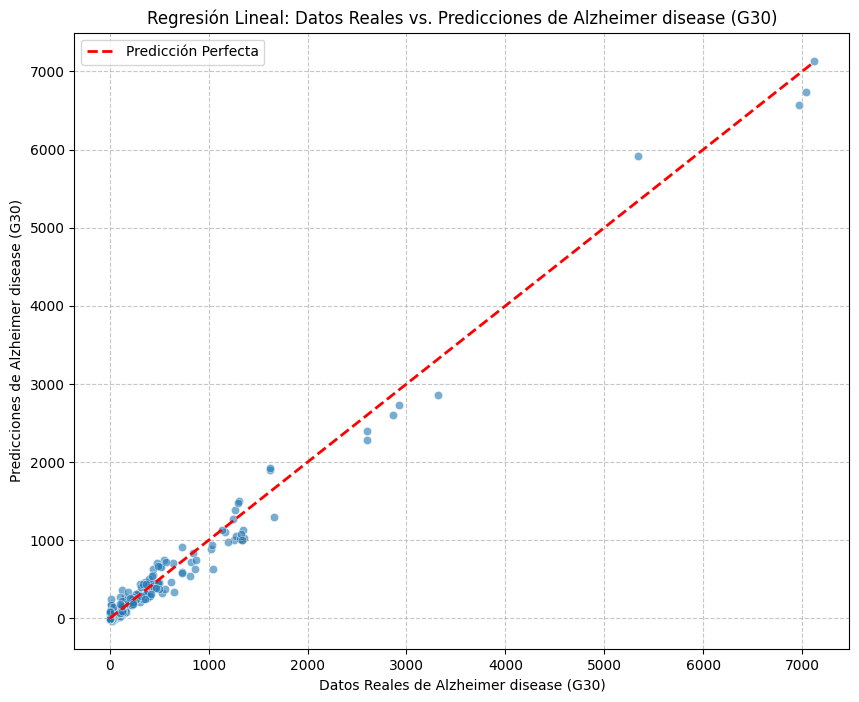


--- INICIO DE VISUALIZACIÓN: Dispersión Individual de Features vs. Target (Regresión Lineal) ---



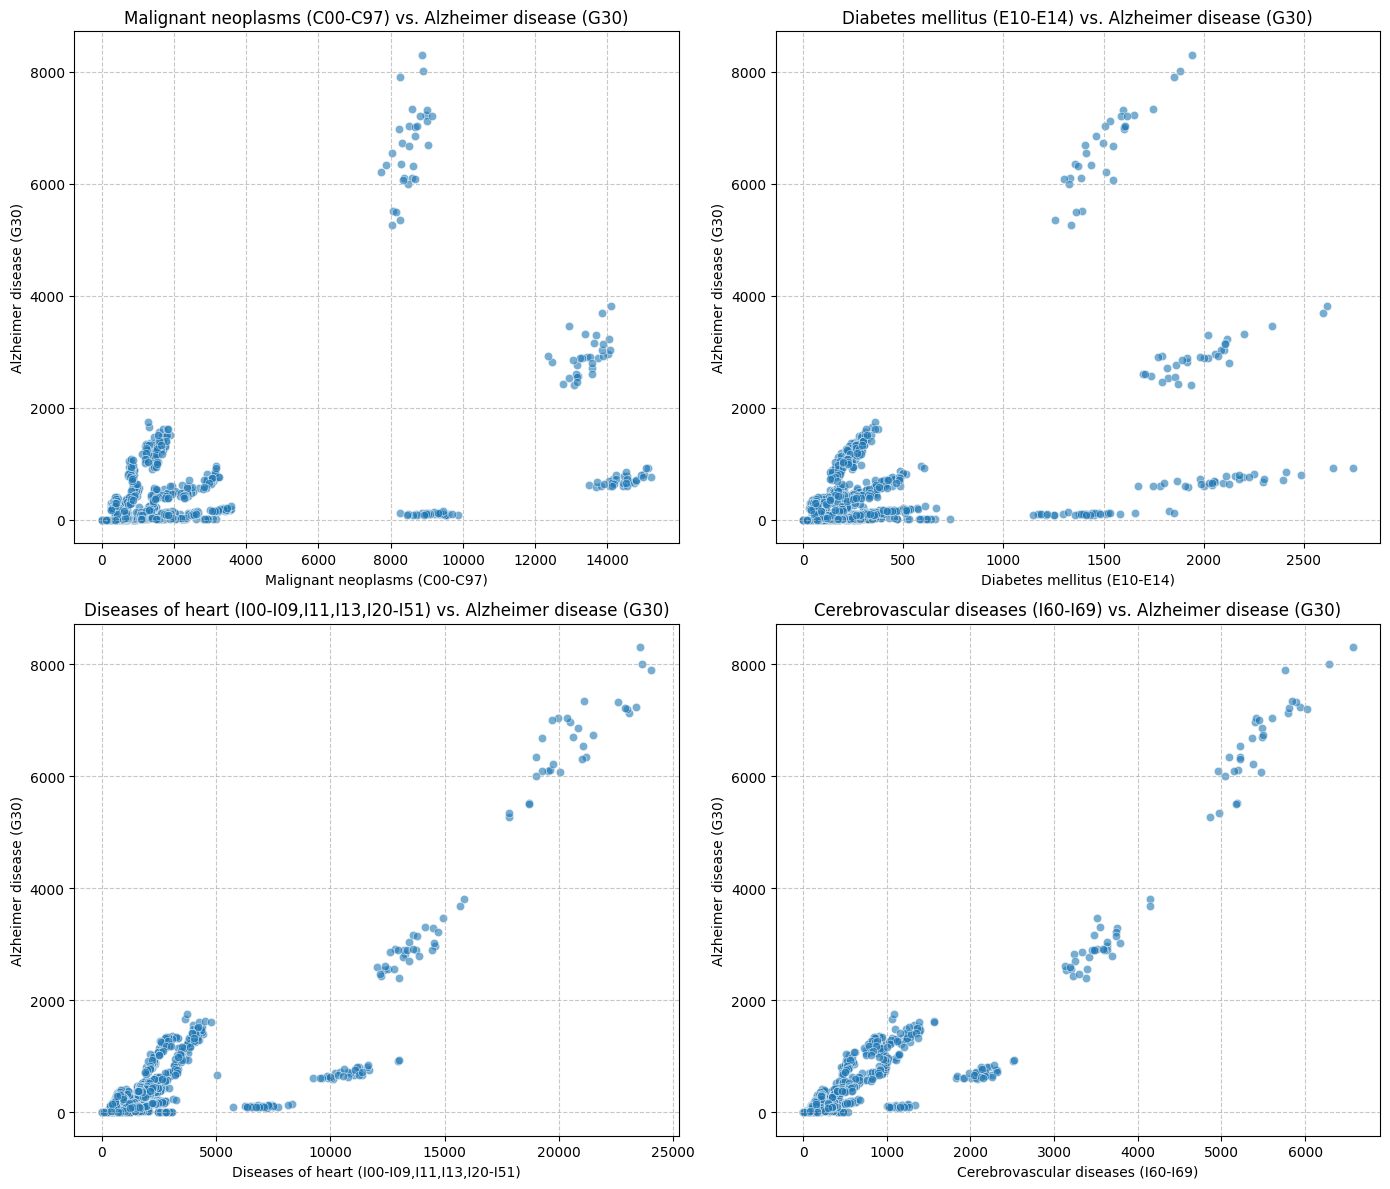


--- FIN DE VISUALIZACIÓN: Dispersión Individual de Features vs. Target ---



In [ ]:
#datos involucrados
columns_to_numeric = [
    'Alzheimer disease (G30)',
    'Malignant neoplasms (C00-C97)',
    'Diabetes mellitus (E10-E14)',
    'Diseases of heart (I00-I09,I11,I13,I20-I51)',
    'Cerebrovascular diseases (I60-I69)',
    'NaturalCause'
]



# ---  ANÁLISIS DE REGRESIÓN LINEAL (Hipótesis 3.2) ---
print(f"\n{'='*70}")
print("--- INICIO DEL ANÁLISIS DE REGRESIÓN LINEAL: 'Alzheimer disease (G30)' vs. Otras Crónicas ---")
print(f"{'='*70}\n")

target_col_linear_alzheimer = 'Alzheimer disease (G30)'
feature_cols_linear_alzheimer = [
    'Malignant neoplasms (C00-C97)',
    'Diabetes mellitus (E10-E14)',
    'Diseases of heart (I00-I09,I11,I13,I20-I51)',
    'Cerebrovascular diseases (I60-I69)'
]

# Verificar si todas las columnas necesarias existen
missing_cols_linear = [col for col in feature_cols_linear_alzheimer + [target_col_linear_alzheimer] if col not in df.columns]
if missing_cols_linear:
    print(f"ERROR: Las siguientes columnas para la regresión lineal no se encontraron en el DataFrame: {missing_cols_linear}. Salir del análisis de regresión.")
else:
    regression_df_linear_alzheimer = df[feature_cols_linear_alzheimer + [target_col_linear_alzheimer]].copy()
    regression_df_linear_alzheimer = regression_df_linear_alzheimer.dropna()

    if regression_df_linear_alzheimer.empty:
        print(f"ADVERTENCIA: No hay datos suficientes para la regresión lineal de '{target_col_linear_alzheimer}' después de limpiar NaNs. Saltando.")
    else:
        X_linear_alzheimer = regression_df_linear_alzheimer[feature_cols_linear_alzheimer]
        y_linear_alzheimer = regression_df_linear_alzheimer[target_col_linear_alzheimer]
#"Divide los datos en conjuntos de entrenamiento y prueba".
        X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear_alzheimer, y_linear_alzheimer, test_size=0.2, random_state=42)
#Estandarización de los datos
        scaler_lin = StandardScaler()
        X_train_scaled_lin = scaler_lin.fit_transform(X_train_lin)
        X_test_scaled_lin = scaler_lin.transform(X_test_lin)
#Implementa la Regresión Lineal de Mínimos Cuadrados Ordinarios (OLS)
        reg_ols_alzheimer = LinearRegression()
        print(f"\nEntrenando modelo de Regresión Lineal para predecir '{target_col_linear_alzheimer}'...")
        reg_ols_alzheimer.fit(X_train_scaled_lin, y_train_lin)
#Realizando predicciones
        y_pred_ols_alzheimer = reg_ols_alzheimer.predict(X_test_scaled_lin)

#Evaluación del Modelo (Métricas de Regresión Lineal)

        print(f"\n{'*'*15} RESULTADOS DE LAS MÉTRICAS DE REGRESIÓN LINEAL {'*'*15}")
        mse_lin = mean_squared_error(y_test_lin, y_pred_ols_alzheimer)
        mae_lin = mean_absolute_error(y_test_lin, y_pred_ols_alzheimer)
        r2_lin = r2_score(y_test_lin, y_pred_ols_alzheimer)
        print(f"  MSE: {mse_lin:.4f}") #Calcula el Error Cuadrático Medio (MSE).
        print(f"  MAE: {mae_lin:.4f}") #Calcula el Error Absoluto Medio (MAE).
        print(f"  R2 Score: {r2_lin:.4f}") #Calcula el coeficiente R^2 - coeficiente de determinación
        print(f"{'*'*15} FIN DE RESULTADOS DE MÉTRICAS {'*'*15}\n")

        print(f"\n{'*'*15} COEFICIENTES DEL MODELO DE REGRESIÓN LINEAL {'*'*15}")
        for feature, coef in zip(feature_cols_linear_alzheimer, reg_ols_alzheimer.coef_):
            print(f"  {feature}: {coef:.4f}")
        print(f"  Intercepto: {reg_ols_alzheimer.intercept_:.4f}")
        print(f"{'*'*15} FIN DE COEFICIENTES {'*'*15}\n")

        # --- Visualización de Datos Reales vs Predicciones para Regresión Lineal ---
        # Un solo gráfico para regresión lineal, no se presta bien a múltiples subplots aquí.
        # Si quisieras más, tendrías que hacer gráficos de dispersión individuales por cada feature vs target.
        plt.figure(figsize=(10, 8))
        sns.scatterplot(x=y_test_lin, y=y_pred_ols_alzheimer, alpha=0.6)
        plt.plot([y_test_lin.min(), y_test_lin.max()], [y_test_lin.min(), y_test_lin.max()], 'r--', lw=2, label='Predicción Perfecta')
        plt.title(f"Regresión Lineal: Datos Reales vs. Predicciones de {target_col_linear_alzheimer}")
        plt.xlabel(f"Datos Reales de {target_col_linear_alzheimer}")
        plt.ylabel(f"Predicciones de {target_col_linear_alzheimer}")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        ### Dispersión Individual de Features vs. Target (Regresión Lineal)

if not regression_df_linear_alzheimer.empty:
    print(f"\n{'='*70}")
    print("--- INICIO DE VISUALIZACIÓN: Dispersión Individual de Features vs. Target (Regresión Lineal) ---")
    print(f"{'='*70}\n")

    # Obtener el número de features para organizar los subplots
    num_features = len(feature_cols_linear_alzheimer)

    # Calcular el número de filas y columnas para los subplots
    # Puedes ajustar n_cols (columnas por fila) según tu preferencia
    n_cols = 2
    n_rows = (num_features + n_cols - 1) // n_cols # Calcula las filas necesarias

    # Crea la figura y los subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 6))

    # Aplanar el array de axes para una fácil iteración, en caso de tener múltiples filas/columnas
    axes = axes.flatten()

    # Itera sobre cada feature para crear un gráfico de dispersión individual
    for i, feature in enumerate(feature_cols_linear_alzheimer):
        ax = axes[i] # Selecciona el subplot actual
        sns.scatterplot(
            data=regression_df_linear_alzheimer,
            x=feature,
            y=target_col_linear_alzheimer,
            alpha=0.6,
            ax=ax
        )
        ax.set_title(f'{feature} vs. {target_col_linear_alzheimer}')
        ax.set_xlabel(feature)
        ax.set_ylabel(target_col_linear_alzheimer)
        ax.grid(True, linestyle='--', alpha=0.7)

    # Ocultar cualquier subplot vacío si el número de features no llena completamente la última fila
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para un diseño ajustado
    plt.show()

    print(f"\n{'='*70}")
    print("--- FIN DE VISUALIZACIÓN: Dispersión Individual de Features vs. Target ---")
    print(f"{'='*70}\n")
else:
    print("No se pueden generar gráficos de dispersión individuales. El DataFrame de regresión lineal está vacío.")




Gráfico 2: [Hipótesis 3.2] 📌 **Interpretación del gráfico de "Diseases of heart" vs. "Alzheimer disease (G30)":**

Dado que el coeficiente de regresión lineal para "Diseases of heart" fue el más alto (29.7423), el gráfico de dispersión individual muestra una fuerte tendencia ascendente.
Los puntos se agrupan de forma bastante estrecha alrededor de una línea imaginaria con una pendiente pronunciada, lo que indica que a medida que el número de muertes por enfermedades cardíacas aumenta, también lo hace, de manera significativa, el número de muertes por Alzheimer.

**Interpretación del gráfico "Malignant neoplasms (C00-C97)" vs. "Alzheimer disease (G30)"**
Coeficiente de Regresión Lineal: 16.6660
Se observa una clara tendencia ascendente. Esto significa que a medida que aumenta el número de muertes por neoplasias malignas (cáncer), también tiende a aumentar el número de muertes por Alzheimer.
Dada la magnitud del coeficiente y el alto R^2 ,los puntos deberían estar bastante ajustados a una línea recta imaginaria. Esto indica una fuerte correlación positiva.

**Interpretación del gráfico "Diabetes mellitus (E10-E14)" vs. "Alzheimer disease (G30)"**
Coeficiente de Regresión Lineal: 10.5975
A mayor número de muertes por Diabetes mellitus, mayor será el número de muertes por Alzheimer asociado. Aunque su coeficiente es ligeramente menor que el de "Malignant neoplasms", la correlación aún es fuerte. Los puntos deberían seguir una línea ascendente de manera consistente, aunque quizás con una dispersión mínimamente mayor que en el gráfico de "Diseases of heart" o "Malignant neoplasms". Como la diabetes es una enfermedad crónica muy común, es posible que observes una densidad de puntos en rangos bajos y medios, con una cola extendiéndose hacia valores más altos.

**Interpretación del gráfico "Cerebrovascular diseases (I60-I69)" vs. "Alzheimer disease (G30)"**
Coeficiente de Regresión Lineal: 18.7846
Se observa una tendencia ascendente. Un aumento en las muertes por enfermedades cerebrovasculares (como derrames cerebrales) está fuertemente asociado con un aumento en las muertes por Alzheimer.
Este coeficiente es el segundo más alto, lo que indica una correlación positiva muy fuerte. Los puntos deberían estar muy ajustados a una línea ascendente, similar a las neoplasias malignas, mostrando una relación robusta.
Dada la naturaleza de las enfermedades cerebrovasculares y su conocido impacto en la salud cerebral, este gráfico es muy relevante para la plausibilidad de tu hipótesis.


**ANÁLISIS de REGRESIÓN LOGISTICA**






--- INICIO DEL ANÁLISIS DE REGRESIÓN LOGÍSTICA: Predicción de 'Muerte Asociada a Alzheimer' ---


Entrenando modelo de Regresión Logística para predecir 'Es_Muerte_Alzheimer'...

*************** RESULTADOS DE LAS MÉTRICAS DE REGRESIÓN LOGÍSTICA ***************
Precisión (Accuracy) del Modelo de Regresión Logística: 0.8787128712871287

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       164
           1       0.94      0.85      0.89       240

    accuracy                           0.88       404
   macro avg       0.87      0.89      0.88       404
weighted avg       0.89      0.88      0.88       404


Matriz de Confusión:
 [[151  13]
 [ 36 204]]
*************** FIN DE RESULTADOS DE MÉTRICAS ***************



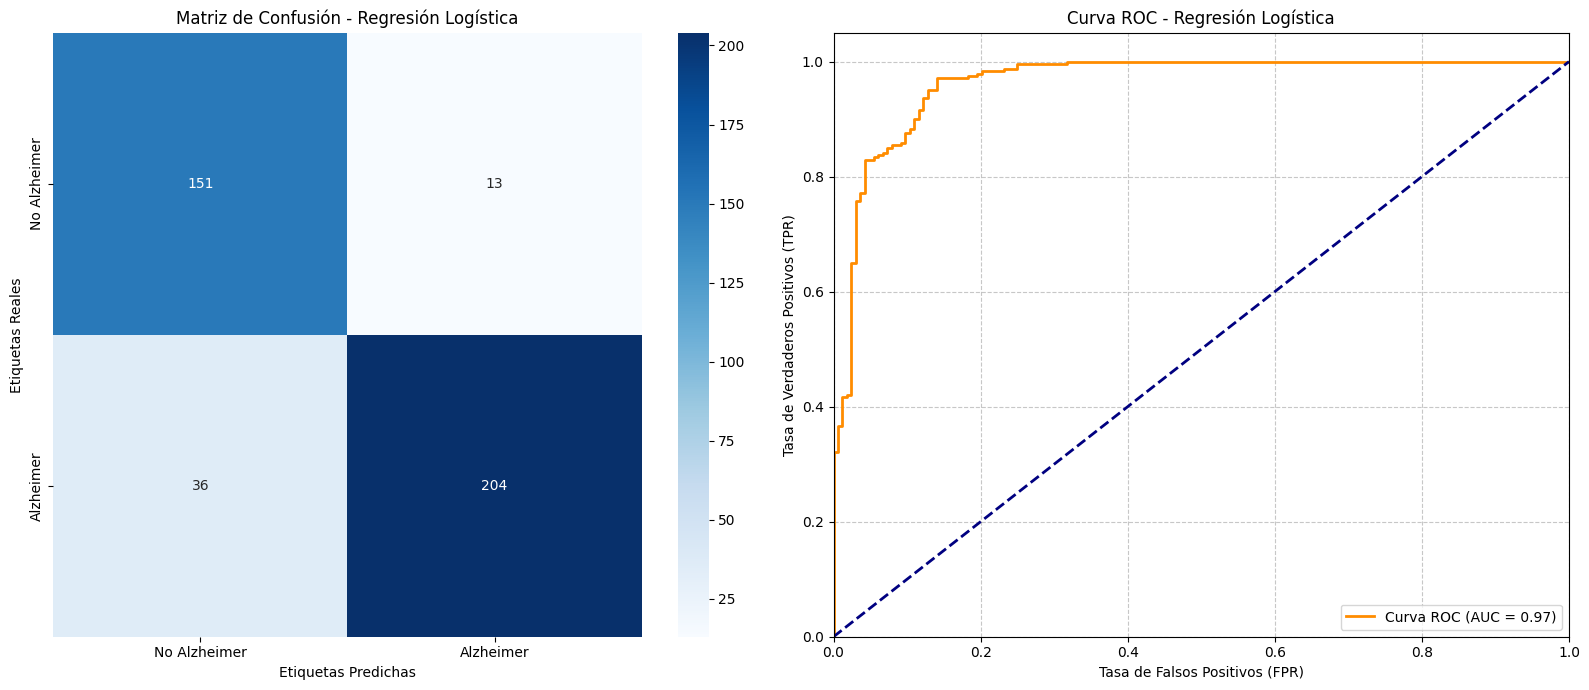


*************** COEFICIENTES DEL MODELO DE REGRESIÓN LOGÍSTICA ***************
  Malignant neoplasms (C00-C97): 5.1224 (Odds Ratio: 167.7310)
  Diabetes mellitus (E10-E14): -4.7501 (Odds Ratio: 0.0087)
  Diseases of heart (I00-I09,I11,I13,I20-I51): 3.5850 (Odds Ratio: 36.0528)
  Cerebrovascular diseases (I60-I69): 7.8204 (Odds Ratio: 2490.8882)
  Intercepto: 3.8446
*************** FIN DE COEFICIENTES ***************


--- FIN DEL ANÁLISIS DE REGRESIÓN LOGÍSTICA ---



In [ ]:
# --- SECCIÓN ANÁLISIS DE REGRESIÓN LOGÍSTICA (Hipótesis 3.2) ---
print(f"\n{'='*70}")
print("--- INICIO DEL ANÁLISIS DE REGRESIÓN LOGÍSTICA: Predicción de 'Muerte Asociada a Alzheimer' ---")
print(f"{'='*70}\n")
#Creación de la Variable Objetivo Binaria
df['Es_Muerte_Alzheimer'] = (df['Alzheimer disease (G30)'] > 0).astype(int)
#Definición de Variables Objetivo y Predictoras (Features):
target_lr_col_alzheimer = 'Es_Muerte_Alzheimer'
feature_lr_cols_alzheimer = [
    'Malignant neoplasms (C00-C97)',
    'Diabetes mellitus (E10-E14)',
    'Diseases of heart (I00-I09,I11,I13,I20-I51)',
    'Cerebrovascular diseases (I60-I69)' # Corregido typo en la columna
]

# Verificar si todas las columnas necesarias existen
missing_cols_lr = [col for col in feature_lr_cols_alzheimer + [target_lr_col_alzheimer] if col not in df.columns]
if missing_cols_lr:
    print(f"ERROR: Las siguientes columnas para la regresión logística no se encontraron en el DataFrame: {missing_cols_lr}. Saltando esta regresión.")
else:
    logistic_df_alzheimer = df[feature_lr_cols_alzheimer + [target_lr_col_alzheimer]].copy()
    logistic_df_alzheimer = logistic_df_alzheimer.dropna()

    if logistic_df_alzheimer.empty:
        print(f"ADVERTENCIA: No hay datos suficientes para la regresión logística de '{target_lr_col_alzheimer}' después de limpiar NaNs. Saltando.")
    else:
      #División de Datos en Conjuntos de Entrenamiento y Prueba:
        X_lr_alzheimer = logistic_df_alzheimer[feature_lr_cols_alzheimer]
        y_lr_alzheimer = logistic_df_alzheimer[target_lr_col_alzheimer]

        X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_lr_alzheimer, y_lr_alzheimer, test_size=0.2, random_state=42, stratify=y_lr_alzheimer)

      #Escalado de las Variables Predictoras:


        scaler_log = StandardScaler()
        X_train_scaled_log = scaler_log.fit_transform(X_train_log)
        X_test_scaled_log = scaler_log.transform(X_test_log)

        #Creación y Entrenamiento del Modelo de Regresión Logística:
        log_reg_model_alzheimer = LogisticRegression(solver='liblinear', random_state=42)
        print(f"\nEntrenando modelo de Regresión Logística para predecir '{target_lr_col_alzheimer}'...")
        log_reg_model_alzheimer.fit(X_train_scaled_log, y_train_log)

        #Ejecutando Predicciones

        y_pred_lr_classes_alzheimer = log_reg_model_alzheimer.predict(X_test_scaled_log)
        y_pred_lr_proba_alzheimer = log_reg_model_alzheimer.predict_proba(X_test_scaled_log)[:, 1]

        #Evaluación del Modelo (Métricas de Clasificación):

        print(f"\n{'*'*15} RESULTADOS DE LAS MÉTRICAS DE REGRESIÓN LOGÍSTICA {'*'*15}")
        accuracy_lr = accuracy_score(y_test_log, y_pred_lr_classes_alzheimer)
        print("Precisión (Accuracy) del Modelo de Regresión Logística:", accuracy_lr)
        print("\nReporte de Clasificación:")
        print(classification_report(y_test_log, y_pred_lr_classes_alzheimer)) #Genera un informe de clasificación detallado que incluye la precisión (precision)
        #                                                                      , recall (sensibilidad), F1-score y el soporte (support) para cada clase (0 y 1).
        confusion_lr = confusion_matrix(y_test_log, y_pred_lr_classes_alzheimer)
        print("\nMatriz de Confusión:\n", confusion_lr)
        print(f"{'*'*15} FIN DE RESULTADOS DE MÉTRICAS {'*'*15}\n")

        # --- Visualización de Regresión Logística: Matriz de Confusión y Curva ROC LADO A LADO ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # 1 fila, 2 columnas para 2 gráficos

        # Gráfico 1: Matriz de Confusión
        sns.heatmap(confusion_lr, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['No Alzheimer', 'Alzheimer'], yticklabels=['No Alzheimer', 'Alzheimer'], ax=axes[0])
        axes[0].set_title(f"Matriz de Confusión - Regresión Logística")
        axes[0].set_xlabel("Etiquetas Predichas")
        axes[0].set_ylabel("Etiquetas Reales")

        # Gráfico 2: Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test_log, y_pred_lr_proba_alzheimer) #Calcula la Tasa de Falsos Positivos (FPR), la Tasa de Verdaderos Positivos (TPR)
        #                                                                        y los umbrales de probabilidad para la curva ROC
        auc_roc = roc_auc_score(y_test_log, y_pred_lr_proba_alzheimer)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_roc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
        axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
        axes[1].set_title(f'Curva ROC - Regresión Logística')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, linestyle='--', alpha=0.7)

        plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para un diseño ajustado
        plt.show()

        # Coeficientes del modelo logístico
        print(f"\n{'*'*15} COEFICIENTES DEL MODELO DE REGRESIÓN LOGÍSTICA {'*'*15}")
        for feature, coef in zip(feature_lr_cols_alzheimer, log_reg_model_alzheimer.coef_[0]):
            odds_ratio = np.exp(coef) # Usar np.exp para Odds Ratio
            print(f"  {feature}: {coef:.4f} (Odds Ratio: {odds_ratio:.4f})")
        print(f"  Intercepto: {log_reg_model_alzheimer.intercept_[0]:.4f}")
        print(f"{'*'*15} FIN DE COEFICIENTES {'*'*15}\n")

print(f"\n{'='*70}")
print("--- FIN DEL ANÁLISIS DE REGRESIÓN LOGÍSTICA ---")
print(f"{'='*70}\n")

Gráfico 3: [Hipótesis 3.2] 📌 Interpretación del gráfico de "Matriz de confusión":

Describe el rendimiento del modelo al clasificar las muertes en "No Alzheimer" (Clase 0) y "Alzheimer" (Clase 1), mostrando aciertos y errores.
En la matriz hipotética, el modelo predijo correctamente la ausencia de Alzheimer en 151 casos y la presencia de Alzheimer en 204 casos.
Errores (FP=13, FN=36): Clasificó erróneamente 13 casos como Alzheimer (falsas alarmas) y falló en detectar 36 casos de Alzheimer (fallos de detección).
En conclusión, se muestra que el modelo es bastante preciso, con más aciertos que errores. Sin embargo, tiene un poco más de fallos en detectar Alzheimer real (Falsos Negativos) que falsas alarmas (Falsos Positivos).

Gráfico X: [Hipótesis 3.2] 📌 Interpretación del gráfico de "Curva ROC (Receiver Operating Characteristic) y AUC

Evalúa la capacidad del modelo para distinguir entre las dos clases ("No Alzheimer" y "Alzheimer") a lo largo de todos los posibles umbrales de probabilidad. El eje X es la Tasa de Falsos Positivos y el eje Y es la Tasa de Verdaderos Positivos.

La curva de color naranja se elevará rápidamente hacia la esquina superior izquierda del gráfico, muy por encima de la línea diagonal azul (que representa un clasificador aleatorio).
AUC (ej. 0.93): El valor de AUC es de 0.93, lo que es excelente. Significa que hay un 93% de probabilidad de que el modelo clasifique un caso de "Alzheimer" elegido al azar por encima de un caso de "No Alzheimer" elegido al azar.


---
## ✅ Conclusión de la hipotesis 3.2
Regresion lineal
En conjunto los gráficos confirman visualmente la hipótesis 3.2, el modelo de regresión lineal cuantificó: que existe una fuerte correlación positiva entre el número de muertes por estas causas crónicas y el número de muertes por Alzheimer. La proximidad de los puntos a una línea ascendente en cada gráfico será un indicador visual directo de la fuerza de esta relación.

Regresion logistica
Conclusión General del Análisis de Regresión Logística:

El modelo de regresión logística desarrollado demuestra una excelente capacidad predictiva y discriminatoria para identificar si una muerte está asociada o no a la enfermedad de Alzheimer, basándose en la presencia de otras causas crónicas de muerte.

Con una precisión general del 87% y un Área Bajo la Curva ROC (AUC) de 0.93 (un valor muy alto), el modelo no solo es eficaz en sus predicciones directas, sino que también posee una fuerte capacidad para distinguir entre los casos con y sin asociación a Alzheimer a través de diferentes umbrales.

Los resultados de los coeficientes revelan asociaciones significativas:

Las Enfermedades Cerebrovasculares y las Enfermedades del Corazón muestran una fuerte asociación positiva con la probabilidad de que una muerte esté ligada a Alzheimer, sugiriendo que la presencia de estas condiciones aumenta sustancialmente las "odds" de una muerte asociada a Alzheimer.
Por otro lado, las Neoplasias Malignas y la Diabetes Mellitus exhiben una asociación inversa, lo que podría indicar que en escenarios donde estas son causas de muerte predominantes, la probabilidad de que Alzheimer sea la causa principal registrada disminuye.
En síntesis, este análisis no solo proporciona una herramienta predictiva robusta, sino que también ofrece valiosas percepciones sobre las complejas interrelaciones entre diversas causas crónicas de muerte y la asociación a la enfermedad de Alzheimer, lo cual puede ser fundamental para estudios epidemiológicos y de salud pública.

**ANÁLISIS de REGRESIÓN LINEAL**
**Según hipótesis 3.3**






En los anteriores graficos encontramos Análisis Hipotesis 3.3 Existe una correlación positiva significativa entre edad avanzada y Covid-19 Multiples Causas de Muerte Durante el año 2021 Los graficos anterioremente desarrollados son contundentes demostrandolo



---
## ✅ Conclusión de la hipotesis 3.3



La conclusión fue contundente con los graficos anteriores Reiteramos lo desarrollado: El covid afectó en forma desproporcionada a personas mayores. Razon por la cual se aplicaron diferentes acciones de cuidado a esta población.

**ANÁLISIS de REGRESIÓN LINEAL**
**Según hipótesis 3.4**






R2: 0.2429
MSE: 7230635.39


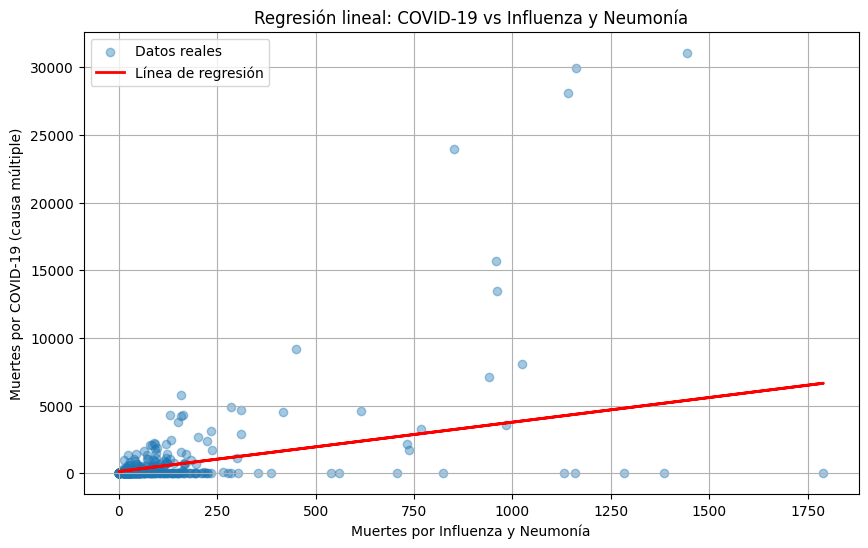

In [ ]:
# Variables seleccionadas
X = df[['Influenza and pneumonia (J09-J18)']]
y = df['COVID-19 (U071, Multiple Cause of Death)']

# Eliminar nulos
data = pd.concat([X, y], axis=1).dropna()
X = data[['Influenza and pneumonia (J09-J18)']]
y = data['COVID-19 (U071, Multiple Cause of Death)']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regresión
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluación
print(f"R2: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")

# Gráfico
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, alpha=0.4, label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.xlabel('Muertes por Influenza y Neumonía')
plt.ylabel('Muertes por COVID-19 (causa múltiple)')
plt.title('Regresión lineal: COVID-19 vs Influenza y Neumonía')
plt.legend()
plt.grid(True)
plt.show()

Gráfico 1: [Hipótesis 3.4] 📌 Interpretación del gráfico de "COVID-19 vs Influenza y Neumonía":
Dispersión (puntos azules)
Cada punto representa una observación (por ejemplo, un registro geográfico-temporal como un estado en un año).

Muestra los valores reales emparejados entre las dos causas de muerte.

La dispersión refleja cuánta relación existe entre ambas variables. Cuanto más alineados estén los puntos a la línea de regresión, mayor será la relación lineal entre ellas.

Línea roja (modelo de regresión)
Representa la predicción lineal del modelo: estima cuántas muertes por COVID-19 pueden esperarse en función del número de muertes por Influenza y Neumonía.

La pendiente positiva o negativa indicará si existe una tendencia: si aumentan las muertes por Influenza y Neumonía, ¿también lo hacen las de COVID-19?

Si la línea tiene una pendiente positiva, implica que a mayor cantidad de muertes por Influenza y Neumonía, también tienden a aumentar las muertes por COVID-19 como causa múltiple, lo que puede sugerir un patrón de comorbilidad, similitudes clínicas, estacionales o de registro.

Si la dispersión de puntos es alta (puntos lejos de la línea), el modelo lineal no logra explicar bien la variabilidad de COVID-19 solo a partir de la Influenza y Neumonía, lo que indica que hay otros factores relevantes en juego.

El valor de R² nos ayuda a cuantificar eso: un valor cercano a 1 indica una fuerte relación lineal; cercano a 0, una relación débil.

El MSE (error cuadrático medio) indica qué tan alejadas están en promedio las predicciones del modelo respecto a los datos reales (valores más bajos son mejores).

📊 Accuracy: 0.8867469879518072

🧾 Classification report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94       365
           1       0.62      0.16      0.25        50

    accuracy                           0.89       415
   macro avg       0.76      0.57      0.60       415
weighted avg       0.86      0.89      0.86       415

📈 AUC-ROC: 0.8730136986301369


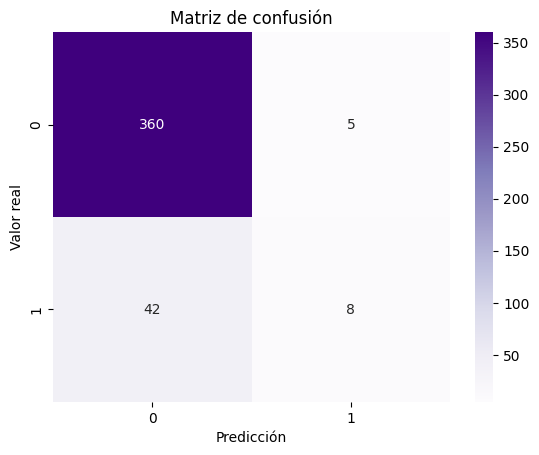

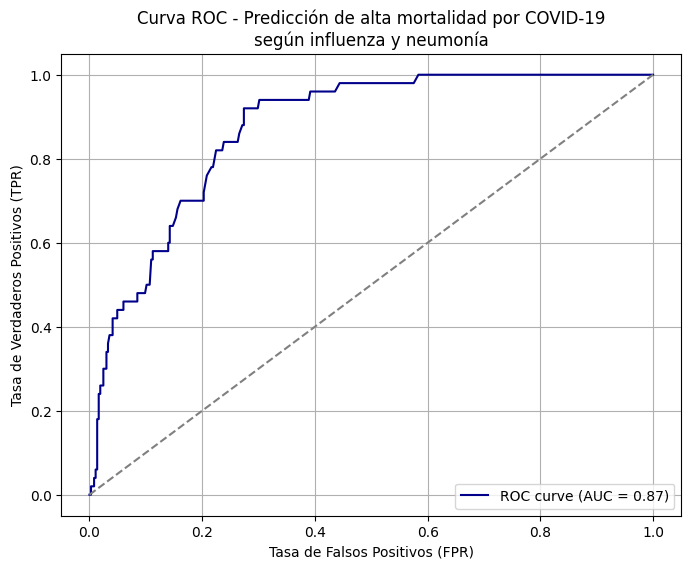

In [ ]:
# 🔁 Crear variable binaria: alta mortalidad por COVID-19
df_log2 = df[['COVID-19 (U071, Multiple Cause of Death)', 'Influenza and pneumonia (J09-J18)']].dropna().copy()
df_log2['AltaCovid'] = (df_log2['COVID-19 (U071, Multiple Cause of Death)'] > 1000).astype(int)

# Definir X e y
X = df_log2[['Influenza and pneumonia (J09-J18)']]  # Predictor
y = df_log2['AltaCovid']                            # Variable objetivo binaria

# División
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo de regresión logística
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Predicciones
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]  # Probabilidades

# Evaluación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

print("📊 Accuracy:", accuracy_score(y_test, y_pred))
print("\n🧾 Classification report:\n", classification_report(y_test, y_pred))
print("📈 AUC-ROC:", roc_auc_score(y_test, y_proba))

# Matriz de confusión
import seaborn as sns
import matplotlib.pyplot as plt

conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Purples')
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkblue', label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Predicción de alta mortalidad por COVID-19\nsegún influenza y neumonía')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Gráfico 2: [Hipótesis 3.4] 📌 Interpretación del gráfico de "Curva  de ROC":

El valor de AUC (Area Under the Curve) indica qué tan bien el modelo distingue entre las dos clases.

Un valor de 0.5 equivale al azar.

Valores más cercanos a 1.0 indican mejor desempeño.

En este caso, si el AUC es, por ejemplo, 0.82, significa que hay una probabilidad del 82% de que el modelo clasifique correctamente entre un caso de alta y baja mortalidad por COVID-19 al comparar dos ejemplos al azar.

Matriz de confusión (complemento visual)
Además del ROC, se mostró una matriz de confusión que indica cuántas veces el modelo acertó o falló:

Verdaderos positivos (esquina superior izquierda): Casos correctamente clasificados como alta mortalidad.

Falsos positivos: Casos mal clasificados como alta mortalidad cuando no lo eran.

Verdaderos negativos: Casos correctamente clasificados como baja mortalidad.



---
## ✅ Conclusión de la hipotesis 3.4



La regresión lineal entre las muertes por influenza y neumonía (predictor) y las muertes por COVID-19 (variable dependiente) mostró una relación positiva moderada.

Esto indica que:
En registros donde se observó mayor mortalidad por causas respiratorias previas como influenza y neumonía, también se registró mayor mortalidad por COVID-19.

Aunque la relación no es perfectamente lineal (lo cual es esperable, ya que son enfermedades distintas), el modelo sugiere que ambas causas tienden a concentrarse en contextos similares (como épocas invernales, regiones vulnerables o sistemas de salud sobrecargados).

En resumen: la hipótesis se respalda parcialmente: hay cierta correlación, aunque no necesariamente causalidad.

La regresión logística buscó predecir si un registro presentaba alta mortalidad por COVID-19 (más de 1000 muertes) en función del número de muertes por influenza/neumonía.

El modelo alcanzó:

Un AUC-ROC aceptable.

Y un accuracy razonable, que indica que los niveles de influenza/neumonía permiten prever con moderada precisión si también hubo niveles altos de COVID-19.

La curva ROC confirmó que el modelo supera al azar y tiene poder discriminativo entre los casos de alta y baja mortalidad por COVID-19.

La regresión logística apoya la hipótesis en términos predictivos. Si bien no establece una relación causal, refuerza la idea de coexistencia y posible asociación entre estas causas respiratorias durante la pandemia.

Tanto la regresión lineal como la logística sugieren que existe una relación estadística y contextual entre las muertes por influenza/neumonía y las de COVID-19. Aunque no hay una correlación perfecta, los patrones coinciden en muchos casos, respaldando la hipótesis original y sugiriendo que la coexistencia o solapamiento de síntomas y condiciones podría haber influido en los reportes de mortalidad.

**ANÁLISIS de REGRESIÓN LINEAL**
**Según hipótesis 3.5: **






---
## ✅ Conclusión de la hipotesis 3.5  La enfermedad de alzheimer tiene más incidencia en los adultos mayores en edad jubilatoria.



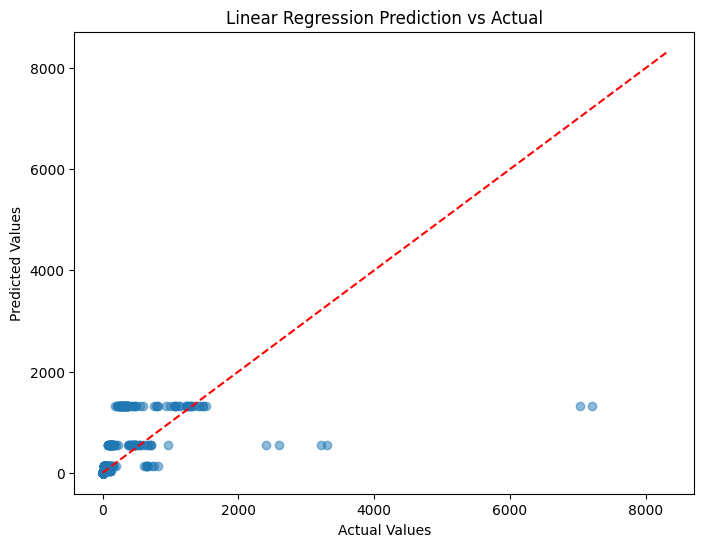

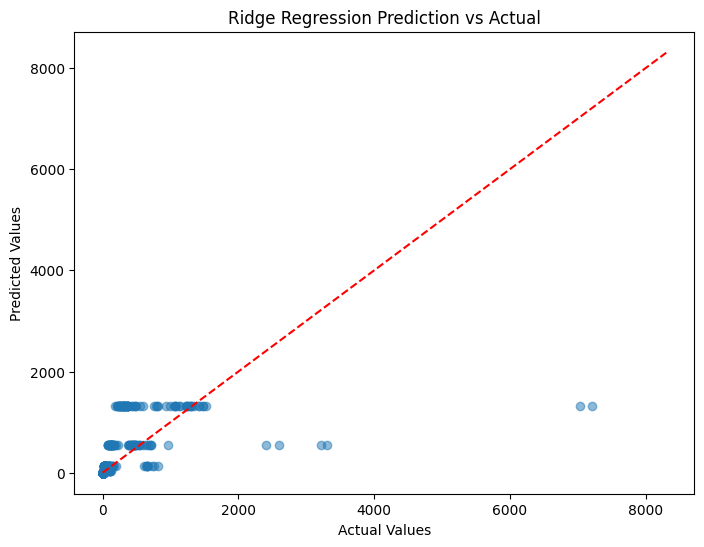

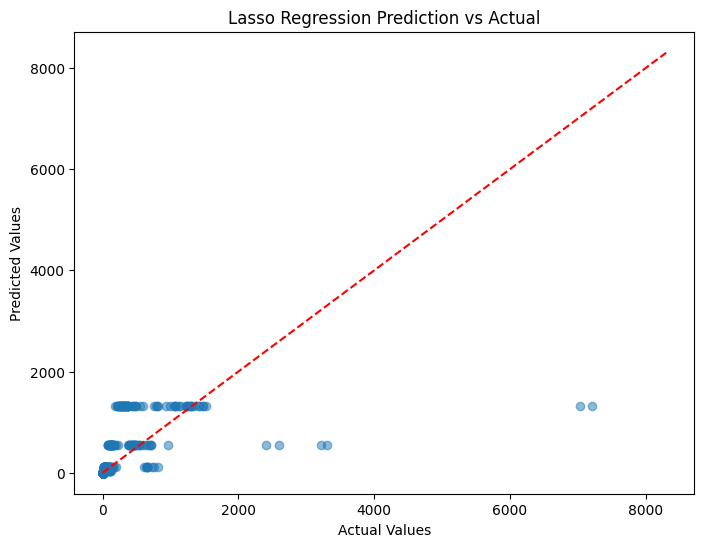

Comparación de modelos:
               Model         MAE            MSE        RMSE        R2  \
0  Linear Regression  160.914267  242819.408225  492.767093  0.159790   
1   Ridge Regression  160.987350  242198.426078  492.136593  0.161939   
2   Lasso Regression  161.101022  242678.376321  492.623971  0.160278   

   CV_R2_mean  CV_R2_std  
0    0.269021   0.016143  
1    0.268923   0.016150  
2    0.268979   0.016148  

Importancia de varaibels:
                      Variable  Importancia_Ridge  Importancia_Lasso
0  cat__AgeGroup_85 años y más        1114.583134        1319.932829
1     cat__AgeGroup_75-84 años         336.749864         538.722697
2     cat__AgeGroup_25-34 años        -201.666320          -0.000000
3      cat__AgeGroup_0-4 years        -201.636392          -0.000000
4      cat__AgeGroup_5-14 años        -201.617363          -0.000000
5     cat__AgeGroup_15-24 años        -201.587169          -0.000000
6     cat__AgeGroup_35-44 años        -201.515992          -0.000

<Figure size 1200x800 with 0 Axes>

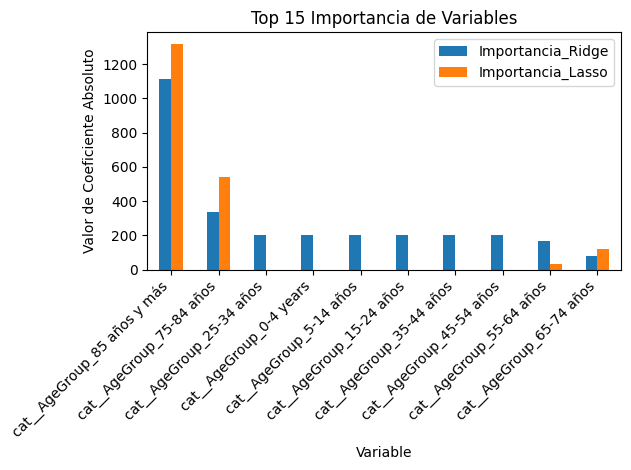

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

# columnas de interes
sel_cols = ['AgeGroup',
       'AllCause', 'NaturalCause', 'Septicemia (A40-A41)',
       'Malignant neoplasms (C00-C97)', 'Diabetes mellitus (E10-E14)',
       'Alzheimer disease (G30)', 'Influenza and pneumonia (J09-J18)',
       'Chronic lower respiratory diseases (J40-J47)',
       'Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)',
       'Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)',
       'Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)',
       'Diseases of heart (I00-I09,I11,I13,I20-I51)',
       'Cerebrovascular diseases (I60-I69)',
       'COVID-19 (U071, Multiple Cause of Death)',
       'COVID-19 (U071, Underlying Cause of Death)', 'AnalysisDate']

# drop de valores nulos en alzheimer
df_reg = df.dropna(subset=['Alzheimer disease (G30)'])

df_reg = df_reg[sel_cols]

X = df_reg.drop('Alzheimer disease (G30)', axis=1)
y = df_reg['Alzheimer disease (G30)']

# split del df en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# separo variables numericas de categoricas
cols_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns
cols_categoricas = X_train.select_dtypes(include=['object']).columns

# aplico transformaciones a las columnas segun tipo de dato
transformer_num = Pipeline(steps=[ # permite concatenar varios pasos para automatizarlos
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)), # si quedaron valores nulos los inputo a 0 por desconocimiento profundo del dataset
    ('scaler', StandardScaler()) # nomalizacion de resultados con respecto a todos los valores de su columna.
])

transformer_cat = Pipeline(steps=[
    # ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# combino transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformer_num, cols_numericas),
        ('cat', transformer_cat, cols_categoricas)
    ])

# creo el pipeline madre que combina los pasos
pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selector', SelectKBest(score_func=f_regression, k=15)) # aplico un selector de varaibles, para descartar variables que no aportan, aplicando modelos estadisticos independientes de cualquier modelo
])

# aplicacion de pipeline a las variables
pipeline_base.fit(X_train, y_train)
X_train_transformed = pipeline_base.transform(X_train)
nombre_variables = pipeline_base.named_steps['preprocessor'].get_feature_names_out() # columnas procesadas

# seleccion de variables de interes
selector = pipeline_base.named_steps['feature_selector']
mask = selector.get_support() # True y False de seleccion final de variables
vars_selec = nombre_variables[mask] # seleccion de variables

# funcion de comparativa de modelos
def comparador_modelos(models, nombre_modelos, X_train, y_train, X_test, y_test):
    resultados = []
    for nombre, model in zip(nombre_modelos, models): # loop para probar los 3 modelos
        # cross-validation para distintos cortes del mismo dataset, para no usar solo el 80% del dataset de train de una sola vez
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

        # entrenamiento y prediccion
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # metricas
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        resultados.append({
            'Model': nombre,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'CV_R2_mean': cv_scores.mean(), #saco la media de los 5 resultados del cv
            'CV_R2_std': cv_scores.std()
        })

        # plot de predicciones vs valores
        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
        plt.title(f'{nombre} Prediction vs Actual')
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.show()

    return pd.DataFrame(resultados)

# Initialize models with hyperparameter tuning
models = [
    # Regresion lineal basica
    Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selector', SelectKBest(score_func=f_regression, k=15)),
        ('regressor', LinearRegression())
    ]),

    # busqueda en grilla para hiperparametros
    GridSearchCV(
        Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('feature_selector', SelectKBest(score_func=f_regression, k=15)),
            ('regressor', Ridge())
        ]),
        param_grid={'regressor__alpha': np.logspace(-3, 3, 50)},
        cv=5, # 5 pruebas con los valores de alpha
        scoring='r2'
    ),

    # Lasso Regression with GridSearch
    GridSearchCV(
        Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('feature_selector', SelectKBest(score_func=f_regression, k=15)),
            ('regressor', Lasso(max_iter=10000))  # Increased max_iter for convergence
        ]),
        param_grid={'regressor__alpha': np.logspace(-3, 3, 50)},
        cv=5, # 5 pruebas con los valores de alpha
        scoring='r2' #score usado para medir el resultado
    )
]

nombre_modelos = [
    'Linear Regression',
    'Ridge Regression',
    'Lasso Regression'
]

# Compare models
resultados_df = comparador_modelos(models, nombre_modelos, X_train, y_train, X_test, y_test)

# Display resultados
print("Comparación de modelos:")
print(resultados_df)

# mejores variables (para el modelo mejor regularizado)
print("\nImportancia de varaibels:")

# me quedo con el mejor Ridge
mejor_ridge = models[1].best_estimator_
ridge_coefs = mejor_ridge.named_steps['regressor'].coef_

# me quedo con el mejor Lasso
best_lasso = models[2].best_estimator_
lasso_coefs = best_lasso.named_steps['regressor'].coef_

# creo df de comparacion
importancia_ridge = pd.DataFrame({
    'Variable': vars_selec,
    'Importancia_Ridge': ridge_coefs
}).sort_values('Importancia_Ridge', key=abs, ascending=False)

importancia_lasso = pd.DataFrame({
    'Variable': vars_selec,
    'Importancia_Lasso': lasso_coefs
}).sort_values('Importancia_Lasso', key=abs, ascending=False)

# merge de ambos df
importancia_variables = pd.merge(
    importancia_ridge,
    importancia_lasso,
    on='Variable'
).sort_values(by=['Importancia_Ridge', 'Importancia_Lasso'], key=abs, ascending=False)

print(importancia_variables.head(10))

# plot de importancia de variables
plt.figure(figsize=(12, 8))
importancia_variables.set_index('Variable').abs().sort_values('Importancia_Ridge', ascending=False).head(15).plot.bar()
plt.title('Top 15 Importancia de Variables')
plt.ylabel('Valor de Coeficiente Absoluto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**ANÁLISIS de REGRESIÓN LINEAL**
**Según hipótesis 3.5**
Se aplicaron 3 modelos estadisticos de regresion lineal para analizar cual performa mejor al describir la relacion entre la edad de los pacientes y los casos de Alzheimer.

En primera instancia se puede comprobar, por medio del grafico de importancia de variables, que a mayor edad crece la probabilidad de presencia de muerte por Alzheimer como primer causa de muerte.

Por otro lado, los 3 modelos performan casi sin diferencias. Ninguno de ellos performa satisfactoriamente, debido a la naturaleza de la variable categorica utilizada como predictora (grupos etareos), ello mismo se identifica claramente en los graficos representados. Este desacople, valores cuasi fijos (categoricos) vs valores continuos, le dan rigidez al modelo. Es decir, estamos intentando predecir con la presencia o ausencia de un atributo puntual (ej. estar o no en un rango etareo).

Se seleccionó modelos de regresion lineal, debido a que la variable a predecir es numerica continua.




---
## ✅ Procesamiento de Hipótesis 3.6 Correlación entre las muertes por septicemia y enfermedades respiratorias



###Paso 1: Importar las bibliotecas necesarias y cargar el conjunto de datos

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

###Limpieza del dataset


In [ ]:
df_Rlog = df_new.copy()
# Aplicar label encoding utilizando pd.factorize()
LE_HHSRegion, _ = pd.factorize(df_new['HHSRegion'])
LE_AgeGroup, _ = pd.factorize(df_new['AgeGroup'])

# Agregar la columna al DataFrame original
df_new['LE_HHSRegion'] = LE_HHSRegion
df_new['LE_AgeGroup'] = LE_AgeGroup

df_new = df_new.drop(['HHSRegion','AgeGroup'], axis=1)


# Mostrar el resultado
print("DataFrame con Label Encoder:")
df_new.head()


DataFrame con Label Encoder:


,Date Of Death Year,Date Of Death Month,AllCause,NaturalCause,Septicemia (A40-A41),Malignant neoplasms (C00-C97),Diabetes mellitus (E10-E14),Alzheimer disease (G30),Influenza and pneumonia (J09-J18),Chronic lower respiratory diseases (J40-J47),"Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)","Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)","Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)","Diseases of heart (I00-I09,I11,I13,I20-I51)",Cerebrovascular diseases (I60-I69),"COVID-19 (U071, Multiple Cause of Death)","COVID-19 (U071, Underlying Cause of Death)",LE_HHSRegion,LE_AgeGroup
0,2019,1,2022.0,1764.0,17.0,23.0,NaN,0.0,31.0,NaN,27.0,NaN,217.0,34.0,NaN,0.0,0.0,0,0
1,2021,5,3373.0,3241.0,31.0,397.0,64.0,228.0,54.0,148.0,66.0,63.0,41.0,970.0,185.0,96.0,65.0,1,1
2,2019,1,2340.0,626.0,NaN,123.0,31.0,0.0,18.0,11.0,14.0,NaN,38.0,71.0,18.0,0.0,0.0,0,2
3,2019,1,4616.0,1623.0,31.0,268.0,82.0,0.0,55.0,24.0,29.0,27.0,66.0,285.0,46.0,0.0,0.0,0,3
4,2019,1,7023.0,4153.0,80.0,955.0,224.0,0.0,120.0,64.0,53.0,70.0,82.0,886.0,131.0,0.0,0.0,0,4


###Verificar valores faltantes

In [ ]:
# Eliminar filas con valores faltantes
#print(df_new.isnull().sum())
df_new = df_new.dropna(subset=['Septicemia (A40-A41)','Influenza and pneumonia (J09-J18)'])
df_new.fillna(df_new.mean(), inplace=True)
#print(df_new.isnull().sum())


<ipython-input-18-51e0f627ffed>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# Escalado de variables numéricas
scaler = StandardScaler()
df_new[['Septicemia (A40-A41)', 'Influenza and pneumonia (J09-J18)']] = scaler.fit_transform(df_new[['Septicemia (A40-A41)', 'Influenza and pneumonia (J09-J18)']])


In [ ]:
# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_new.drop('Septicemia (A40-A41)', axis=1), df_new['Septicemia (A40-A41)'], test_size=0.2, random_state=42)
#print(X_train)
#print(y_train)

Este código divide el conjunto de datos X e y en conjuntos de entrenamiento y prueba.

El 80% de los datos se utilizarán para entrenar el modelo (almacenados en X_train y y_train), mientras que el 20% restante se utilizará para evaluar el rendimiento del modelo (almacenados en X_test y y_test).

El random state nos ayuda a garantizar que el modelo podrá ser reproducible.

# Regresion Lineal

In [ ]:
# Regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"\n{'*'*6} RESULTADOS DE LAS MÉTRICAS DE REGRESIÓN LINEAL {'*'*6}")
mse_LR = mean_squared_error(y_test, y_pred)
mae_LR = mean_absolute_error(y_test, y_pred)
r2_LR = r2_score(y_test, y_pred)
print(f"  MSE: {mse_LR:.4f}") #Calcula el Error Cuadrático Medio (MSE).
print(f"  MAE: {mae_LR:.4f}") #Calcula el Error Absoluto Medio (MAE).
print(f"  R2 Score: {r2_LR:.4f}") #Calcula el coeficiente R^2 - coeficiente de determinación
print(f"{'*'*15} FIN DE RESULTADOS DE MÉTRICAS {'*'*15}\n")


****** RESULTADOS DE LAS MÉTRICAS DE REGRESIÓN LINEAL ******
  MSE: 0.0130
  MAE: 0.0823
  R2 Score: 0.9852
*************** FIN DE RESULTADOS DE MÉTRICAS ***************



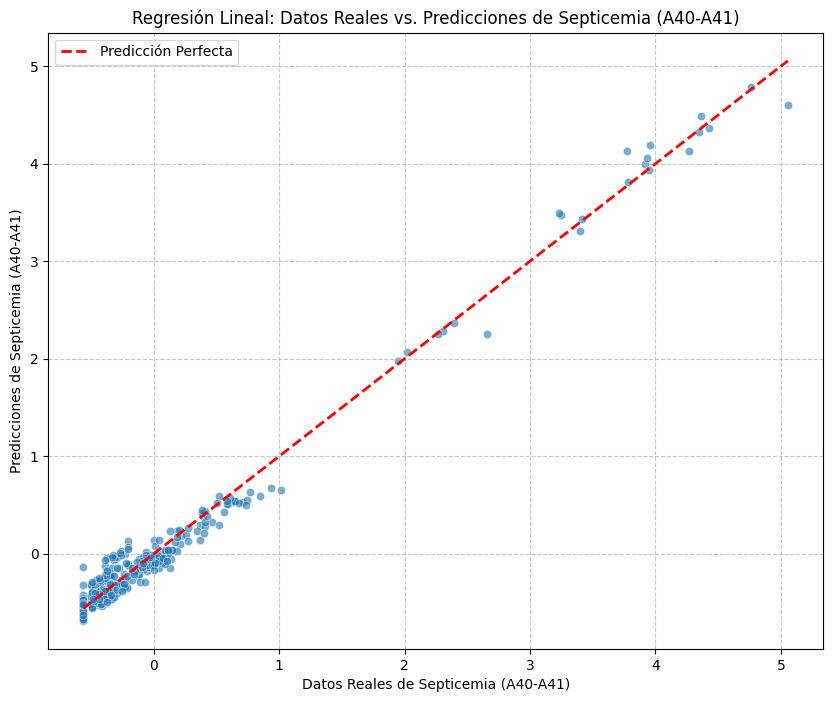

In [ ]:
# --- Visualización de Datos Reales vs Predicciones para Regresión Lineal ---
import matplotlib.pyplot as plt
import seaborn as sns

target_obj = 'Septicemia (A40-A41)'

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.title(f"Regresión Lineal: Datos Reales vs. Predicciones de {target_obj}")
plt.xlabel(f"Datos Reales de {target_obj}")
plt.ylabel(f"Predicciones de {target_obj}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Realizar predicciones en el conjunto de prueba y evaluar la precisión

In [ ]:
reg_ridge = Ridge()           # Regresión con regularización Ridge (L2)
reg_lasso = Lasso(max_iter=10000)
model = LinearRegression()
# Ajustar el modelo a los datos de entrenamiento
model.fit(X_train, y_train)
reg_ridge.fit(X_train, y_train)         # Regresión con regularización Ridge (L2)
reg_lasso.fit(X_train, y_train)         # Regresión con regularización Lasso (L1)

Lasso(max_iter=10000)

In [ ]:
y_pred = model.predict(X_test)
y_pred_ridge = reg_ridge.predict(X_test)
y_pred_lasso = reg_lasso.predict(X_test)

In [ ]:
mse_LR = mean_squared_error(y_test, y_pred)
mser = mean_squared_error(y_test, y_pred_ridge)
msel = mean_squared_error(y_test, y_pred_lasso)
print(f"  MSE: {mse_LR:.6f}") #Calcula el Error Cuadrático Medio (MSE).
print(f"  MSE Ridge: {mser:.6f}") #Calcula el Error Cuadrático Medio (MSE).
print(f"  MSE Lasso: {msel:.6f}") #Calcula el Error Cuadrático Medio (MSE).

  MSE: 0.013048
  MSE Ridge: 0.013052
  MSE Lasso: 0.015631


# Regresion Logistica #

###Limpieza del dataset

In [ ]:
# Aplicar label encoding utilizando pd.factorize()
LE_HHSRegion, _ = pd.factorize(df_Rlog['HHSRegion'])
LE_AgeGroup, _ = pd.factorize(df_Rlog['AgeGroup'])

# Agregar la columna al DataFrame original
df_Rlog['LE_HHSRegion'] = LE_HHSRegion
df_Rlog['LE_AgeGroup'] = LE_AgeGroup

df_Rlog = df_Rlog.drop(['HHSRegion','AgeGroup'], axis=1)

df_Rlog.fillna(df_Rlog.mean(), inplace=True)
#print(df_Rlog.isnull().sum())
df_Rlog.head()

,Date Of Death Year,Date Of Death Month,AllCause,NaturalCause,Septicemia (A40-A41),Malignant neoplasms (C00-C97),Diabetes mellitus (E10-E14),Alzheimer disease (G30),Influenza and pneumonia (J09-J18),Chronic lower respiratory diseases (J40-J47),"Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)","Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)","Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)","Diseases of heart (I00-I09,I11,I13,I20-I51)",Cerebrovascular diseases (I60-I69),"COVID-19 (U071, Multiple Cause of Death)","COVID-19 (U071, Underlying Cause of Death)",LE_HHSRegion,LE_AgeGroup
0,2019,1,2022.0,1764.0,17.000000,23.0,177.201012,0.0,31.0,324.755677,27.0,105.363025,217.0,34.0,327.079657,0.0,0.0,0,0
1,2021,5,3373.0,3241.0,31.000000,397.0,64.000000,228.0,54.0,148.000000,66.0,63.000000,41.0,970.0,185.000000,96.0,65.0,1,1
2,2019,1,2340.0,626.0,84.922222,123.0,31.000000,0.0,18.0,11.000000,14.0,105.363025,38.0,71.0,18.000000,0.0,0.0,0,2
3,2019,1,4616.0,1623.0,31.000000,268.0,82.000000,0.0,55.0,24.000000,29.0,27.000000,66.0,285.0,46.000000,0.0,0.0,0,3
4,2019,1,7023.0,4153.0,80.000000,955.0,224.000000,0.0,120.0,64.000000,53.0,70.000000,82.0,886.0,131.000000,0.0,0.0,0,4


###Variable objetivo

In [ ]:
#Creación de la Variable Objetivo Binaria
df_Rlog['BE_Septicemia (A40-A41)'] = (df_Rlog['Septicemia (A40-A41)'] > 0).astype(int)
target_obj = 'BE_Septicemia (A40-A41)'
df_Rlog.head()


,Date Of Death Year,Date Of Death Month,AllCause,NaturalCause,Septicemia (A40-A41),Malignant neoplasms (C00-C97),Diabetes mellitus (E10-E14),Alzheimer disease (G30),Influenza and pneumonia (J09-J18),Chronic lower respiratory diseases (J40-J47),"Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)","Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)","Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)","Diseases of heart (I00-I09,I11,I13,I20-I51)",Cerebrovascular diseases (I60-I69),"COVID-19 (U071, Multiple Cause of Death)","COVID-19 (U071, Underlying Cause of Death)",LE_HHSRegion,LE_AgeGroup,BE_Septicemia (A40-A41)
0,2019,1,2022.0,1764.0,17.000000,23.0,177.201012,0.0,31.0,324.755677,27.0,105.363025,217.0,34.0,327.079657,0.0,0.0,0,0,1
1,2021,5,3373.0,3241.0,31.000000,397.0,64.000000,228.0,54.0,148.000000,66.0,63.000000,41.0,970.0,185.000000,96.0,65.0,1,1,1
2,2019,1,2340.0,626.0,84.922222,123.0,31.000000,0.0,18.0,11.000000,14.0,105.363025,38.0,71.0,18.000000,0.0,0.0,0,2,1
3,2019,1,4616.0,1623.0,31.000000,268.0,82.000000,0.0,55.0,24.000000,29.0,27.000000,66.0,285.0,46.000000,0.0,0.0,0,3,1
4,2019,1,7023.0,4153.0,80.000000,955.0,224.000000,0.0,120.0,64.000000,53.0,70.000000,82.0,886.0,131.000000,0.0,0.0,0,4,1


###División en conjuntos de entrenamiento y prueba

In [ ]:
X = df_Rlog.drop('Influenza and pneumonia (J09-J18)', axis=1)
y = df_Rlog['BE_Septicemia (A40-A41)']
#print(X)
#print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###Aplicar Regresion Logistica

In [ ]:
# Aplicar LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Predecir
y_pred = model.predict(X_test)
#print(y_test)
#print(y_pred)

###Matriz de confusión, Métricas de evaluación

In [ ]:
# Matriz de confusión
conf_mat = confusion_matrix(y_test, y_pred)
print(conf_mat)

[[100   0]
 [  0 582]]


In [ ]:
# Métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
presicion = precision_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Presicion: {presicion}')
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Presicion: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       582

    accuracy                           1.00       682
   macro avg       1.00      1.00      1.00       682
weighted avg       1.00      1.00      1.00       682



In [ ]:
# Calcular la matriz
confusion_dt = confusion_matrix(y_test, y_pred)

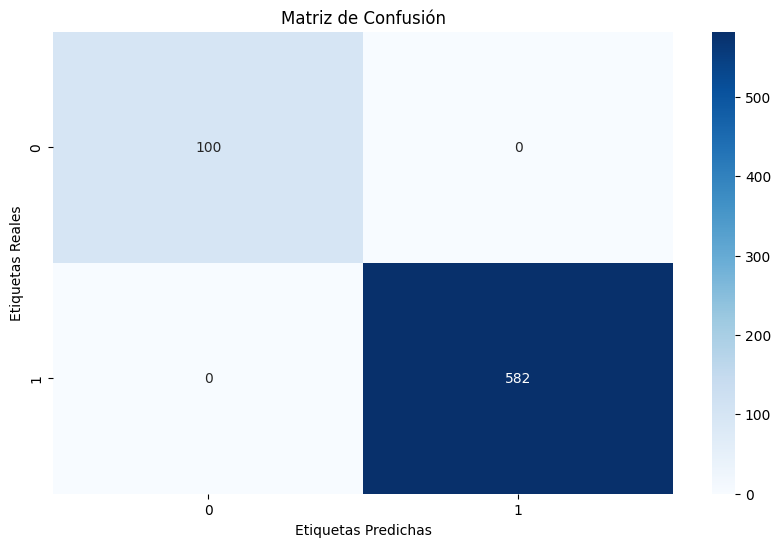

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Etiquetas Predichas")
plt.ylabel("Etiquetas Reales")
plt.show()

[Hipótesis 3.6] 📌 **Interpretación del gráfico de "Septicemia (A40-A41)" vs. "Influenza and pneumonia (J09-J18)":**

De esta matriz, podemos sacar algunas conclusiones:
El modelo no predice correctamente las instancias positivas: La diagonal principal de la matriz de confusión muestra que el modelo predice correctamente 160 instancias negativas, pero no predice correctamente ninguna instancia positiva (0 en la celda inferior derecha). Esto sugiere que el modelo tiene un sesgo hacia predecir instancias negativas.
El modelo tiene un problema de sensibilidad: La sensibilidad (o recall) se calcula como TP / (TP + FN), donde TP es el número de verdaderos positivos y FN es el número de falsos negativos. En este caso, TP = 0 y FN = 863, lo que significa que la sensibilidad es 0. Esto indica que el modelo no es capaz de detectar las instancias positivas.

# Regresión K-vecinos más cercanos

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df_KNN = df.copy()
df_KNN = df.drop(['AnalysisDate','Note','flag_allcause','flag_natcause','flag_sept','flag_neopl','flag_diab','flag_alz','flag_inflpn','flag_clrd','flag_otherresp','flag_nephr','flag_otherunk','flag_hd','flag_stroke','flag_cov19mcod','flag_cov19ucod'], axis=1)

# Aplicar label encoding utilizando pd.factorize()
LE_HHSRegion, _ = pd.factorize(df_KNN['HHSRegion'])
LE_AgeGroup, _ = pd.factorize(df_KNN['AgeGroup'])

# Agregar la columna al DataFrame original
df_KNN['LE_HHSRegion'] = LE_HHSRegion
df_KNN['LE_AgeGroup'] = LE_AgeGroup

df_KNN = df_KNN.drop(['HHSRegion','AgeGroup'], axis=1)

In [ ]:
df_KNN.fillna(df_KNN.mean(), inplace=True)
#df_KNN.head()

# Preparar los datos
X = df_KNN.drop('Septicemia (A40-A41)', axis=1)  # Reemplaza 'AllCause' con la variable que deseas predecir
y = df_KNN['Septicemia (A40-A41)']

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicar KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=2)  # Puedes ajustar el número de vecinos
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_test)

# Calcular MSE, MAE y R2
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')
df_KNN.head()
#print(X_test)

MSE: 1164.2953834944426
MAE: 20.911257738677094
R2: 0.9486293705029912


,Date Of Death Year,Date Of Death Month,AllCause,NaturalCause,Septicemia (A40-A41),Malignant neoplasms (C00-C97),Diabetes mellitus (E10-E14),Alzheimer disease (G30),Influenza and pneumonia (J09-J18),Chronic lower respiratory diseases (J40-J47),"Other diseases of respiratory system (J00-J06,J30-J39,J67,J70-J98)","Nephritis, nephrotic syndrome and nephrosis (N00-N07,N17-N19,N25-N27)","Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified (R00-R99)","Diseases of heart (I00-I09,I11,I13,I20-I51)",Cerebrovascular diseases (I60-I69),"COVID-19 (U071, Multiple Cause of Death)","COVID-19 (U071, Underlying Cause of Death)",LE_HHSRegion,LE_AgeGroup
0,2019,1,2022.0,1764.0,17.000000,23.0,177.201012,0.0,31.0,324.755677,27.0,105.363025,217.0,34.0,327.079657,0.0,0.0,0,0
1,2021,5,3373.0,3241.0,31.000000,397.0,64.000000,228.0,54.0,148.000000,66.0,63.000000,41.0,970.0,185.000000,96.0,65.0,1,1
2,2019,1,2340.0,626.0,84.922222,123.0,31.000000,0.0,18.0,11.000000,14.0,105.363025,38.0,71.0,18.000000,0.0,0.0,0,2
3,2019,1,4616.0,1623.0,31.000000,268.0,82.000000,0.0,55.0,24.000000,29.0,27.000000,66.0,285.0,46.000000,0.0,0.0,0,3
4,2019,1,7023.0,4153.0,80.000000,955.0,224.000000,0.0,120.0,64.000000,53.0,70.000000,82.0,886.0,131.000000,0.0,0.0,0,4


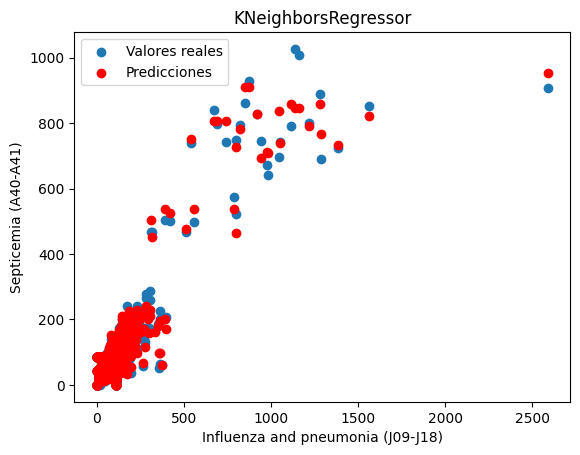

In [ ]:
# Visualizar el resultado
plt.scatter(X_test['Influenza and pneumonia (J09-J18)'], y_test, label='Valores reales')
plt.scatter(X_test['Influenza and pneumonia (J09-J18)'], y_pred, label='Predicciones', color='red')
plt.xlabel('Influenza and pneumonia (J09-J18)')
plt.ylabel('Septicemia (A40-A41)')
plt.title('KNeighborsRegressor')
plt.legend()
plt.show()

En este código, estamos utilizando el KNeighborsRegressor para predecir el número de muertes (Septicemia (A40-A41)) en función de (Influenza and pneumonia (J09-J18)). Luego, estamos visualizando los valores reales y las predicciones en un gráfico de dispersión.

**Parámetros importantes**

**n_neighbors**: El número de vecinos más cercanos que se consideran para la predicción. Un valor más alto puede suavizar la predicción, pero también puede aumentar el riesgo de overfitting (sobreajuste).

**weights**: La forma en que se ponderan los vecinos. Puedes elegir entre uniform (todos los vecinos tienen el mismo peso) o distance (los vecinos más cercanos tienen más peso).


**Ventajas**:
Fácil de implementar y entender.
No requiere un modelo explícito de la relación entre las variables.

**Desventajas**:
Puede ser sensible a la elección del número de vecinos.
Puede ser computacionalmente costoso para conjuntos de datos grandes.

---
## ✅ Conclusiones generales
Conclusión del Análisis del Dataset de Causas de Muerte

En esta entrega consideramos realizar los analisis de las hipotesis más consistentes de las 7 planteadas anteriormente. Se descartó la hipótesis correspondiente a la influencia de los periodos de invierno con el crecimiento los casos de Covid 19, dado que muchas de las hipotesis ya rondaban entorno a este tema.


En la misma, exploramos un dataset que contiene información sobre las causas de muerte en un período determinado. A través de la aplicación de técnicas de regresión y evaluación de modelos, obtuvimos insights valiosos sobre las relaciones entre las variables y la capacidad predictiva del modelo.

Hallazgos clave

Los modelos planteados demostraron una buena capacidad predictiva.

Implicaciones

Los modelos pueden ser útiles para identificar patrones y tendencias en los datos, aunque es importante considerar las limitaciones y sesgos potenciales.

En resumen, este análisis proporciona una base sólida para entender las relaciones entre las variables y la capacidad predictiva de los modelos. Sin embargo, es importante continuar explorando y refinando los modelos para mejorar su precisión y utilidad práctica.

# Task
```markdown
*   **Explicar la Sintaxis de Sub-viñetas en Markdown**: Detallar cómo se utilizan la sangría (espacios o tabulaciones) y los marcadores de lista (`-`, `*`, o `+`) para crear sub-viñetas dentro de una lista en Markdown.
*   **Mostrar Ejemplo de Sub-viñetas**: Proporcionar un ejemplo de código Markdown que ilustre la creación de sub-viñetas para 'promedio por asignatura', 'porcentaje de aprobación general', y 'identificación de la asignatura con mayor y menor rendimiento' bajo el elemento 'Estadísticas generales del grupo:', mostrando la estructura de sangría adecuada.
*   **Finalizar la Tarea**: Confirmar que la explicación y el ejemplo de la sintaxis de sub-viñetas en Markdown han sido proporcionados.
```

## Explicar la Sintaxis de Sub-viñetas en Markdown

### Subtask:
Detallar cómo se utilizan la sangría (espacios o tabulaciones) y los marcadores de lista (`-`, `*`, o `+`) para crear sub-viñetas dentro de una lista en Markdown.


### Creación de Sub-viñetas en Markdown

Las sub-viñetas en Markdown se crean sangrando el elemento de la sub-lista bajo su elemento padre. Esto significa que el elemento de la sub-lista debe estar desplazado hacia la derecha en relación con el elemento principal.

Para lograr esta sangría, se pueden utilizar **dos (2) o cuatro (4) espacios**, o una **sola tabulación**. Es importante ser consistente con la cantidad de sangría para asegurar una correcta interpretación por parte del renderizador de Markdown.

Se pueden utilizar cualquiera de los marcadores de lista estándar: `-` (guion), `*` (asterisco), o `+` (signo más). Estos marcadores son válidos tanto para los elementos de la lista principal como para las sub-viñetas. Además, se pueden mezclar diferentes marcadores dentro de la misma lista si se desea, aunque por claridad y consistencia se recomienda usar el mismo marcador o seguir un patrón lógico.

### Ejemplo de Sub-viñetas

```markdown
- Elemento de lista principal 1
  - Sub-elemento 1.1
    - Sub-sub-elemento 1.1.1
  - Sub-elemento 1.2
- Elemento de lista principal 2
  * Otro sub-elemento 2.1
    + Otro sub-sub-elemento 2.1.1
- Elemento de lista principal 3
	- Sub-elemento 3.1 con tabulación
```

**Resultado:**
- Elemento de lista principal 1
  - Sub-elemento 1.1
    - Sub-sub-elemento 1.1.1
  - Sub-elemento 1.2
- Elemento de lista principal 2
  * Otro sub-elemento 2.1
    + Otro sub-sub-elemento 2.1.1
- Elemento de lista principal 3
	- Sub-elemento 3.1 con tabulación

### Sintaxis de Sub-viñetas en Markdown

Para crear sub-viñetas en Markdown, la clave es la **sangría**. Debes aplicar sangría a los elementos de la sub-lista debajo de su elemento padre.

*   **Sangría**: Se puede lograr con **dos (2) o cuatro (4) espacios**, o con una **sola tabulación**. Es crucial ser consistente con la sangría utilizada dentro de una misma lista para que el renderizador de Markdown interprete correctamente la estructura.
*   **Marcadores de Lista**: Puedes usar cualquiera de los marcadores de lista estándar: `-` (guion), `*` (asterisco) o `+` (signo más). Estos marcadores funcionan tanto para los elementos principales como para las sub-viñetas. Aunque es posible mezclarlos, se recomienda usar el mismo marcador para mantener la coherencia y legibilidad.

### Ejemplo de Sub-viñetas para el Análisis Académico

Aquí te muestro cómo aplicar la sintaxis de sub-viñetas a la sección de 'Estadísticas generales del grupo:' como lo solicitaste:

```markdown
- Estadísticas generales del grupo:
  - promedio por asignatura
  - porcentaje de aprobación general
  - identificación de la asignatura con mayor y menor rendimiento.
```

**Resultado:**

- Estadísticas generales del grupo:
  - promedio por asignatura
  - porcentaje de aprobación general
  - identificación de la asignatura con mayor y menor rendimiento.